In [1]:
library(keras)
library(tensorflow)
library(tidyverse)
library(recipes)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.2     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.0
✔ ggplot2   3.4.2     ✔ tibble    3.2.1
✔ lubridate 1.9.2     ✔ tidyr     1.3.0
✔ purrr     1.0.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attachement du package : 'recipes'


L'objet suivant est masqué depuis 'package:stringr':

    fixed


L'objet suivant est masqué depuis 'package:stats':

    step




In [2]:
ConfusionMatrix <- function(y_pred, y_true) {
  Confusion_Mat <- table(y_true, y_pred)
  return(Confusion_Mat)
}
 
ConfusionDF <- function(y_pred, y_true) {
  Confusion_DF <- transform(as.data.frame(ConfusionMatrix(y_pred, y_true)),
                            y_true = as.character(y_true),
                            y_pred = as.character(y_pred),
                            Freq = as.integer(Freq))
  return(Confusion_DF)
}
 
Precision_micro <- function(y_true, y_pred, labels = NULL) {
  Confusion_DF <- ConfusionDF(y_pred, y_true)
 
  if (is.null(labels) == TRUE) labels <- unique(c(y_true, y_pred))
  # this is not bulletproof since there might be labels missing (in strange cases)
  # in strange cases where they existed in training set but are missing from test ground truth and predictions.
 
  TP <- c()
  FP <- c()
  for (i in c(1:length(labels))) {
    positive <- labels[i]
   
    # it may happen that a label is never predicted (missing from y_pred) but exists in y_true
    # in this case ConfusionDF will not have these lines and thus the simplified code crashes
    # TP[i] <- as.integer(Confusion_DF[which(Confusion_DF$y_true==positive & Confusion_DF$y_pred==positive), "Freq"])
    # FP[i] <- as.integer(sum(Confusion_DF[which(Confusion_DF$y_true!=positive & Confusion_DF$y_pred==positive), "Freq"]))
   
    # workaround:
    # i don't want to change ConfusionDF since i don't know if the current behaviour is a feature or a bug.
    tmp <- Confusion_DF[which(Confusion_DF$y_true==positive & Confusion_DF$y_pred==positive), "Freq"]
    TP[i] <- if (length(tmp)==0) 0 else as.integer(tmp)
   
    tmp <- Confusion_DF[which(Confusion_DF$y_true!=positive & Confusion_DF$y_pred==positive), "Freq"]
    FP[i] <- if (length(tmp)==0) 0 else as.integer(sum(tmp))
  }
  Precision_micro <- sum(TP) / (sum(TP) + sum(FP))
  return(Precision_micro)
}
 
Recall_micro <- function(y_true, y_pred, labels = NULL) {
  Confusion_DF <- ConfusionDF(y_pred, y_true)
 
  if (is.null(labels) == TRUE) labels <- unique(c(y_true, y_pred))
  # this is not bulletproof since there might be labels missing (in strange cases)
  # in strange cases where they existed in training set but are missing from test ground truth and predictions.
 
  TP <- c()
  FN <- c()
  for (i in c(1:length(labels))) {
    positive <- labels[i]
   
    # short version, comment out due to bug or feature of Confusion_DF
    # TP[i] <- as.integer(Confusion_DF[which(Confusion_DF$y_true==positive & Confusion_DF$y_pred==positive), "Freq"])
    # FP[i] <- as.integer(sum(Confusion_DF[which(Confusion_DF$y_true==positive & Confusion_DF$y_pred!=positive), "Freq"]))
   
    # workaround:
    tmp <- Confusion_DF[which(Confusion_DF$y_true==positive & Confusion_DF$y_pred==positive), "Freq"]
    TP[i] <- if (length(tmp)==0) 0 else as.integer(tmp)
 
    tmp <- Confusion_DF[which(Confusion_DF$y_true==positive & Confusion_DF$y_pred!=positive), "Freq"]
    FN[i] <- if (length(tmp)==0) 0 else as.integer(sum(tmp))
  }
  Recall_micro <- sum(TP) / (sum(TP) + sum(FN))
  return(Recall_micro)
}
 
F1_Score_micro <- function(y_true, y_pred, labels = NULL) {
  if (is.null(labels) == TRUE) labels <- unique(c(y_true, y_pred)) # possible problems if labels are missing from y_*
  Precision <- Precision_micro(y_true, y_pred, labels)
  Recall <- Recall_micro(y_true, y_pred, labels)
  F1_Score_micro <- 2 * (Precision * Recall) / (Precision + Recall)
  return(F1_Score_micro)
}

In [3]:
dataNN<-read.csv("data_target_encoding_NN.csv",stringsAsFactors = T)
id_variable <- match('building_id', colnames(dataNN))
target_variables<-which(grepl('damage_grade',colnames(dataNN)))

I try without removing nzv values. We will try it later to see if it improves predict.

In [4]:
normalizer<-layer_normalization(axis = -1L)  %>%  
adapt(as.matrix(dataNN[,-target_variables]))

We use categorical_crossentropy as loss function since this corresponds to our multioutput classification program

In [5]:
neuralmodel <- keras_model_sequential() %>% 
normalizer  %>% 
layer_dense(37, activation = 'relu') %>%
layer_dense(3,activation='softmax')

neuralmodel %>% compile(
    loss = 'categorical_crossentropy',
    optimizer = optimizer_adam(0.001),
    metrics=c('AUC')
  )
neuralmodel

Model: "sequential"
________________________________________________________________________________
 Layer (type)                  Output Shape               Param #    Trainable  
 normalization (Normalization)  (None, 70)                141        Y          
 dense_1 (Dense)               (None, 37)                 2627       Y          
 dense (Dense)                 (None, 3)                  114        Y          
Total params: 2,882
Trainable params: 2,741
Non-trainable params: 141
________________________________________________________________________________

In [6]:
classConverter <- function(predict_data,test_data) {
    yhat<-data.frame(matrix(0,ncol = 1, nrow = nrow(predict_data)))
    y<-data.frame(matrix(0,ncol = 1, nrow = nrow(predict_data)))
    for (i in 1:nrow(predict_data)){
        yhat[i,]<-which.max(predict_data[i,])
        y[i,]<-which.max(test_data[i,target_variables])  
    }
    mylist <- list(yhat,y)
}

  |==============                                                        |  20%[1] "F1-Score Micro - 1 fold - 100 epochs: 0.75782651466929"
  |============================                                          |  40%[1] "F1-Score Micro - 2 fold - 100 epochs: 0.754180892309473"
  |==========================================                            |  60%

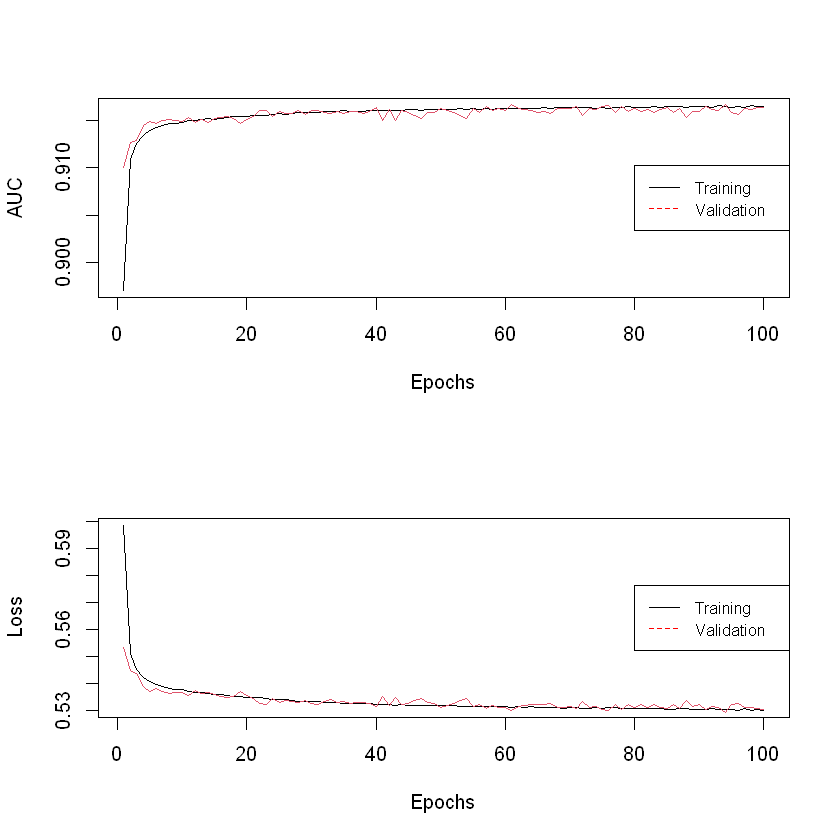

[1] "F1-Score Micro - 3 fold - 100 epochs: 0.753119996913759"
  |========================================================              |  80%

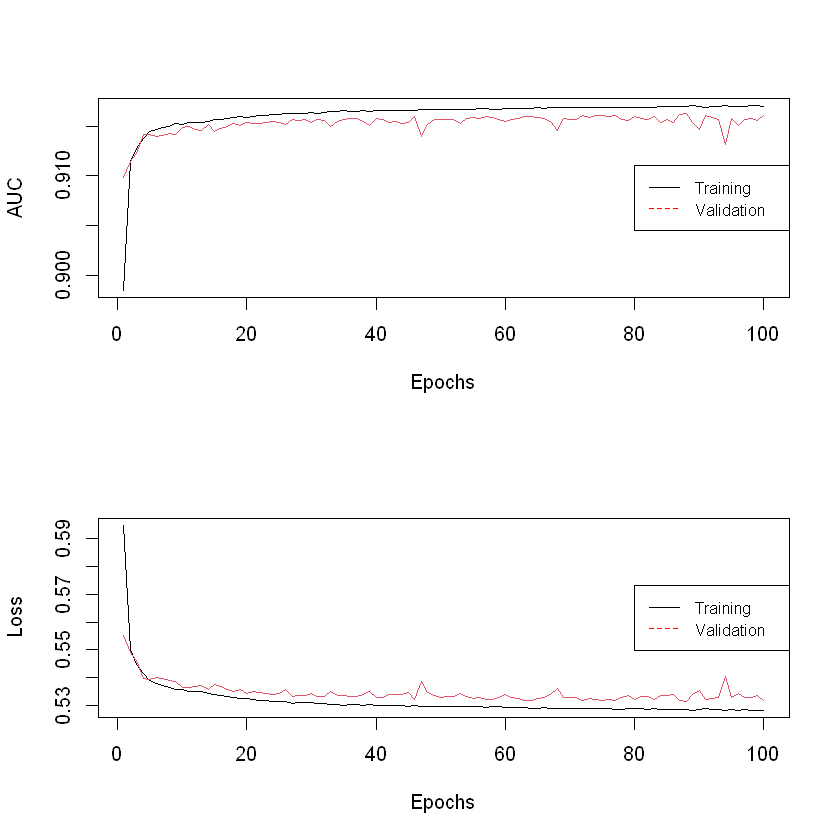

[1] "F1-Score Micro - 4 fold - 100 epochs: 0.756553440194433"
  |======================================================================| 100%

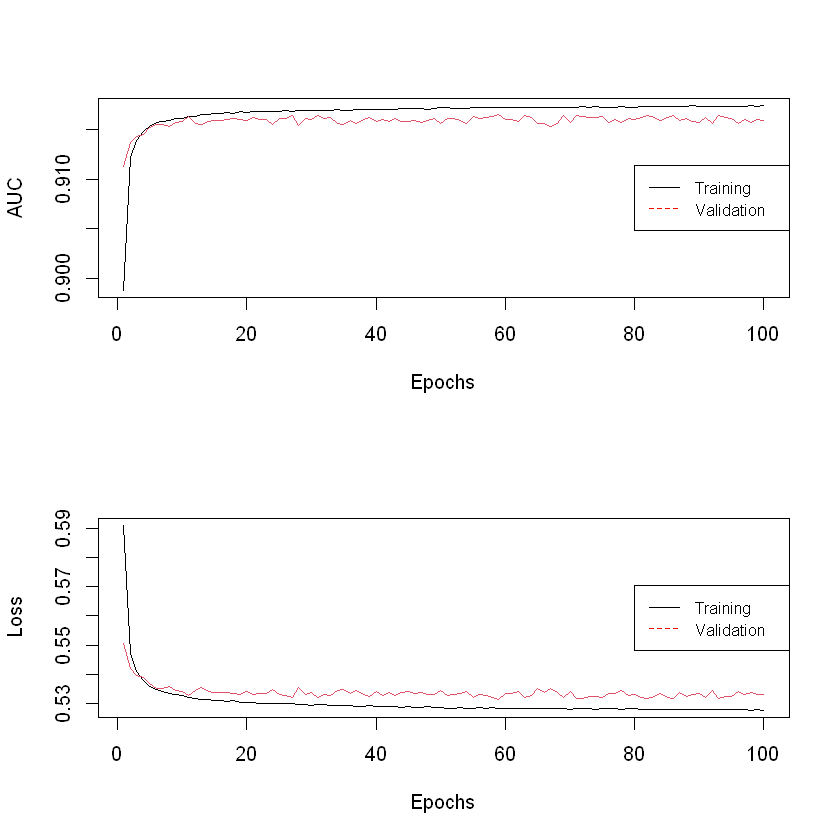

[1] "F1-Score Micro - 5 fold - 100 epochs: 0.755589421092228"


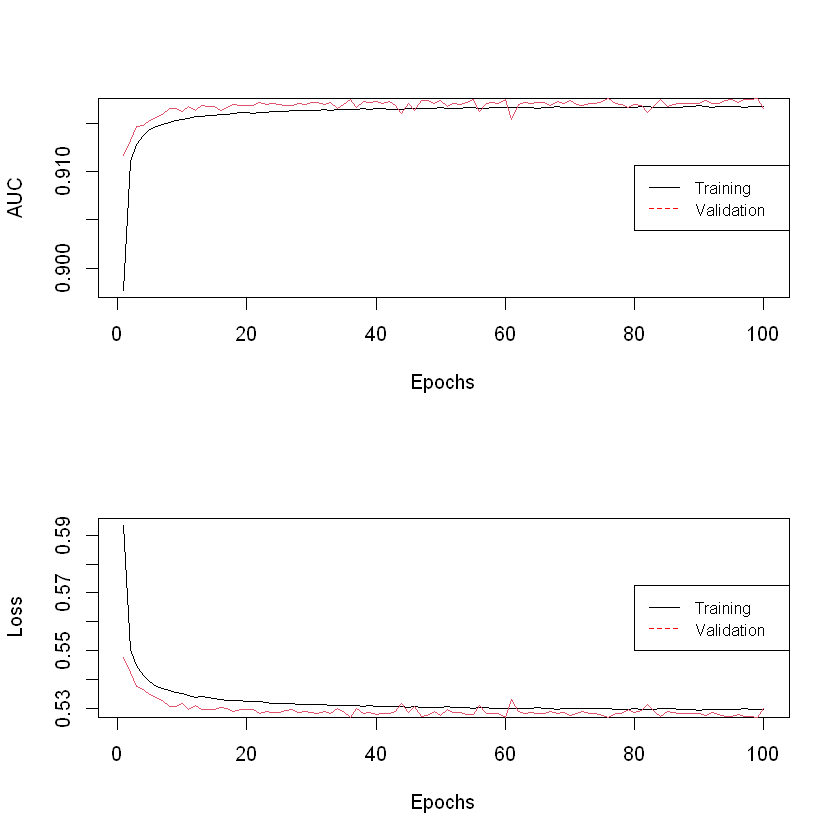

[1] "Mean F1-Score Micro: 0.755454053035837"


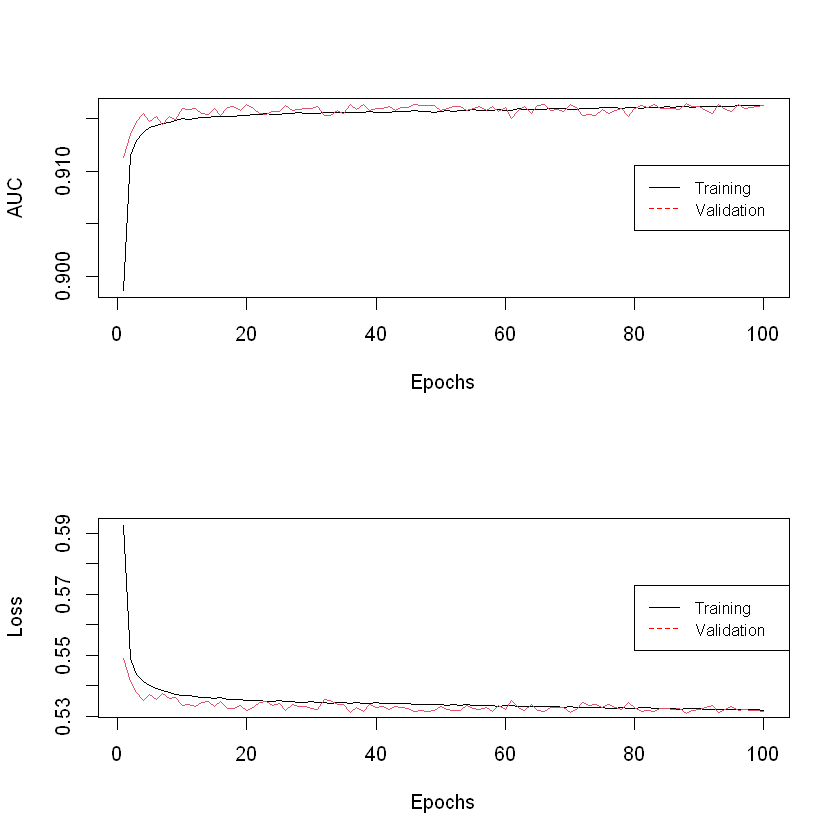

In [7]:
set.seed(2)

k = 5
accuracy_vec <- array(0,k)

nrows<-nrow(dataNN)

# 1. Shuffle the dataset randomly.
dataNN_idx <- sample(1:nrows)

# 2. Split the dataset into k groups
max <- ceiling(nrows/k)
splits <- split(dataNN_idx, ceiling(seq_along(dataNN_idx)/max))

pb <- txtProgressBar(min = 0, max = k, style = 3)
# 3. For each unique group:
for (i in 1:k){
    neuralmodel <- keras_model_sequential() %>% 
    normalizer  %>% 
    layer_dense(15, activation = 'relu') %>%
    layer_dense(3,activation='softmax')

    neuralmodel %>% compile(
        loss = 'categorical_crossentropy',
        optimizer = optimizer_adam(0.001),
        metrics=c('AUC')
    )
    #3.1 Take the group as a hold out or test data set
    test_data <- dataNN[splits[[i]],]


    #3.2 Take the remaining groups as a training data set
    train_data <- dataNN[-splits[[i]],]   

    model_history <- neuralmodel %>% fit(
    as.matrix(train_data[,-target_variables]),
    as.matrix(train_data[,target_variables]),
    validation_split = 0.2,
    verbose = 0,
    epochs = 100
    )

    yhat <- predict(neuralmodel, as.matrix(test_data[-target_variables]))

    yhaty <- classConverter(yhat,test_data)

    accuracy_vec[i]<-F1_Score_micro(yhaty[[2]][,],yhaty[[1]][,])
    setTxtProgressBar(pb, i)
    print(paste("F1-Score Micro -",i,"fold -", 100,'epochs:',accuracy_vec[i]))
    par(mfrow=c(2,1)) 
    plot(1:model_history$params$epochs,model_history$metrics$auc, type='l',xlab="Epochs",ylab='AUC',col=1)
    lines(1:model_history$params$epochs,model_history$metrics$val_auc, type='l',ylab='AUC',col=2)
    legend(x='right', legend=c("Training", "Validation"),col=c("black", "red"), lty=1:2, cex=0.8)
    plot(1:model_history$params$epochs,model_history$metrics$loss, type='l',xlab="Epochs",ylab='Loss',col=1)
    lines(1:model_history$params$epochs,model_history$metrics$val_loss, type='l',ylab='Loss',col=2)
    legend(x='right', legend=c("Training", "Validation"),col=c("black", "red"), lty=1:2, cex=0.8)
    rm('neuralmodel','model_history')
}

#4. Summarize the accuracy of the model using the sample of model evaluation scores
print(paste("Mean F1-Score Micro:",mean(accuracy_vec)))

  |==============                                                        |  20%[1] "F1-Score Micro - 1 fold - 100 epochs: 0.756746330266381"
  |============================                                          |  40%[1] "F1-Score Micro - 2 fold - 100 epochs: 0.754393071388616"
  |==========================================                            |  60%

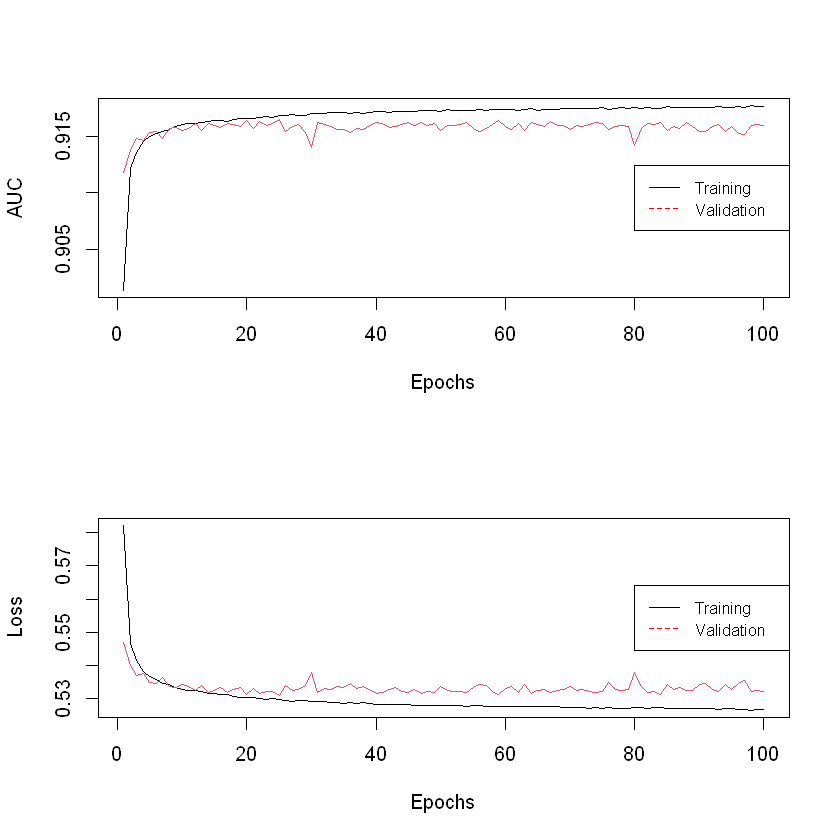

[1] "F1-Score Micro - 3 fold - 100 epochs: 0.753293597978512"
  |========================================================              |  80%

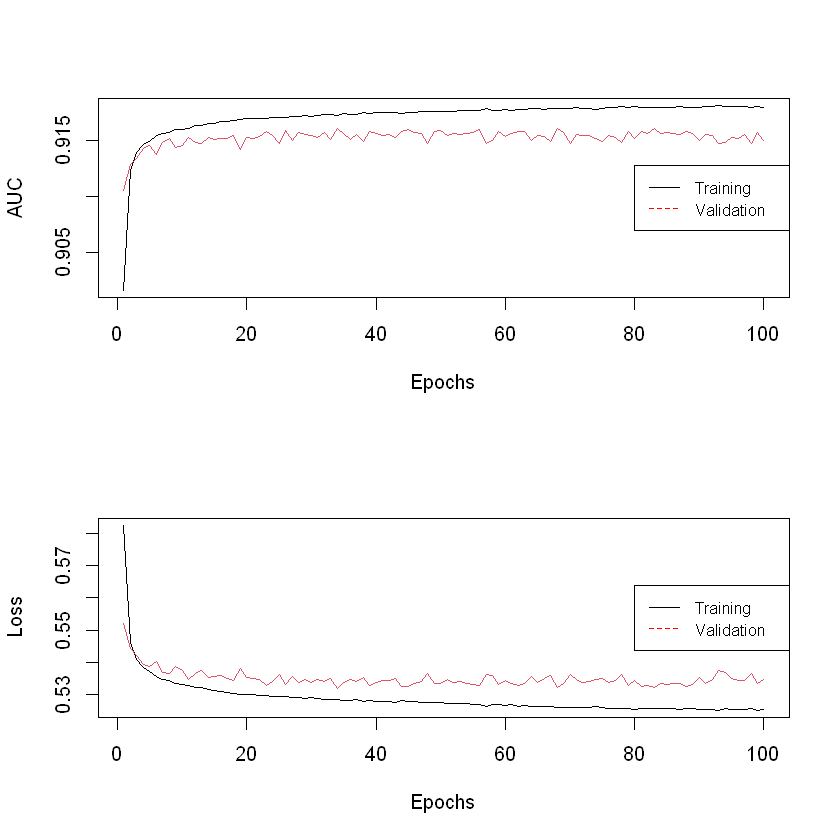

[1] "F1-Score Micro - 4 fold - 100 epochs: 0.756611307216018"
  |======================================================================| 100%

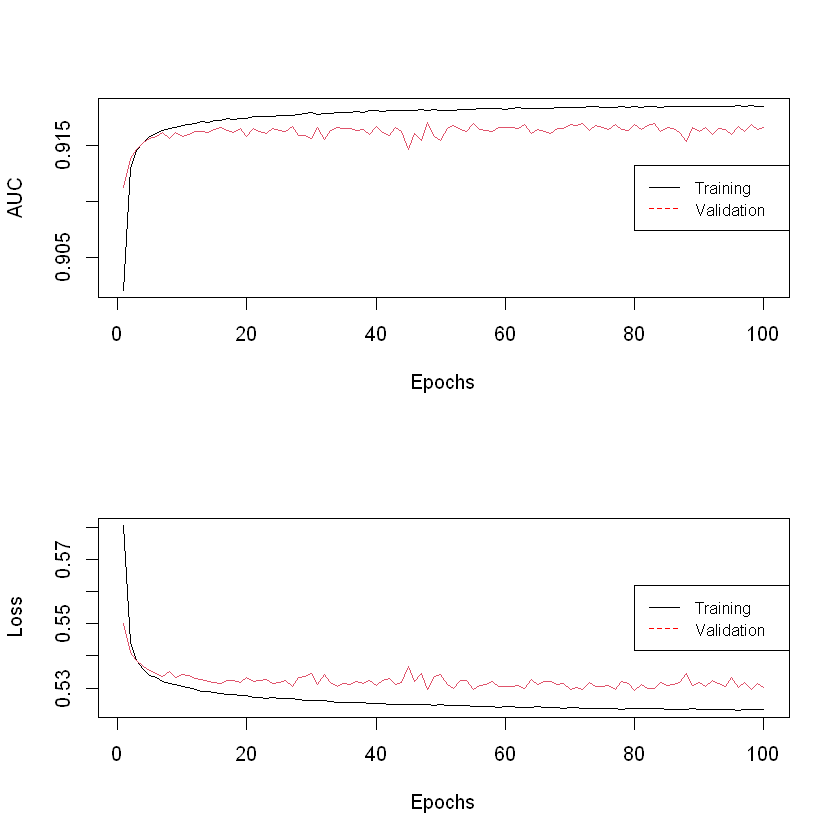

[1] "F1-Score Micro - 5 fold - 100 epochs: 0.756457493393005"


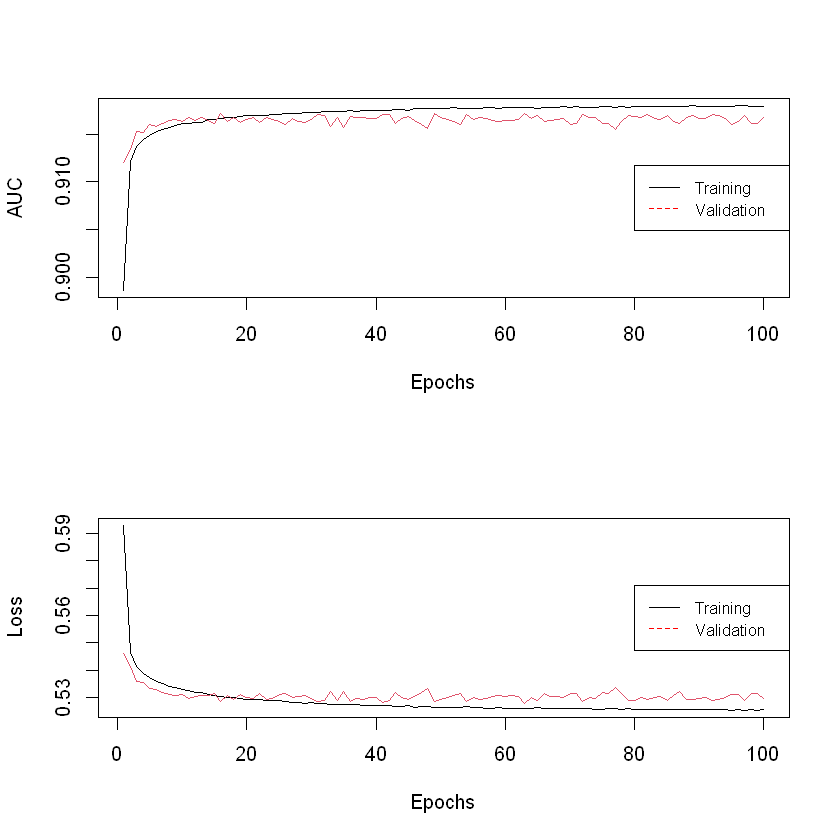

[1] "Mean F1-Score Micro: 0.755500360048506"


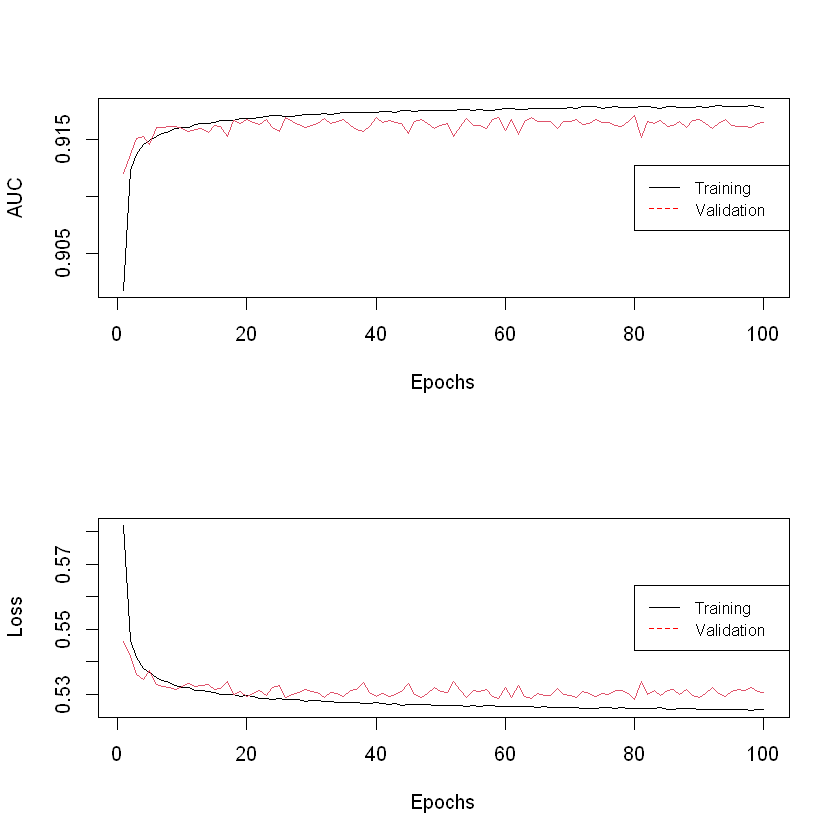

In [9]:
set.seed(2)

k = 5
accuracy_vec <- array(0,k)

nrows<-nrow(dataNN)

# 1. Shuffle the dataset randomly.
dataNN_idx <- sample(1:nrows)

# 2. Split the dataset into k groups
max <- ceiling(nrows/k)
splits <- split(dataNN_idx, ceiling(seq_along(dataNN_idx)/max))

pb <- txtProgressBar(min = 0, max = k, style = 3)
# 3. For each unique group:
for (i in 1:k){
    neuralmodel <- keras_model_sequential() %>% 
    normalizer  %>% 
    layer_dense(25, activation = 'relu') %>%
    layer_dense(3,activation='softmax')

    neuralmodel %>% compile(
        loss = 'categorical_crossentropy',
        optimizer = optimizer_adam(0.001),
        metrics=c('AUC')
    )
    #3.1 Take the group as a hold out or test data set
    test_data <- dataNN[splits[[i]],]


    #3.2 Take the remaining groups as a training data set
    train_data <- dataNN[-splits[[i]],]   

    model_history <- neuralmodel %>% fit(
    as.matrix(train_data[,-target_variables]),
    as.matrix(train_data[,target_variables]),
    validation_split = 0.2,
    verbose = 0,
    epochs = 100
    )

    yhat <- predict(neuralmodel, as.matrix(test_data[-target_variables]))

    yhaty <- classConverter(yhat,test_data)

    accuracy_vec[i]<-F1_Score_micro(yhaty[[2]][,],yhaty[[1]][,])
    setTxtProgressBar(pb, i)
    print(paste("F1-Score Micro -",i,"fold -", 100,'epochs:',accuracy_vec[i]))
    par(mfrow=c(2,1)) 
    plot(1:model_history$params$epochs,model_history$metrics$auc, type='l',xlab="Epochs",ylab='AUC',col=1)
    lines(1:model_history$params$epochs,model_history$metrics$val_auc, type='l',ylab='AUC',col=2)
    legend(x='right', legend=c("Training", "Validation"),col=c("black", "red"), lty=1:2, cex=0.8)
    plot(1:model_history$params$epochs,model_history$metrics$loss, type='l',xlab="Epochs",ylab='Loss',col=1)
    lines(1:model_history$params$epochs,model_history$metrics$val_loss, type='l',ylab='Loss',col=2)
    legend(x='right', legend=c("Training", "Validation"),col=c("black", "red"), lty=1:2, cex=0.8)
    rm('neuralmodel','model_history')
}

#4. Summarize the accuracy of the model using the sample of model evaluation scores
print(paste("Mean F1-Score Micro:",mean(accuracy_vec)))

  |==============                                                        |  20%[1] "F1-Score Micro - 1 fold - 100 epochs: 0.756919931331134"
  |============================                                          |  40%[1] "F1-Score Micro - 2 fold - 100 epochs: 0.753775823158382"
  |==========================================                            |  60%

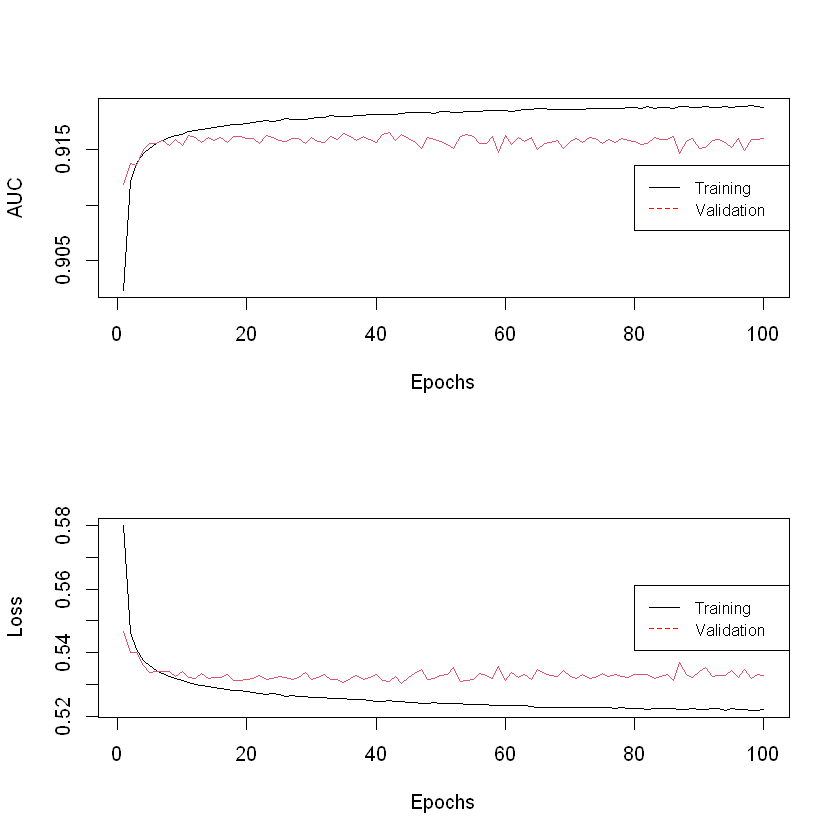

[1] "F1-Score Micro - 3 fold - 100 epochs: 0.754258048338252"
  |========================================================              |  80%

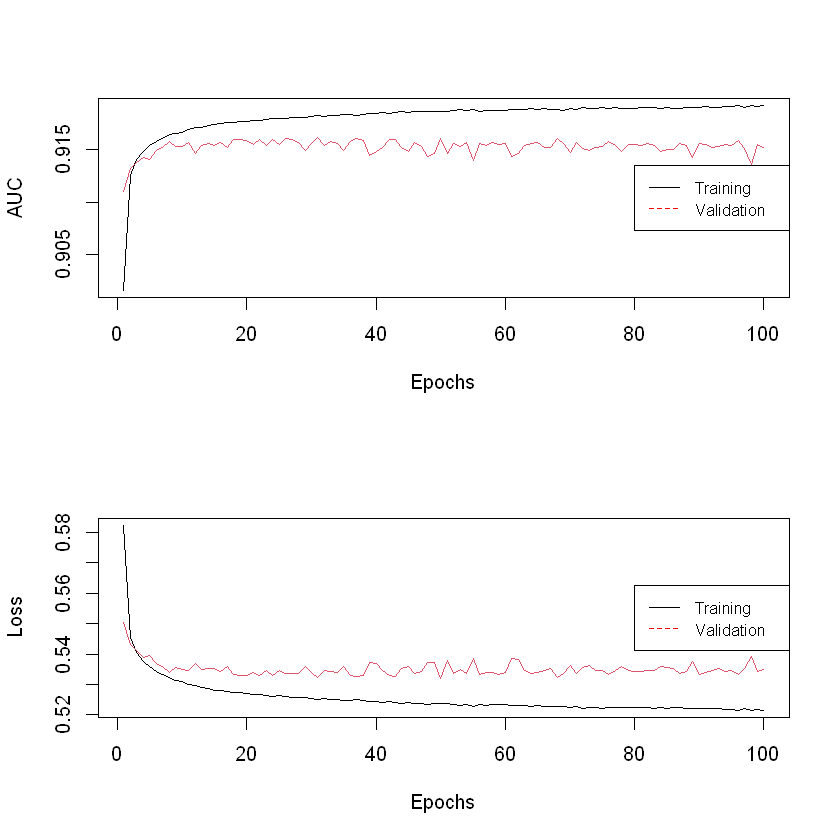

[1] "F1-Score Micro - 4 fold - 100 epochs: 0.755299654726771"
  |======================================================================| 100%

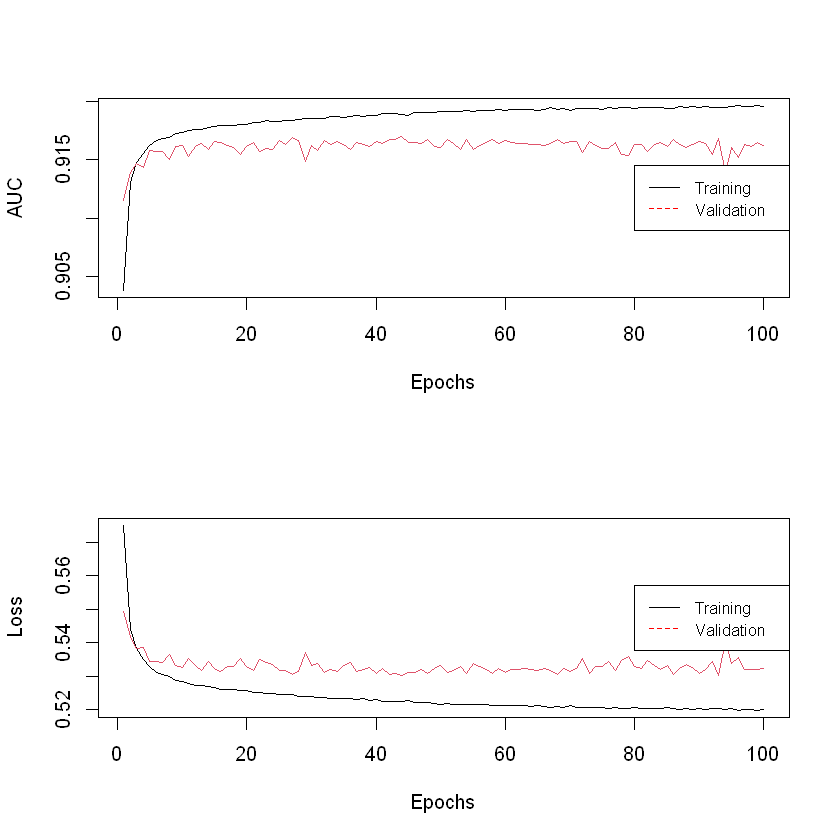

[1] "F1-Score Micro - 5 fold - 100 epochs: 0.753602500048226"


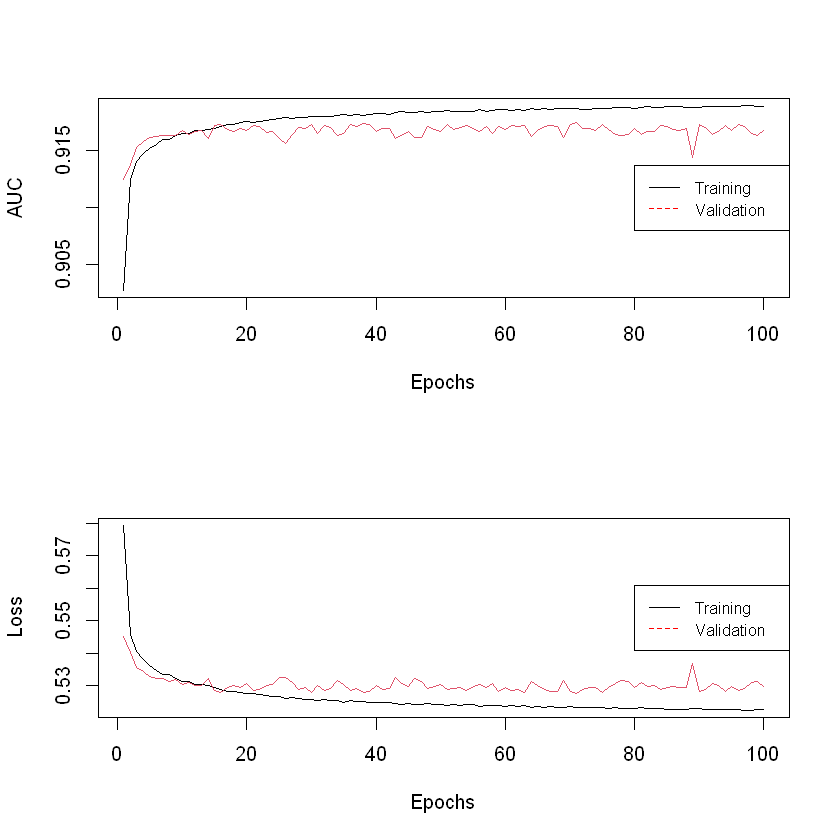

[1] "Mean F1-Score Micro: 0.754771191520553"


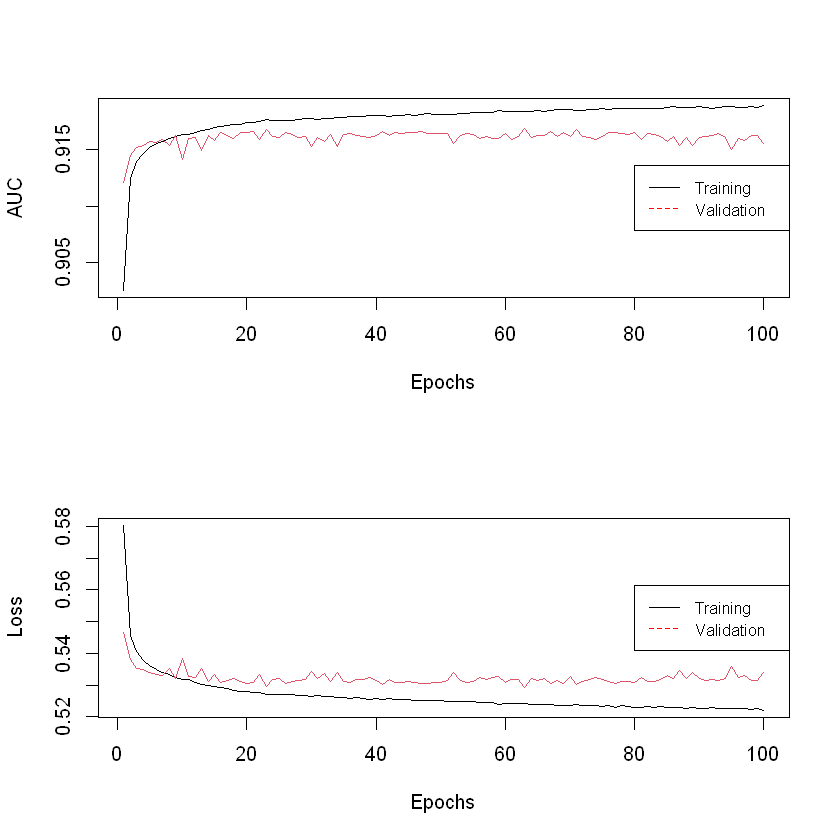

In [8]:
set.seed(2)

k = 5
accuracy_vec <- array(0,k)

nrows<-nrow(dataNN)

# 1. Shuffle the dataset randomly.
dataNN_idx <- sample(1:nrows)

# 2. Split the dataset into k groups
max <- ceiling(nrows/k)
splits <- split(dataNN_idx, ceiling(seq_along(dataNN_idx)/max))

pb <- txtProgressBar(min = 0, max = k, style = 3)
# 3. For each unique group:
for (i in 1:k){
    neuralmodel <- keras_model_sequential() %>% 
    normalizer  %>% 
    layer_dense(37, activation = 'relu') %>%
    layer_dense(3,activation='softmax')

    neuralmodel %>% compile(
        loss = 'categorical_crossentropy',
        optimizer = optimizer_adam(0.001),
        metrics=c('AUC')
    )
    #3.1 Take the group as a hold out or test data set
    test_data <- dataNN[splits[[i]],]


    #3.2 Take the remaining groups as a training data set
    train_data <- dataNN[-splits[[i]],]   

    model_history <- neuralmodel %>% fit(
    as.matrix(train_data[,-target_variables]),
    as.matrix(train_data[,target_variables]),
    validation_split = 0.2,
    verbose = 0,
    epochs = 100
    )

    yhat <- predict(neuralmodel, as.matrix(test_data[-target_variables]))

    yhaty <- classConverter(yhat,test_data)

    accuracy_vec[i]<-F1_Score_micro(yhaty[[2]][,],yhaty[[1]][,])
    setTxtProgressBar(pb, i)
    print(paste("F1-Score Micro -",i,"fold -", 100,'epochs:',accuracy_vec[i]))
    par(mfrow=c(2,1)) 
    plot(1:model_history$params$epochs,model_history$metrics$auc, type='l',xlab="Epochs",ylab='AUC',col=1)
    lines(1:model_history$params$epochs,model_history$metrics$val_auc, type='l',ylab='AUC',col=2)
    legend(x='right', legend=c("Training", "Validation"),col=c("black", "red"), lty=1:2, cex=0.8)
    plot(1:model_history$params$epochs,model_history$metrics$loss, type='l',xlab="Epochs",ylab='Loss',col=1)
    lines(1:model_history$params$epochs,model_history$metrics$val_loss, type='l',ylab='Loss',col=2)
    legend(x='right', legend=c("Training", "Validation"),col=c("black", "red"), lty=1:2, cex=0.8)
    rm('neuralmodel','model_history')
}

#4. Summarize the accuracy of the model using the sample of model evaluation scores
print(paste("Mean F1-Score Micro:",mean(accuracy_vec)))

  |=======                                                               |  10%[1] "F1-Score Micro - 1 fold - 30 epochs: 0.756500270040892"
  |==============                                                        |  20%[1] "F1-Score Micro - 2 fold - 30 epochs: 0.758351979013965"
  |=====================                                                 |  30%

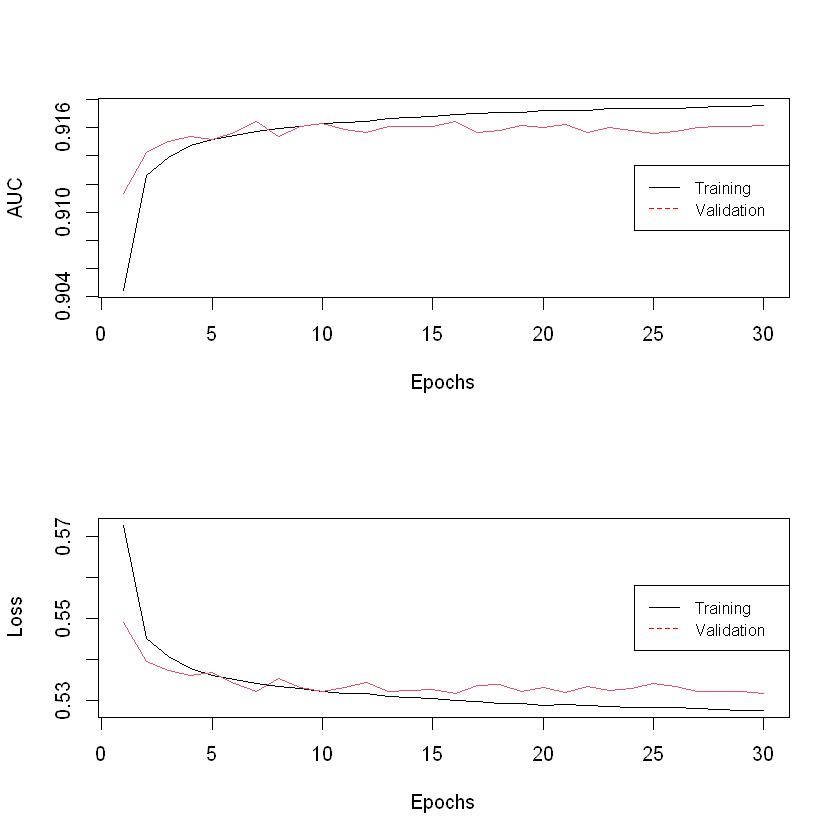

[1] "F1-Score Micro - 3 fold - 30 epochs: 0.753491242959648"
  |============================                                          |  40%

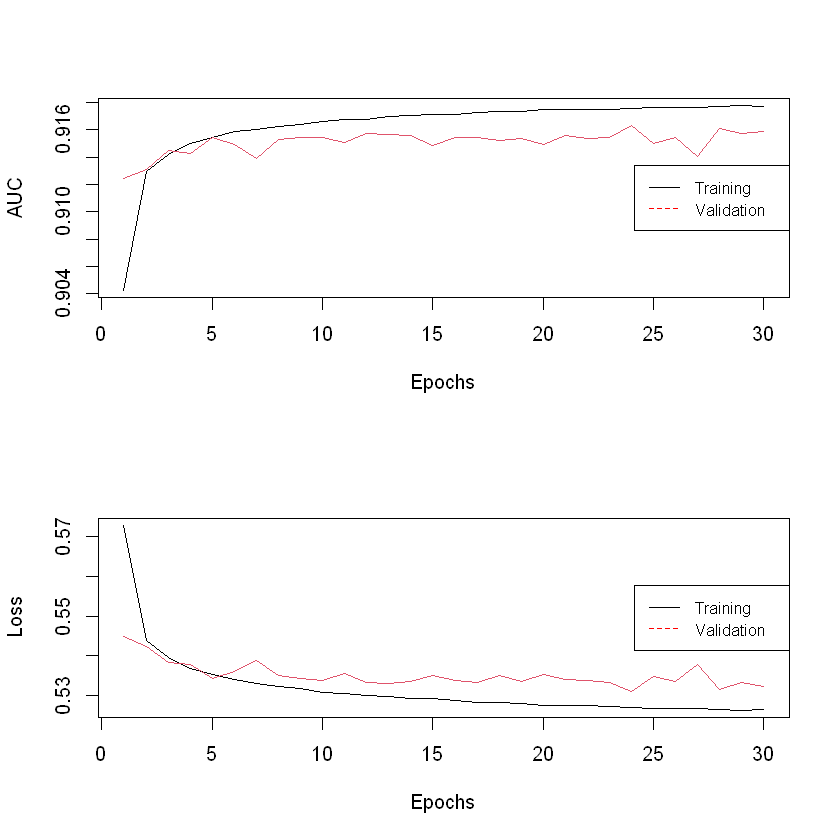

[1] "F1-Score Micro - 4 fold - 30 epochs: 0.756693156392254"
  |===================================                                   |  50%

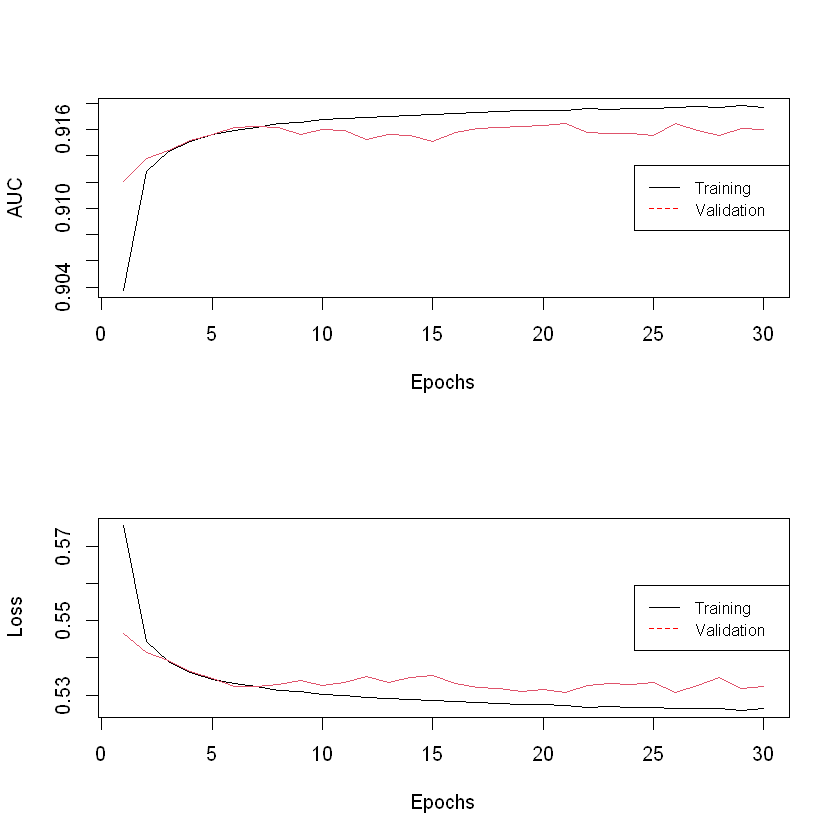

[1] "F1-Score Micro - 5 fold - 30 epochs: 0.754455674716457"
  |==========================================                            |  60%

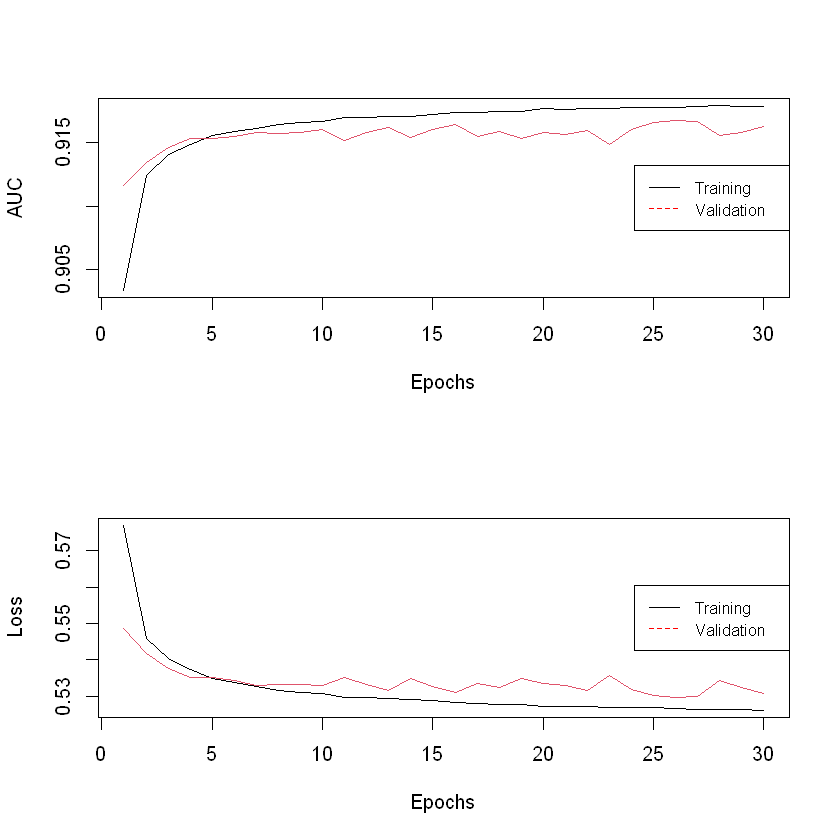

[1] "F1-Score Micro - 6 fold - 30 epochs: 0.752063883959571"
  |=================================================                     |  70%

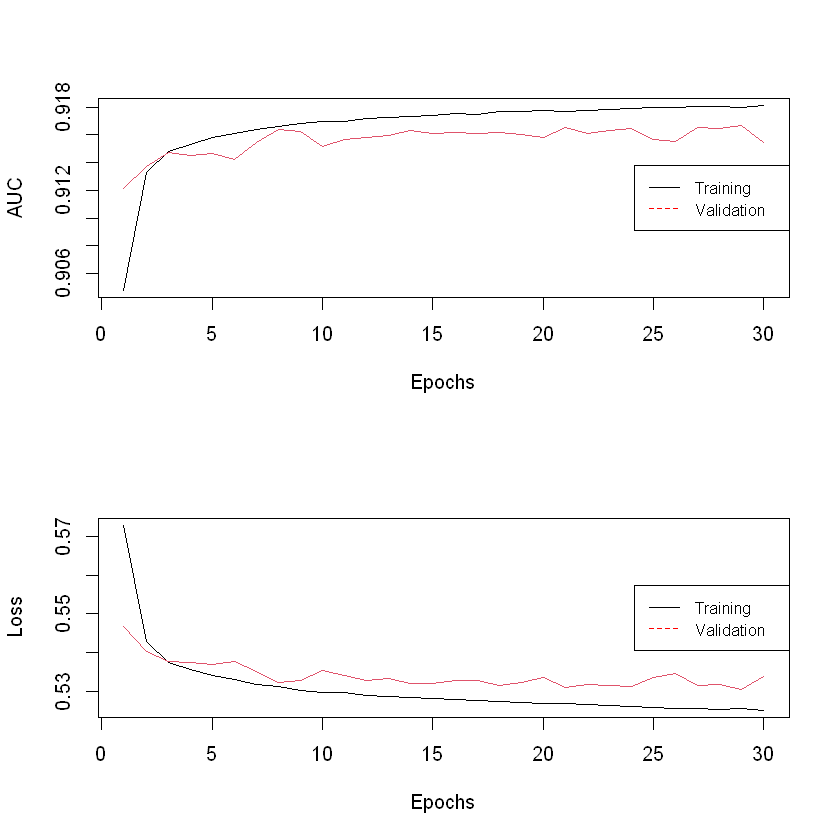

[1] "F1-Score Micro - 7 fold - 30 epochs: 0.755767301905717"
  |========================================================              |  80%

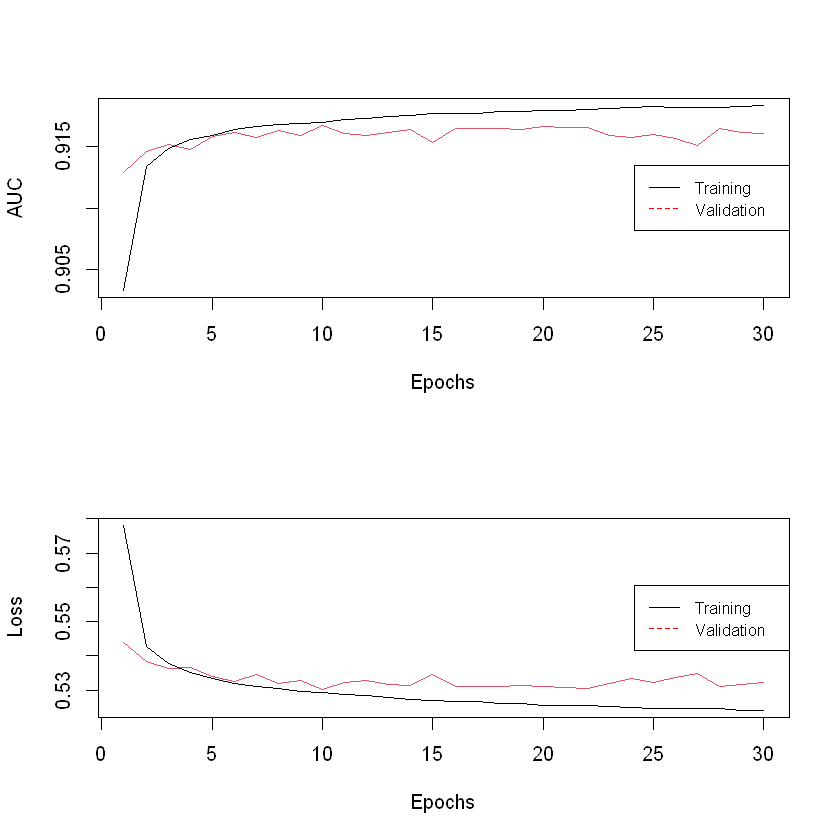

[1] "F1-Score Micro - 8 fold - 30 epochs: 0.75827482447342"
  |===============================================================       |  90%

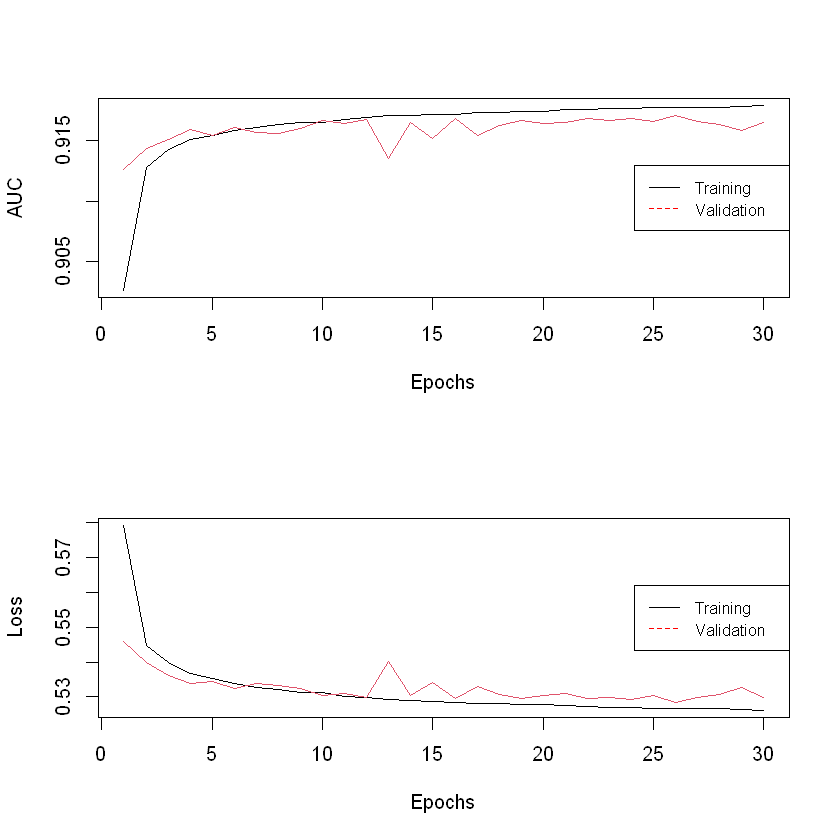

[1] "F1-Score Micro - 9 fold - 30 epochs: 0.757541856338246"
  |======================================================================| 100%

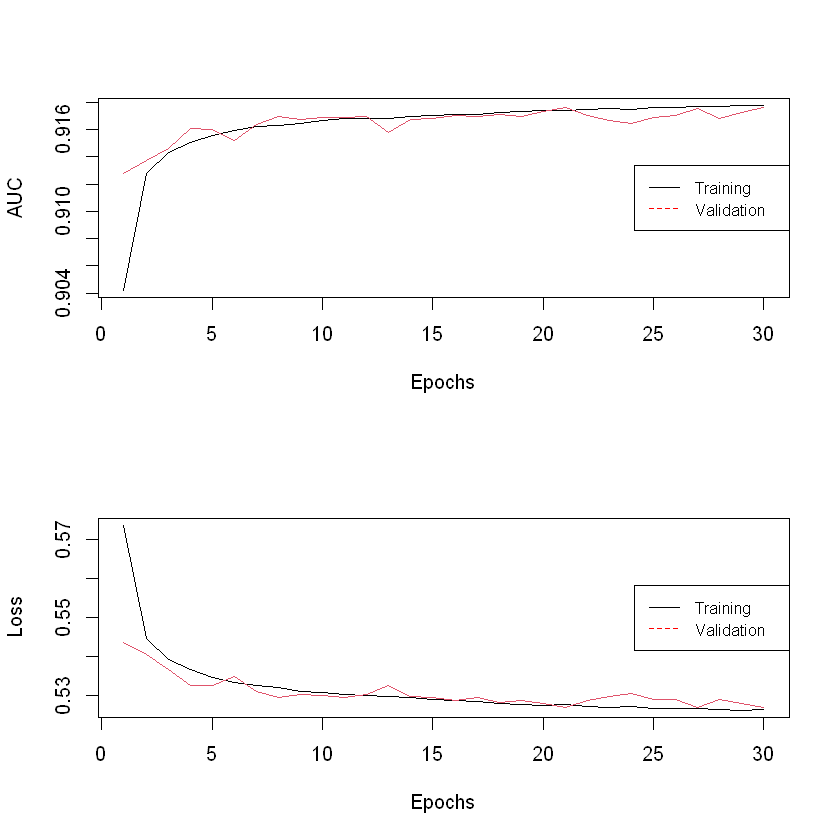

[1] "F1-Score Micro - 10 fold - 30 epochs: 0.755721066646085"


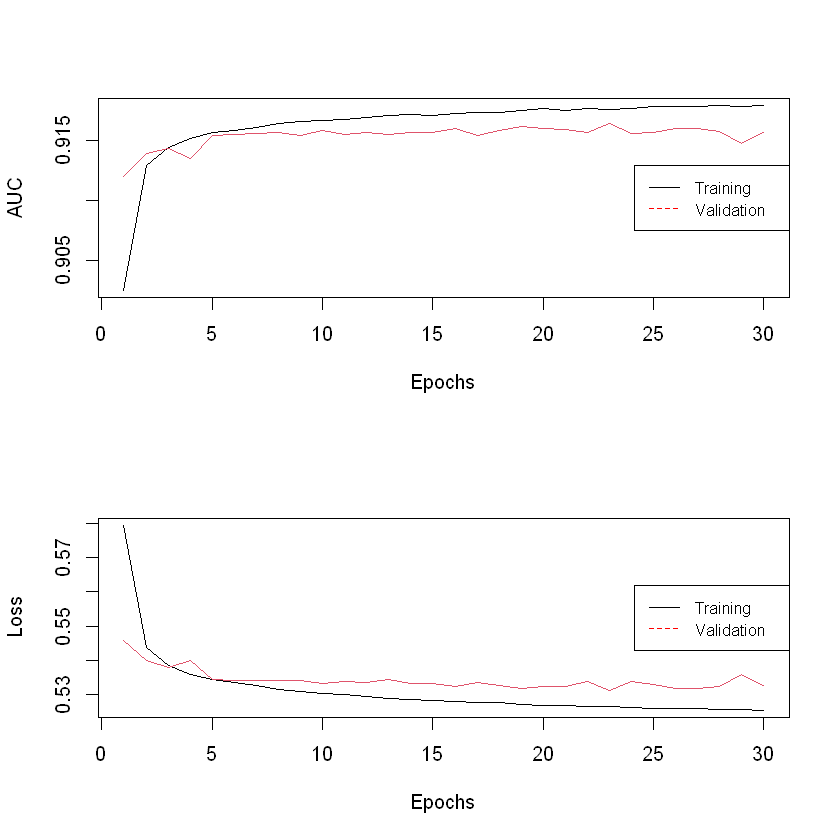

[1] "Mean F1-Score Micro: 0.755886125644625"


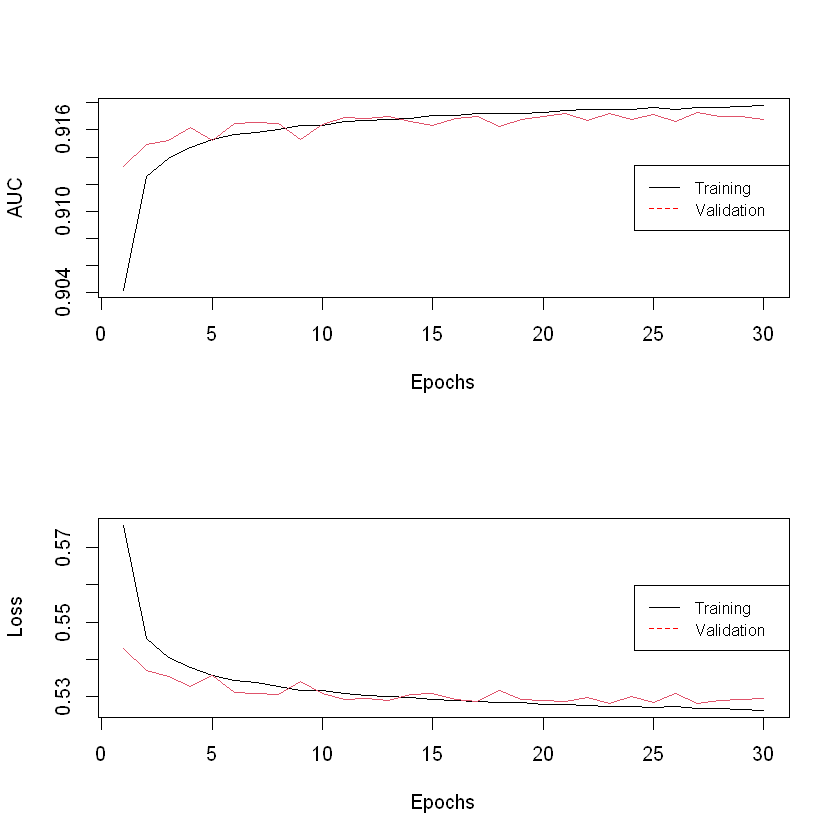

In [10]:
set.seed(2)
k = 10

accuracy_vec <- array(0,k)

nrows<-nrow(dataNN)

# 1. Shuffle the dataset randomly.
dataNN_idx <- sample(1:nrows)

# 2. Split the dataset into k groups
max <- ceiling(nrows/k)
splits <- split(dataNN_idx, ceiling(seq_along(dataNN_idx)/max))

pb <- txtProgressBar(min = 0, max = k, style = 3)
# 3. For each unique group:
for (i in 1:k){
    for (j in 6:6){
        
        neuralmodel <- keras_model_sequential() %>% 
        normalizer  %>% 
        layer_dense(35, activation = 'relu') %>%
        layer_dense(3,activation='softmax')

        neuralmodel %>% compile(
            loss = 'categorical_crossentropy',
            optimizer = optimizer_adam(0.001),
            metrics=c('AUC')
        )
        #3.1 Take the group as a hold out or test data set
        test_data <- dataNN[splits[[i]],]


        #3.2 Take the remaining groups as a training data set
        train_data <- dataNN[-splits[[i]],]   

        model_history <- neuralmodel %>% fit(
        as.matrix(train_data[,-target_variables]),
        as.matrix(train_data[,target_variables]),
        validation_split = 0.2,
        verbose = 0,
        epochs = 5*j
        )

        yhat <- predict(neuralmodel, as.matrix(test_data[-target_variables]))

        yhaty <- classConverter(yhat,test_data)

        accuracy_vec[i]<-F1_Score_micro(yhaty[[2]][,],yhaty[[1]][,])
        setTxtProgressBar(pb, i)
        print(paste("F1-Score Micro -",i,"fold -", 5*j,'epochs:',accuracy_vec[i]))
        par(mfrow=c(2,1)) 
        plot(1:model_history$params$epochs,model_history$metrics$auc, type='l',xlab="Epochs",ylab='AUC',col=1)
        lines(1:model_history$params$epochs,model_history$metrics$val_auc, type='l',ylab='AUC',col=2)
        legend(x='right', legend=c("Training", "Validation"),col=c("black", "red"), lty=1:2, cex=0.8)
        plot(1:model_history$params$epochs,model_history$metrics$loss, type='l',xlab="Epochs",ylab='Loss',col=1)
        lines(1:model_history$params$epochs,model_history$metrics$val_loss, type='l',ylab='Loss',col=2)
        legend(x='right', legend=c("Training", "Validation"),col=c("black", "red"), lty=1:2, cex=0.8)
        rm('neuralmodel','model_history')
    }
}

#4. Summarize the accuracy of the model using the sample of model evaluation scores
print(paste("Mean F1-Score Micro:",mean(accuracy_vec)))

  |==============                                                        |  20%[1] "F1-Score Micro - 1 fold - Learning rate 1e-04 :  0.757132110410277"
[1] "F1-Score Micro - 1 fold - Learning rate 5e-04 :  0.75682348629516"


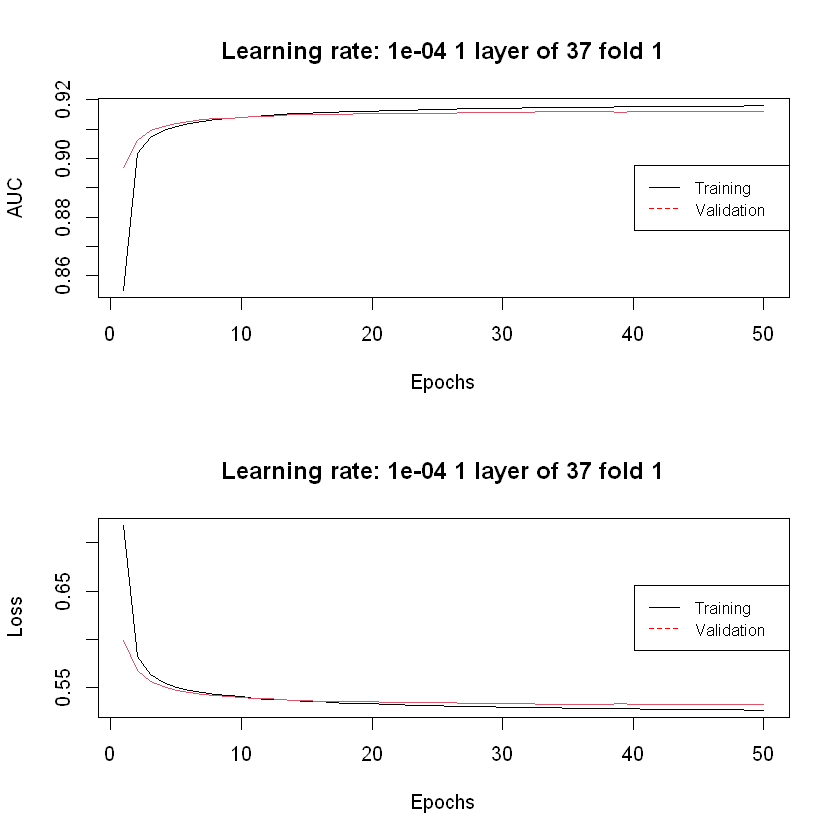

[1] "F1-Score Micro - 1 fold - Learning rate 0.001 :  0.755627567849083"


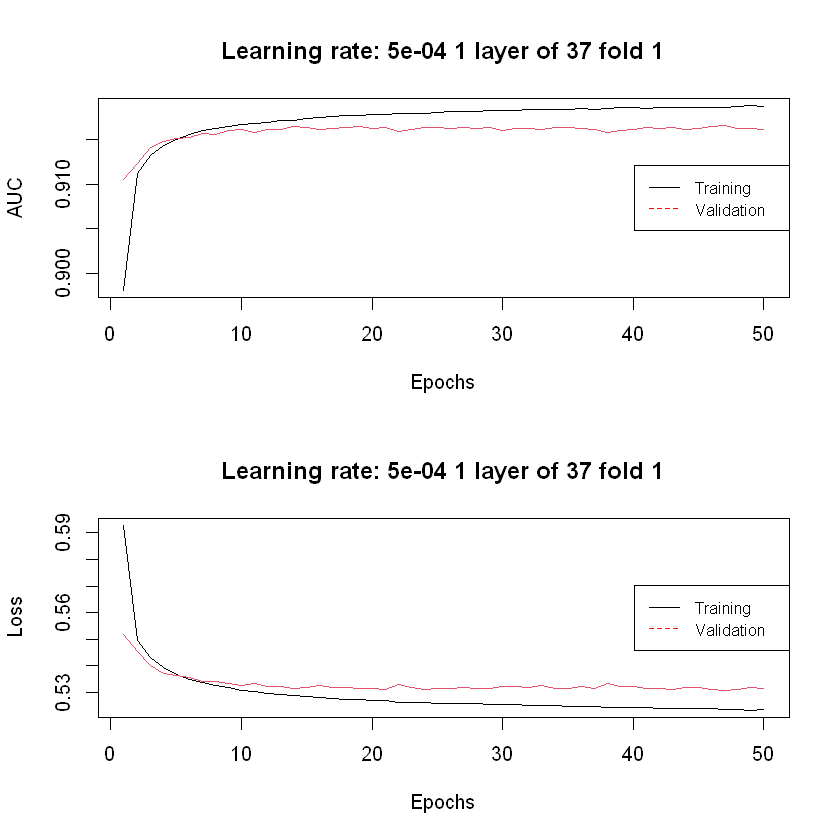

[1] "F1-Score Micro - 1 fold - Learning rate 0.005 :  0.753100707906564"
  |============================                                          |  40%

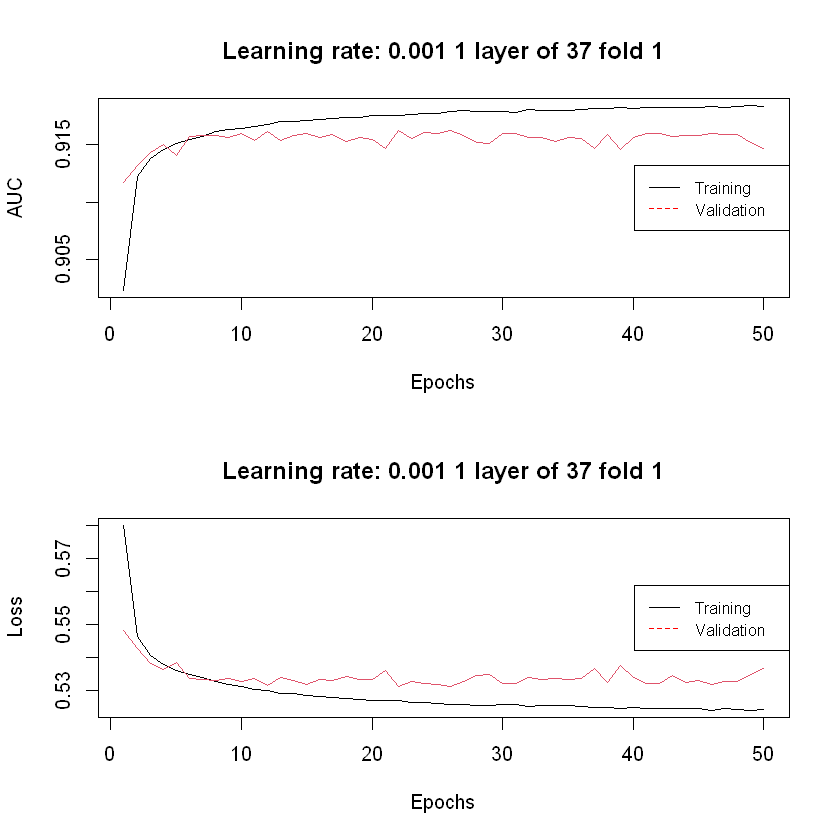

[1] "F1-Score Micro - 2 fold - Learning rate 1e-04 :  0.755916902957005"


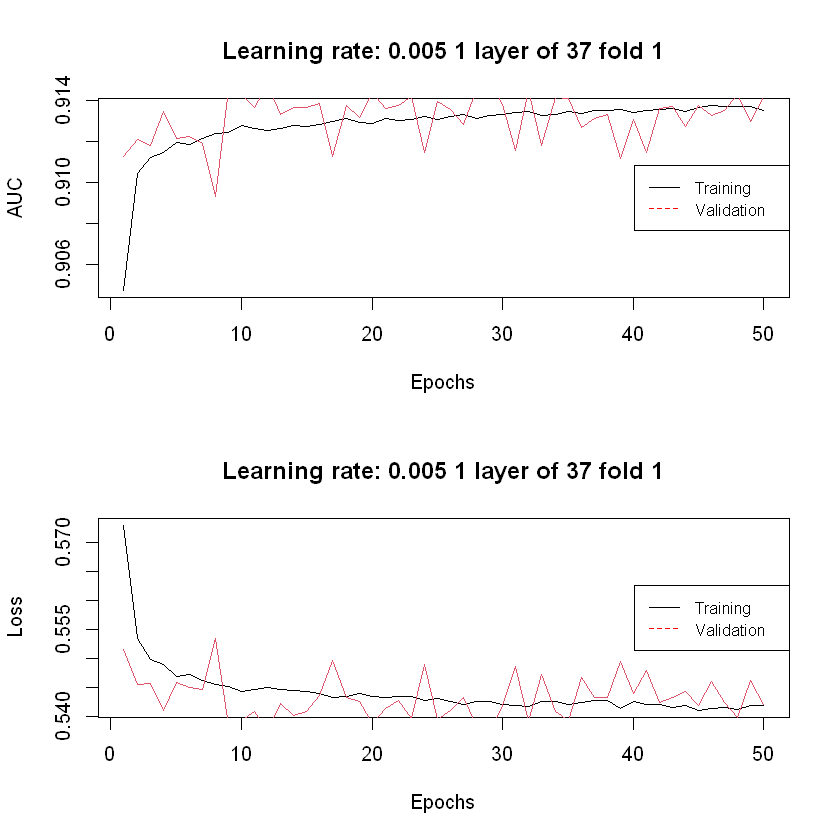

[1] "F1-Score Micro - 2 fold - Learning rate 5e-04 :  0.753370754007291"


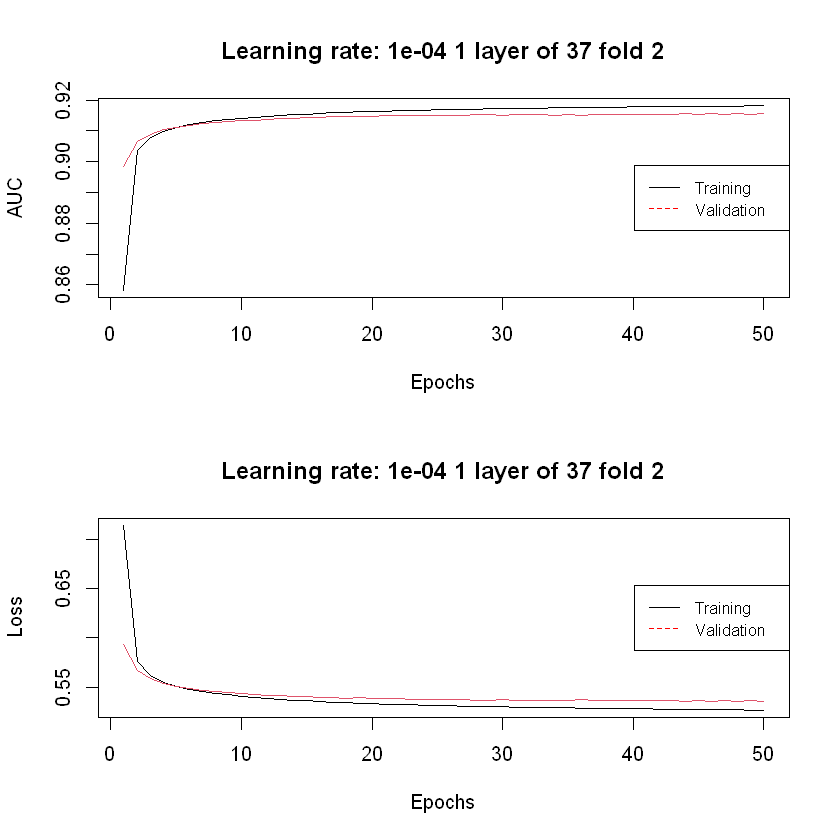

[1] "F1-Score Micro - 2 fold - Learning rate 0.001 :  0.75396871323033"


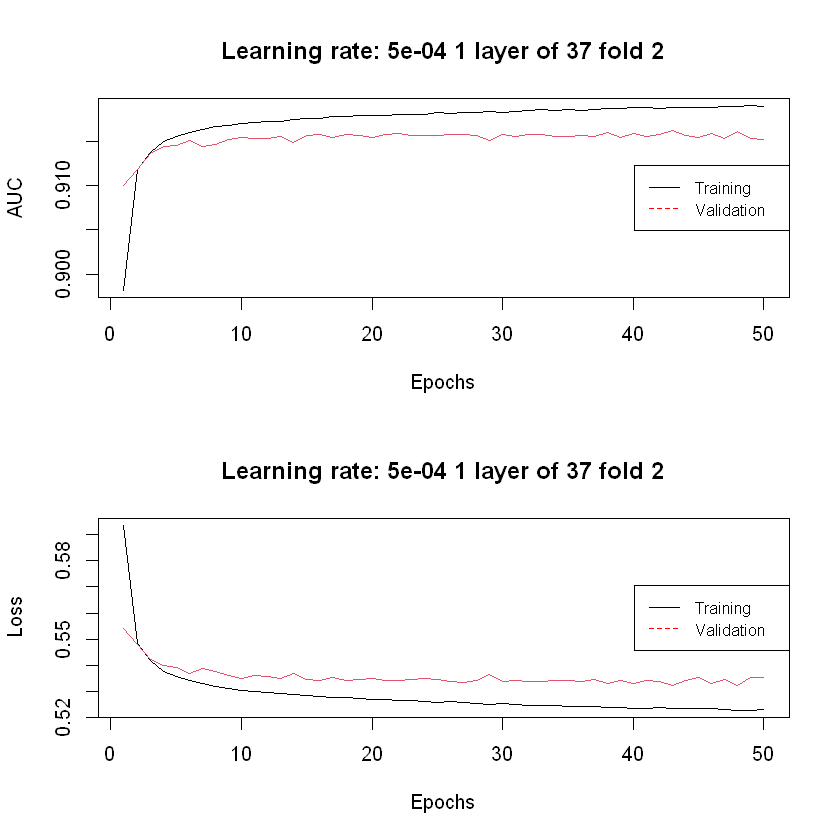

[1] "F1-Score Micro - 2 fold - Learning rate 0.005 :  0.749763709661864"
  |==========================================                            |  60%

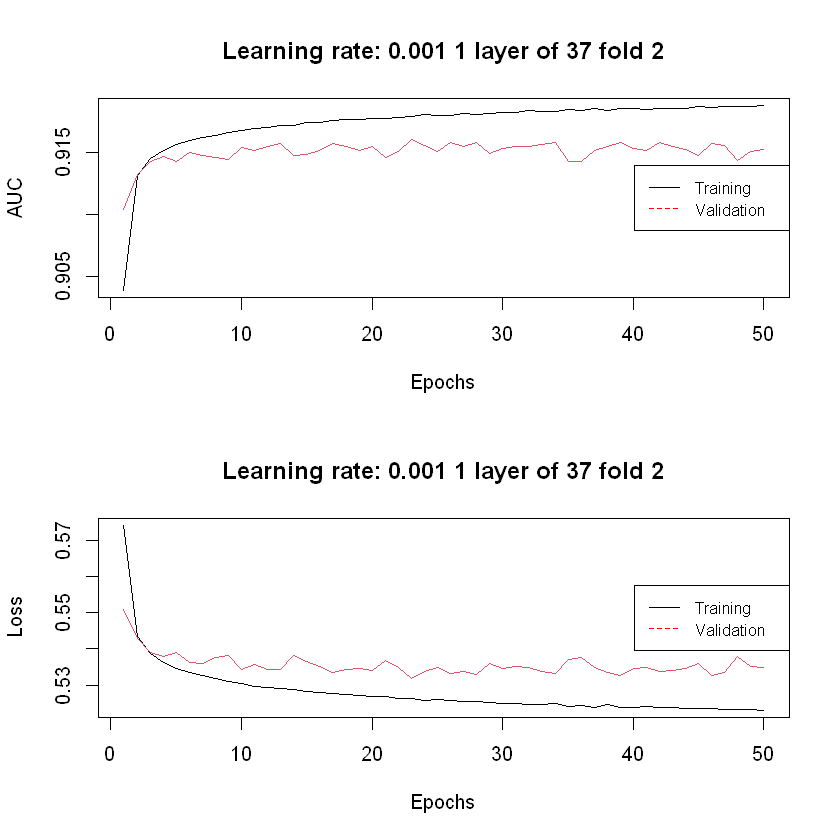

[1] "F1-Score Micro - 3 fold - Learning rate 1e-04 :  0.75393013521594"


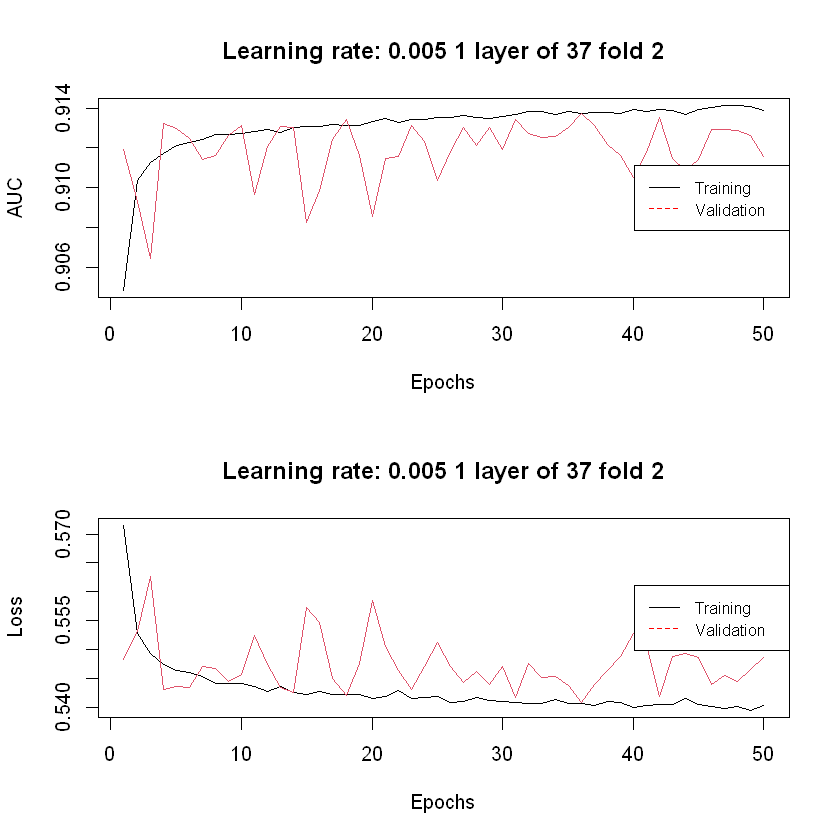

[1] "F1-Score Micro - 3 fold - Learning rate 5e-04 :  0.751924078467681"


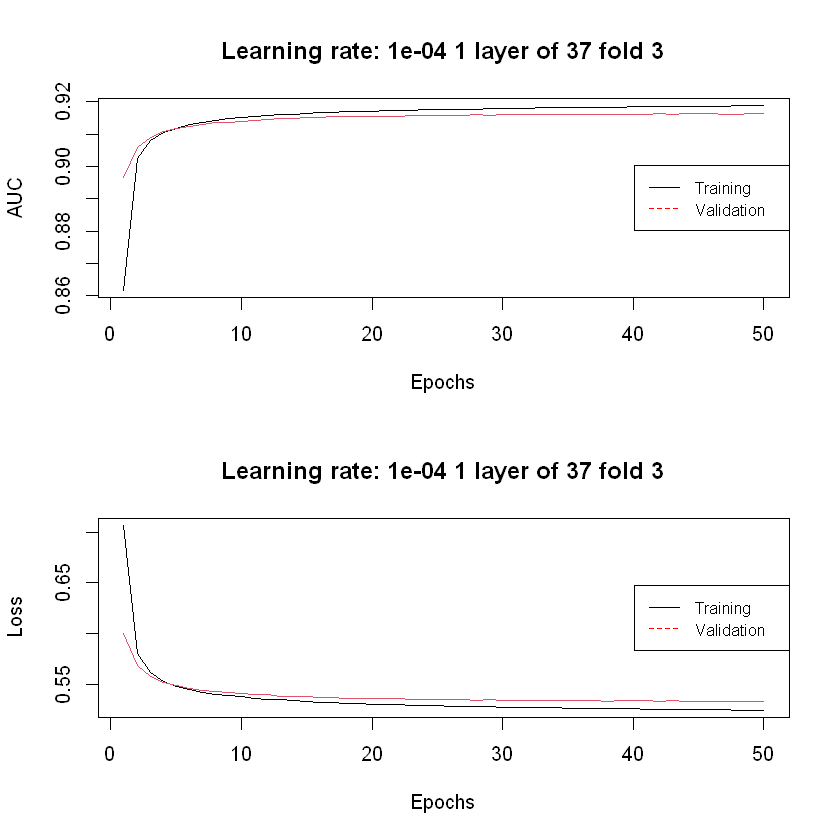

[1] "F1-Score Micro - 3 fold - Learning rate 0.001 :  0.751673321374149"


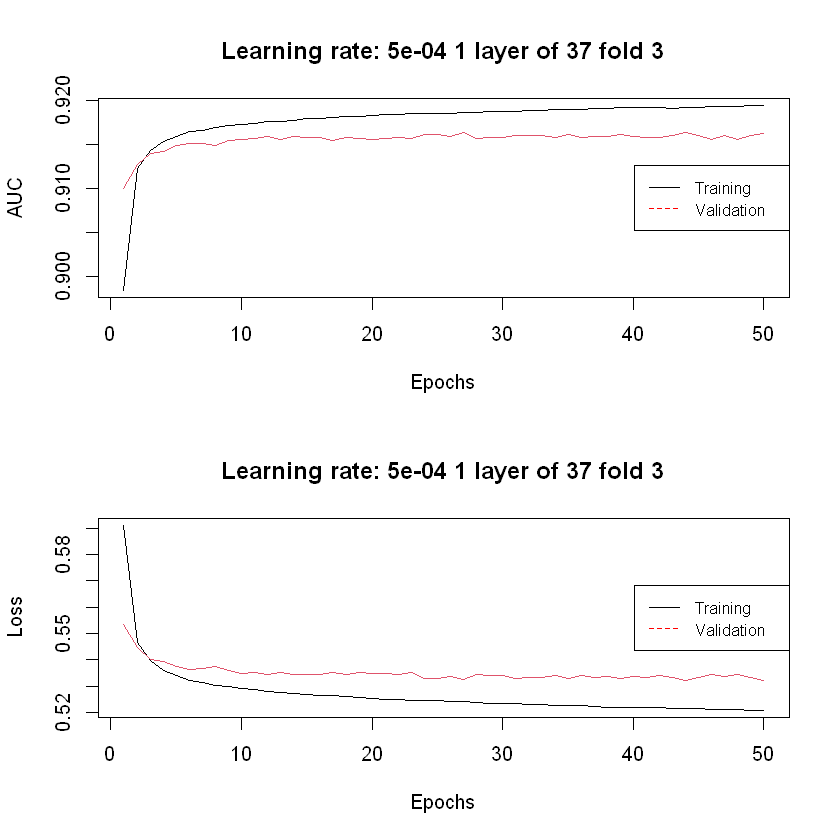

[1] "F1-Score Micro - 3 fold - Learning rate 0.005 :  0.752194124568409"
  |========================================================              |  80%

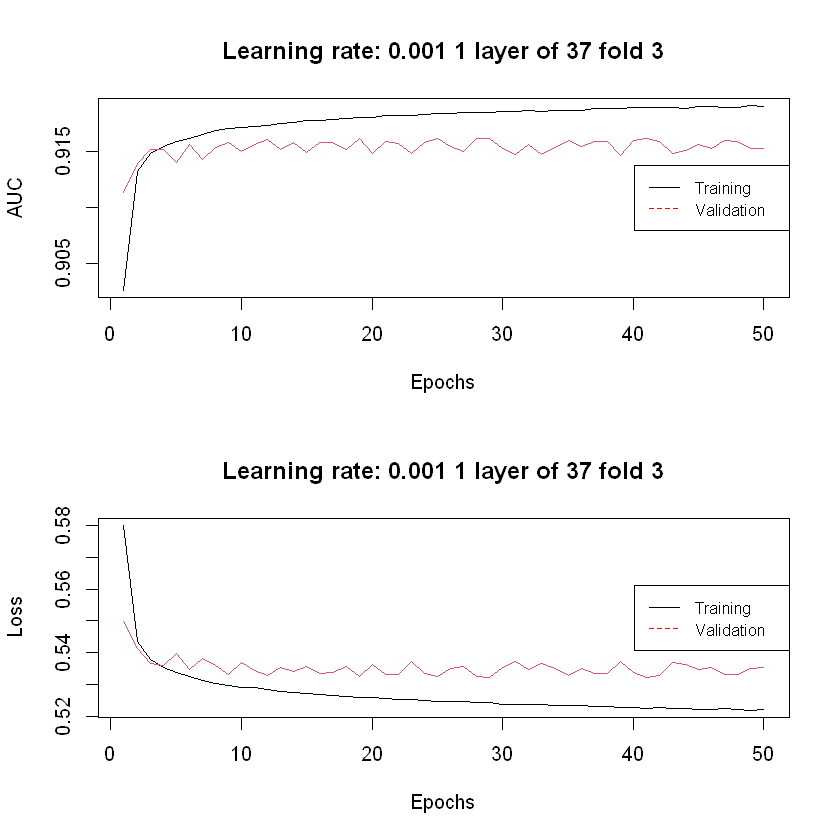

[1] "F1-Score Micro - 4 fold - Learning rate 1e-04 :  0.756437706151264"


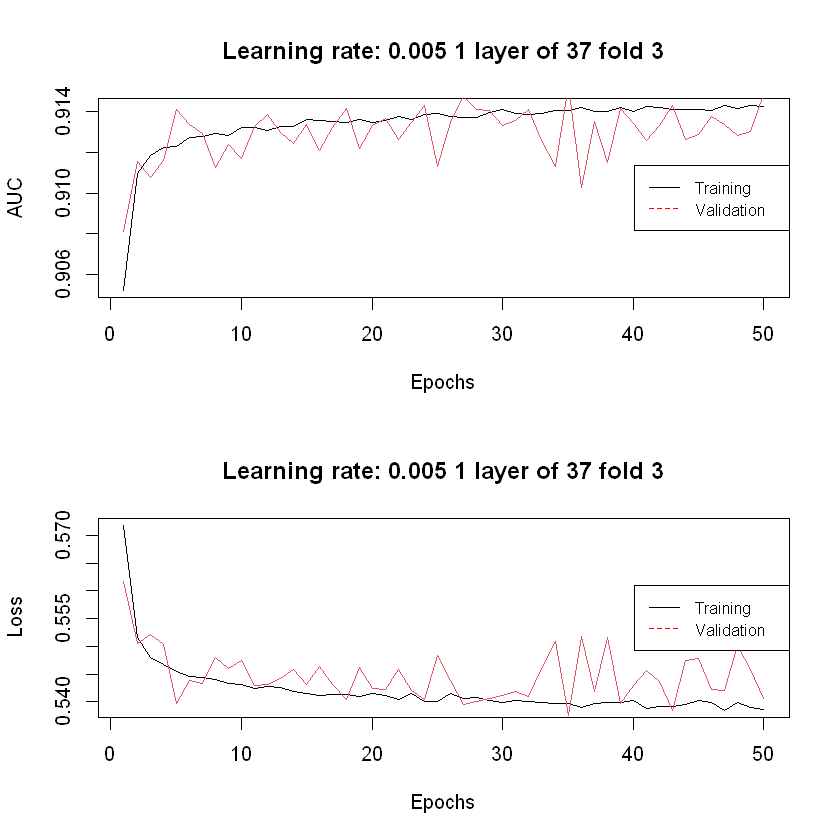

[1] "F1-Score Micro - 4 fold - Learning rate 5e-04 :  0.754740273518122"


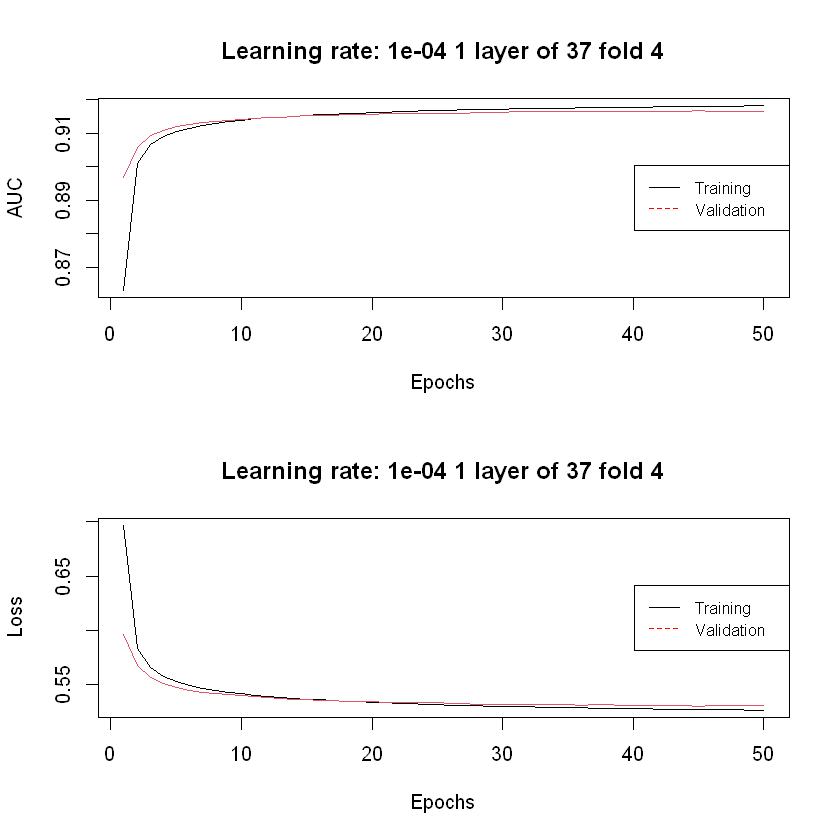

[1] "F1-Score Micro - 4 fold - Learning rate 0.001 :  0.756399128136875"


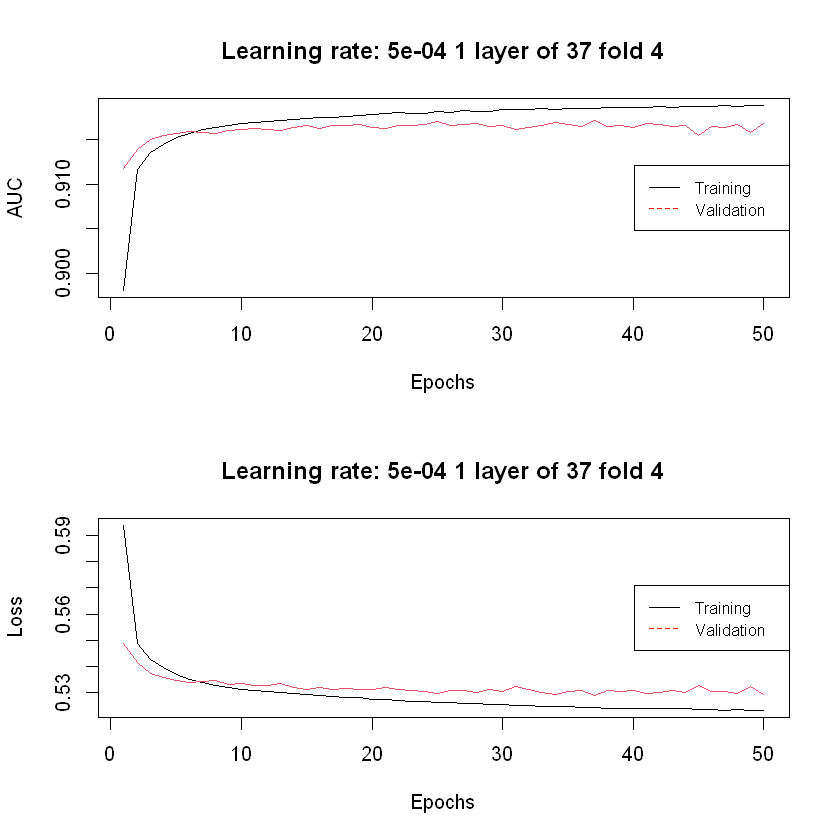

[1] "F1-Score Micro - 4 fold - Learning rate 0.005 :  0.751191096194279"
  |======================================================================| 100%

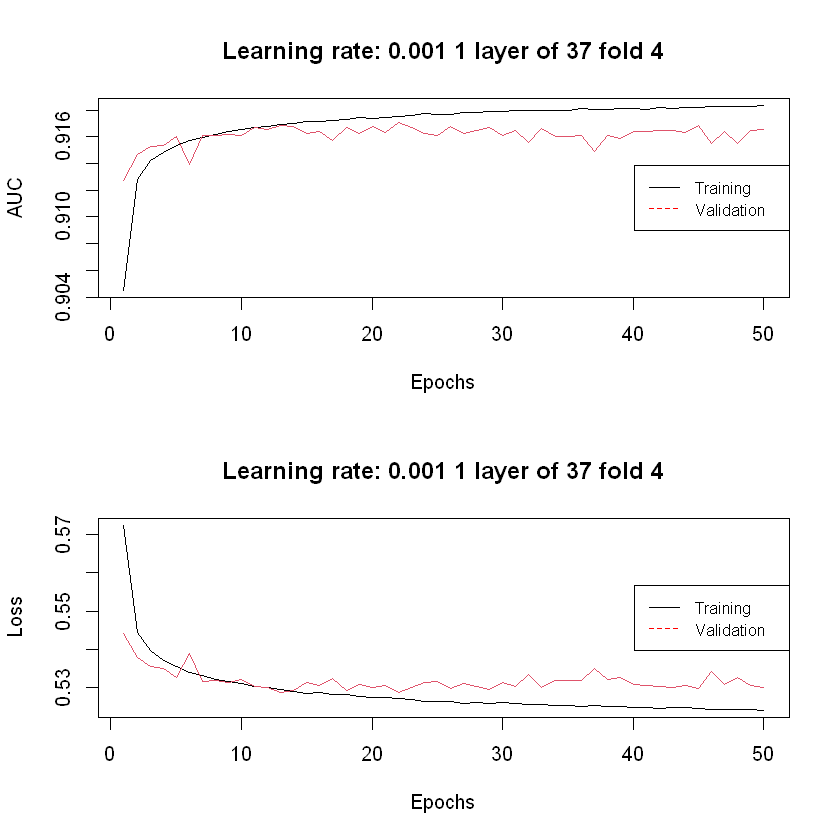

[1] "F1-Score Micro - 5 fold - Learning rate 1e-04 :  0.756843303304462"


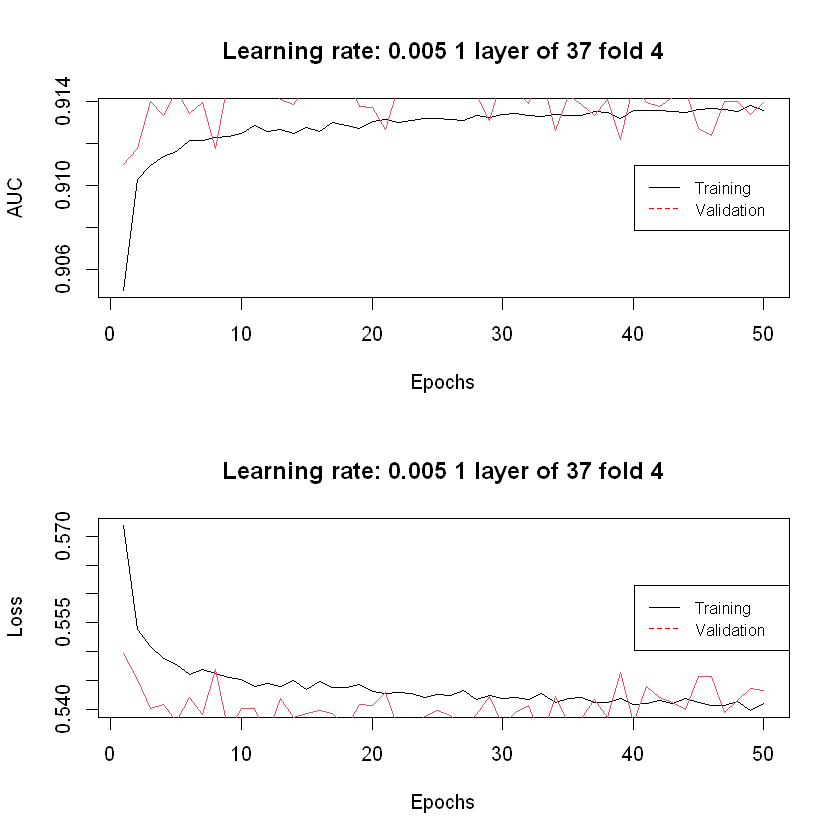

[1] "F1-Score Micro - 5 fold - Learning rate 5e-04 :  0.756592526862015"


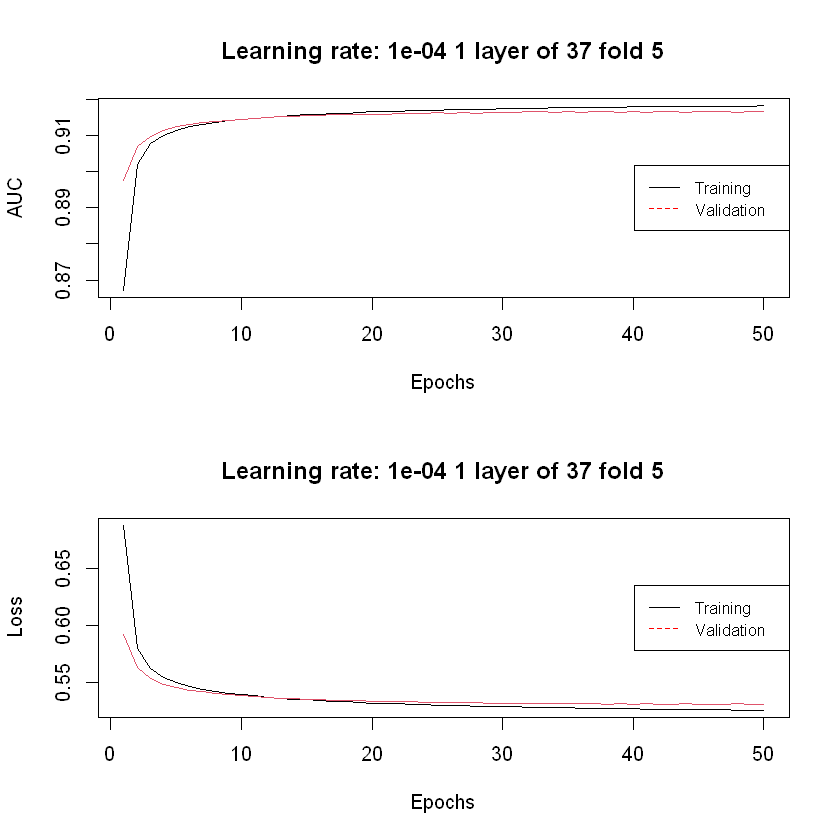

[1] "F1-Score Micro - 5 fold - Learning rate 0.001 :  0.756920465286753"


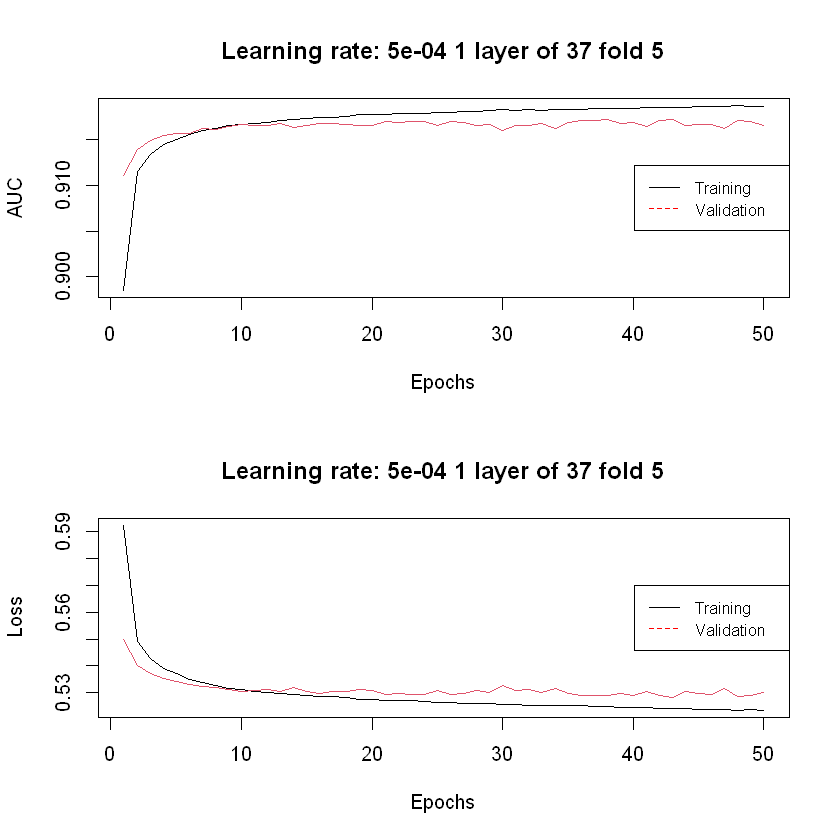

[1] "F1-Score Micro - 5 fold - Learning rate 0.005 :  0.750516020756573"


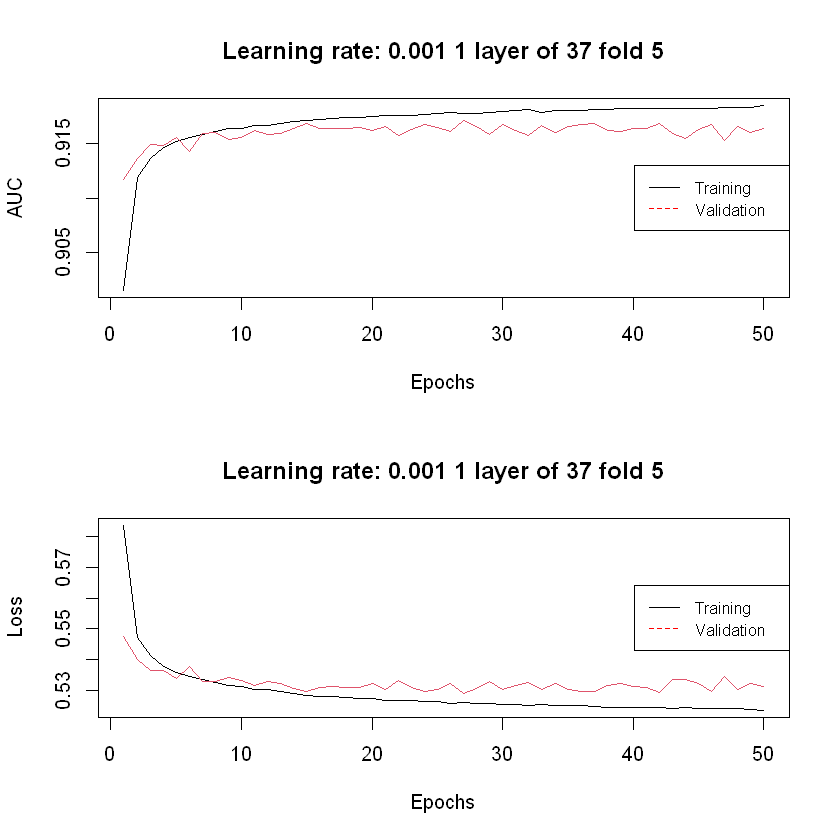

,fold,learning_rate,F1
,<dbl>,<dbl>,<dbl>
1,1,1e-04,0.7571321
2,1,5e-04,0.7568235
3,1,1e-03,0.7556276
4,1,5e-03,0.7531007
5,2,1e-04,0.7559169
6,2,5e-04,0.7533708
7,2,1e-03,0.7539687
8,2,5e-03,0.7497637
9,3,1e-04,0.7539301


,learning_rate,mean F1
,<dbl>,<dbl>
1,1e-04,0.7560520
2,5e-04,0.7546902
3,1e-03,0.7549178
4,5e-03,0.7513531


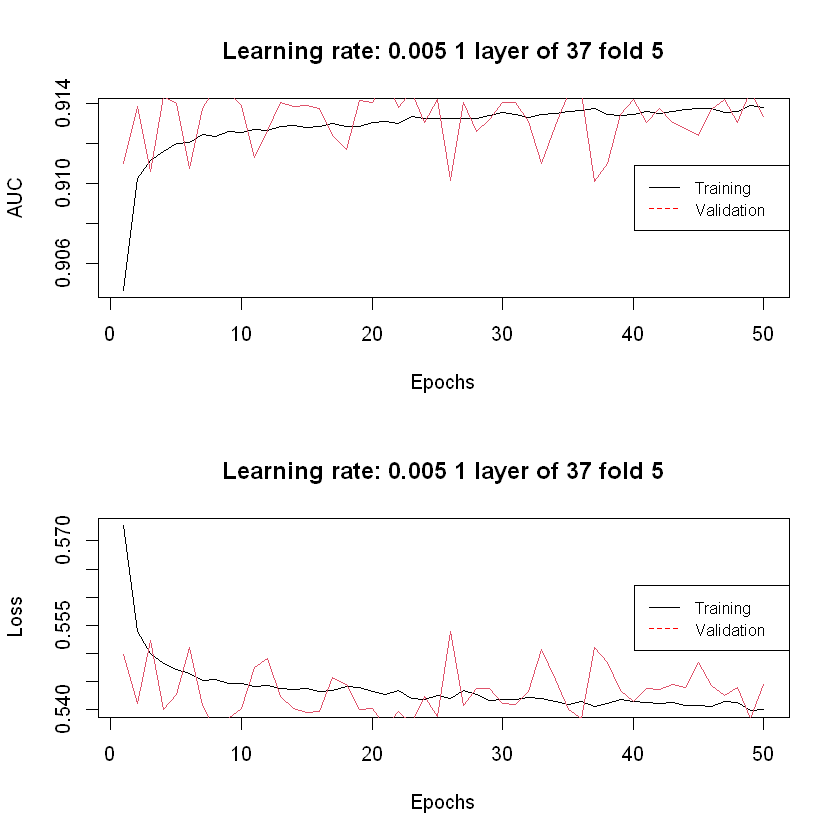

In [11]:
set.seed(2)
k = 5

accuracy_vec <- data.frame(matrix(ncol = 3, nrow = 0))
colnames(accuracy_vec)<-c('fold','learning_rate','F1')

# 1. Shuffle the dataset randomly.
dataNN_idx <- sample(1:nrows)

# 2. Split the dataset into k groups
max <- ceiling(nrows/k)
splits <- split(dataNN_idx, ceiling(seq_along(dataNN_idx)/max))

pb <- txtProgressBar(min = 0, max = k, style = 3)
# 3. For each unique group:
for (i in 1:k){
    for (j in c(0.0001,0.0005,0.001,0.005)){
        
        neuralmodel <- keras_model_sequential() %>% 
        normalizer  %>% 
        layer_dense(37, activation = 'relu') %>%
        layer_dense(3,activation='softmax')

        neuralmodel %>% compile(
            loss = 'categorical_crossentropy',
            optimizer = optimizer_adam(j),
            metrics=c('AUC')
        )
        #3.1 Take the group as a hold out or test data set
        test_data <- dataNN[splits[[i]],]

        #3.2 Take the remaining groups as a training data set
        train_data <- dataNN[-splits[[i]],]   

        model_history <- neuralmodel %>% fit(
        as.matrix(train_data[,-target_variables]),
        as.matrix(train_data[,target_variables]),
        validation_split = 0.2,
        verbose = 0,
        epochs = 50
        )

        yhat <- predict(neuralmodel, as.matrix(test_data[-target_variables]))

        yhaty <- classConverter(yhat,test_data)
        accuracy_vec[nrow(accuracy_vec)+1,]<-c(i,j,F1_Score_micro(yhaty[[2]][,],yhaty[[1]][,]))
        setTxtProgressBar(pb, i)
        print(paste("F1-Score Micro -",i,"fold -",'Learning rate',j,': ',accuracy_vec[nrow(accuracy_vec),3]))
        par(mfrow=c(2,1)) 
        plot(1:model_history$params$epochs,model_history$metrics$auc, type='l',xlab="Epochs",ylab='AUC',main=paste('Learning rate:',j, '1 layer of 37', 'fold',i),col=1)
        lines(1:model_history$params$epochs,model_history$metrics$val_auc, type='l',ylab='AUC',col=2)
        legend(x='right', legend=c("Training", "Validation"),col=c("black", "red"), lty=1:2, cex=0.8)
        plot(1:model_history$params$epochs,model_history$metrics$loss, type='l',xlab="Epochs",ylab='Loss',main=paste('Learning rate:',j, '1 layer of 37', 'fold', i),col=1)
        lines(1:model_history$params$epochs,model_history$metrics$val_loss, type='l',ylab='Loss',col=2)
        legend(x='right', legend=c("Training", "Validation"),col=c("black", "red"), lty=1:2, cex=0.8)
        rm('neuralmodel','model_history')
    }
}

#4. Summarize the accuracy of the model using the sample of model evaluation scores
meanF1 <- data.frame(matrix(ncol = 2, nrow = 0))
colnames(meanF1)<-c('learning_rate','mean F1')
for (i in c(0.0001,0.0005,0.001,0.005)){
    meanF1[nrow(meanF1)+1,]<-c(i,mean(filter(accuracy_vec,(learning_rate==i))$F1))
}

accuracy_vec
meanF1

#358 min

In [12]:
accuracy_vec
meanF1

,fold,learning_rate,F1
,<dbl>,<dbl>,<dbl>
1,1,1e-04,0.7571321
2,1,5e-04,0.7568235
3,1,1e-03,0.7556276
4,1,5e-03,0.7531007
5,2,1e-04,0.7559169
6,2,5e-04,0.7533708
7,2,1e-03,0.7539687
8,2,5e-03,0.7497637
9,3,1e-04,0.7539301


,learning_rate,mean F1
,<dbl>,<dbl>
1,1e-04,0.7560520
2,5e-04,0.7546902
3,1e-03,0.7549178
4,5e-03,0.7513531


  |=======                                                               |  10%[1] "F1-Score Micro - 1 fold - Learning rate 1e-04 :  0.756924620013888"
[1] "F1-Score Micro - 1 fold - Learning rate 5e-04 :  0.757696165419335"


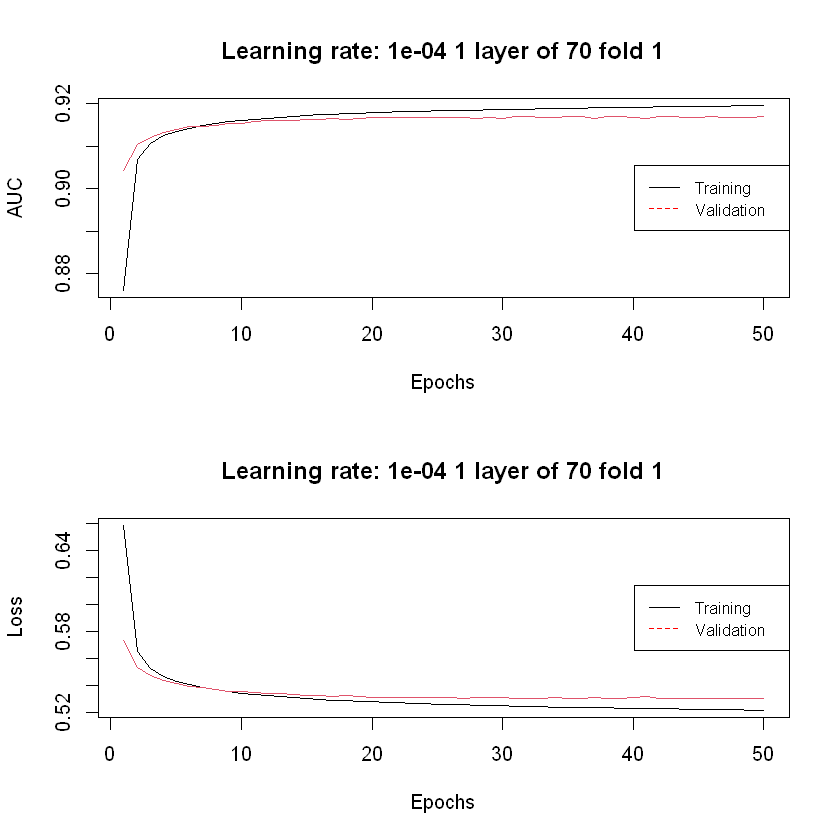

[1] "F1-Score Micro - 1 fold - Learning rate 0.001 :  0.756153074608441"


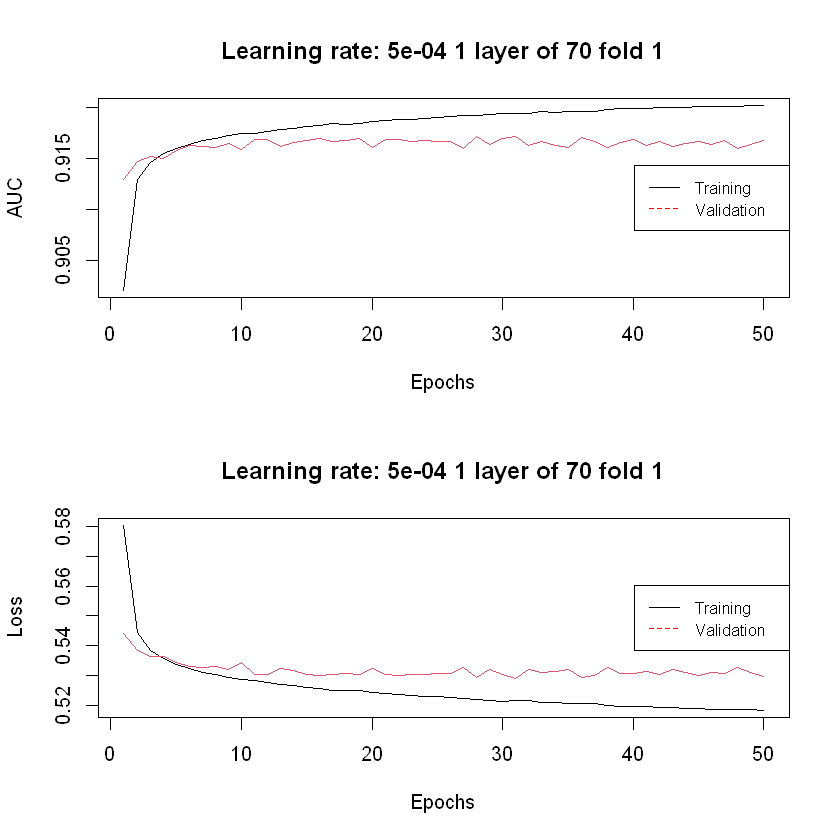

[1] "F1-Score Micro - 1 fold - Learning rate 0.005 :  0.751639533986575"
  |==============                                                        |  20%

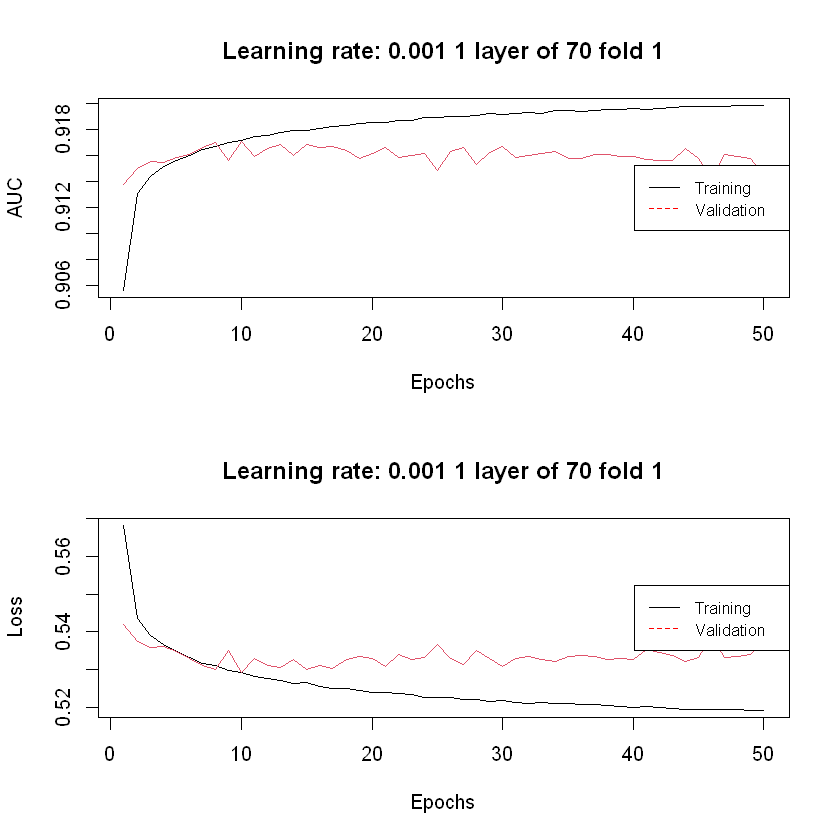

[1] "F1-Score Micro - 2 fold - Learning rate 1e-04 :  0.75842913355451"


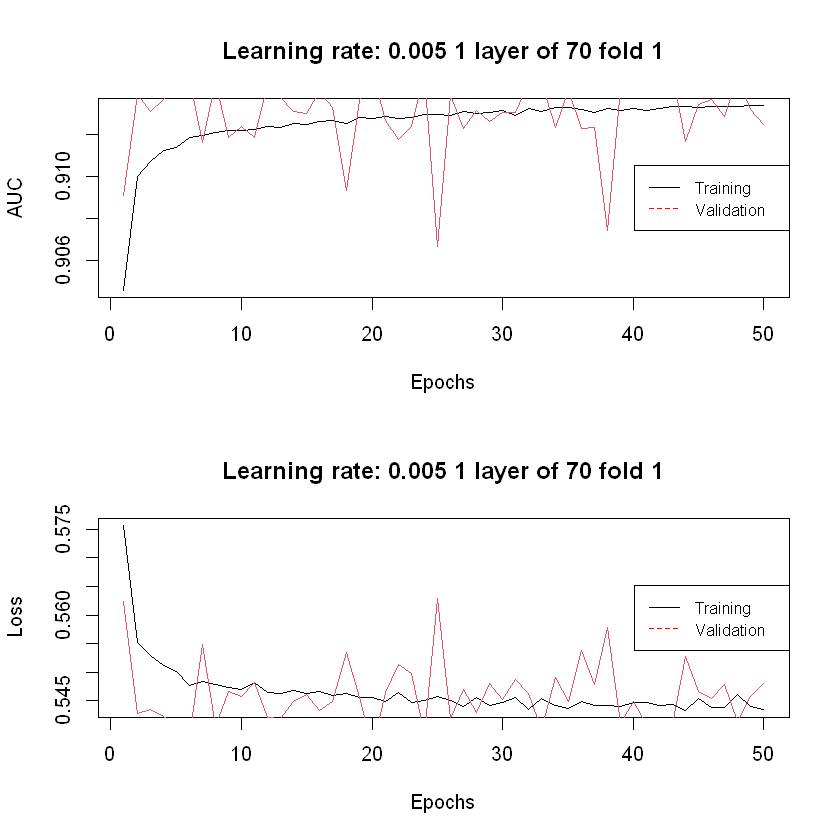

[1] "F1-Score Micro - 2 fold - Learning rate 5e-04 :  0.759432142581591"


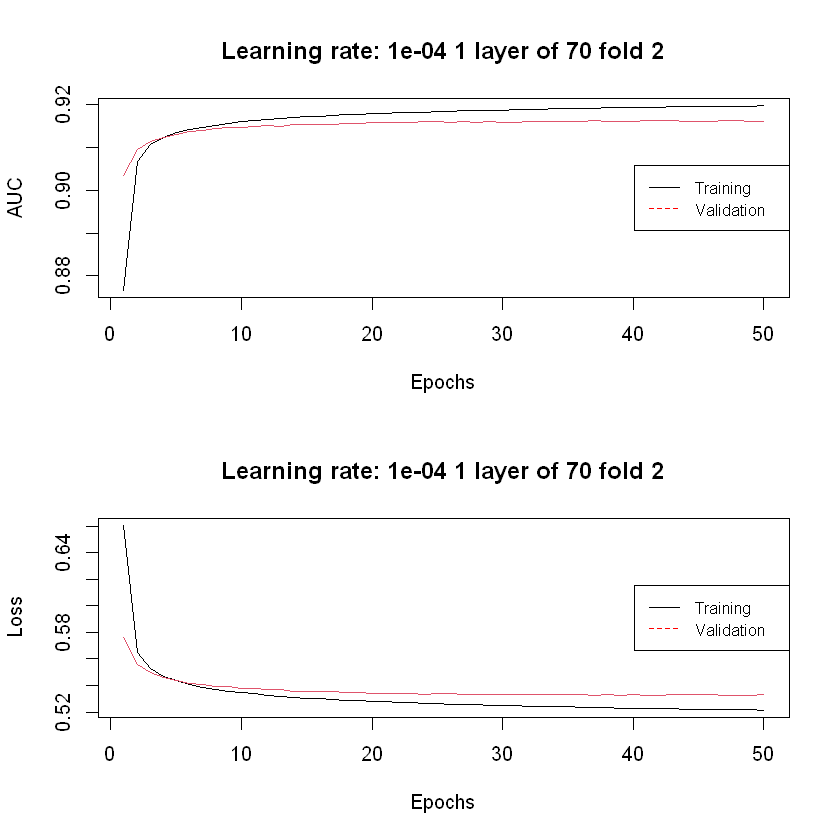

[1] "F1-Score Micro - 2 fold - Learning rate 0.001 :  0.756616001851709"


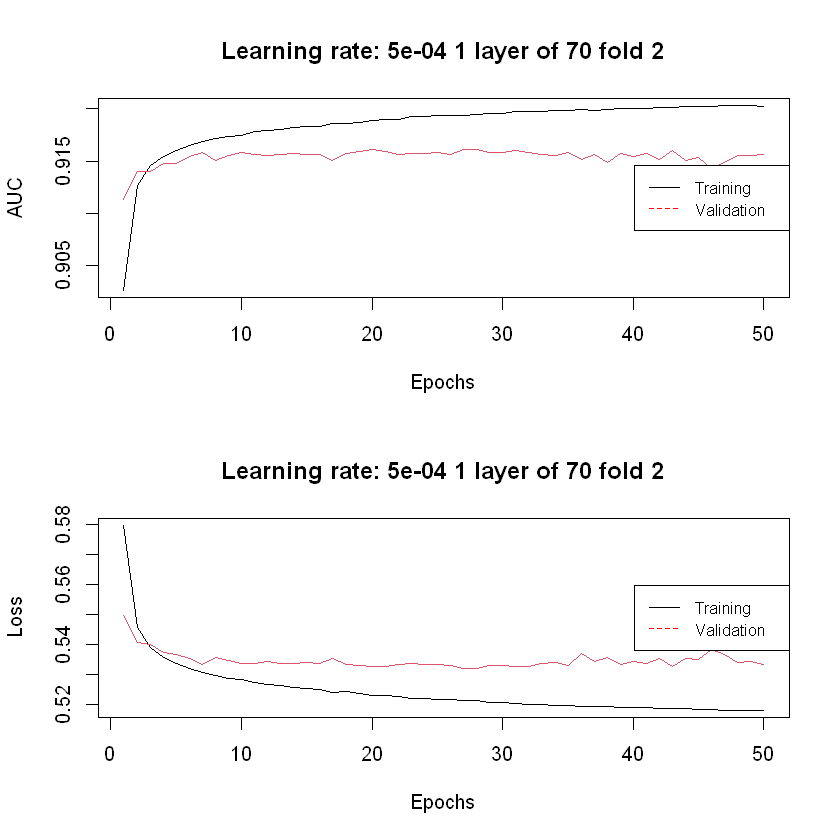

[1] "F1-Score Micro - 2 fold - Learning rate 0.005 :  0.754185633824551"
  |=====================                                                 |  30%

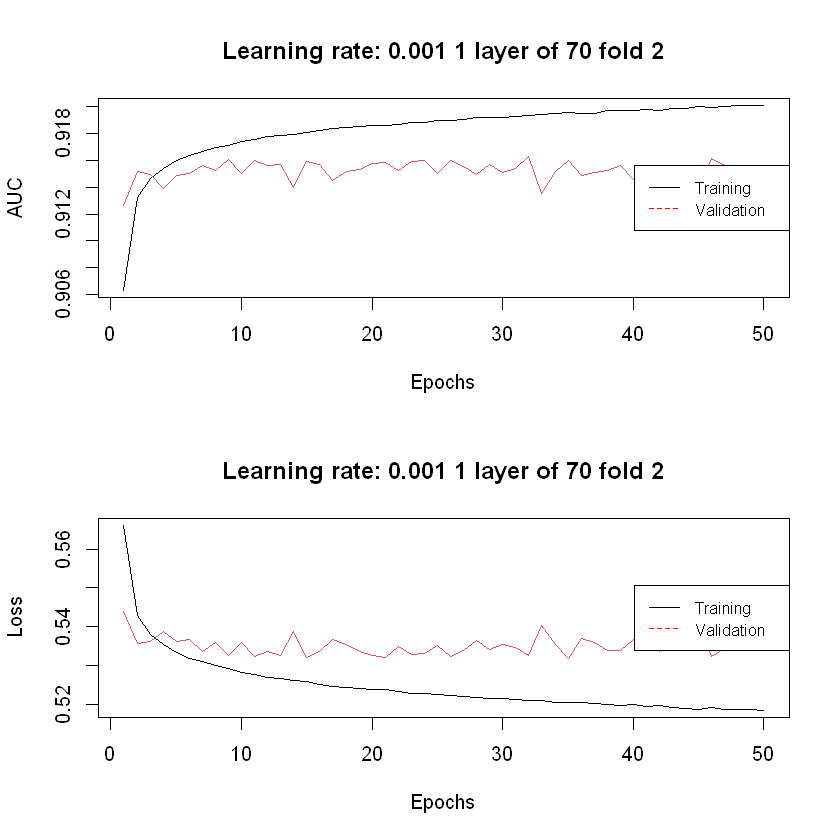

[1] "F1-Score Micro - 3 fold - Learning rate 1e-04 :  0.754147056554278"


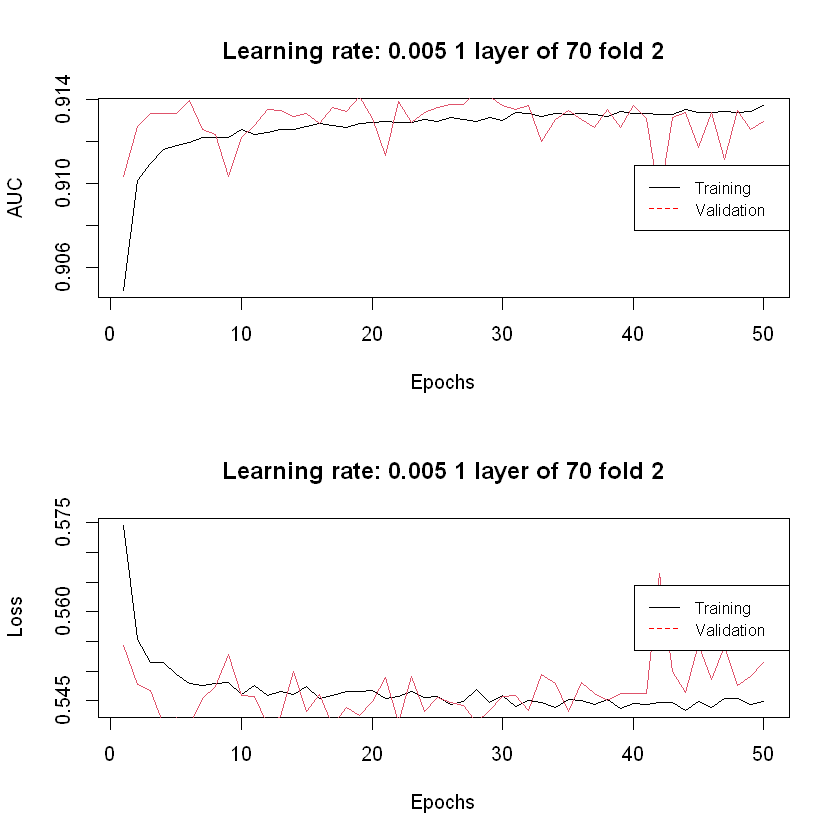

[1] "F1-Score Micro - 3 fold - Learning rate 5e-04 :  0.754841447419181"


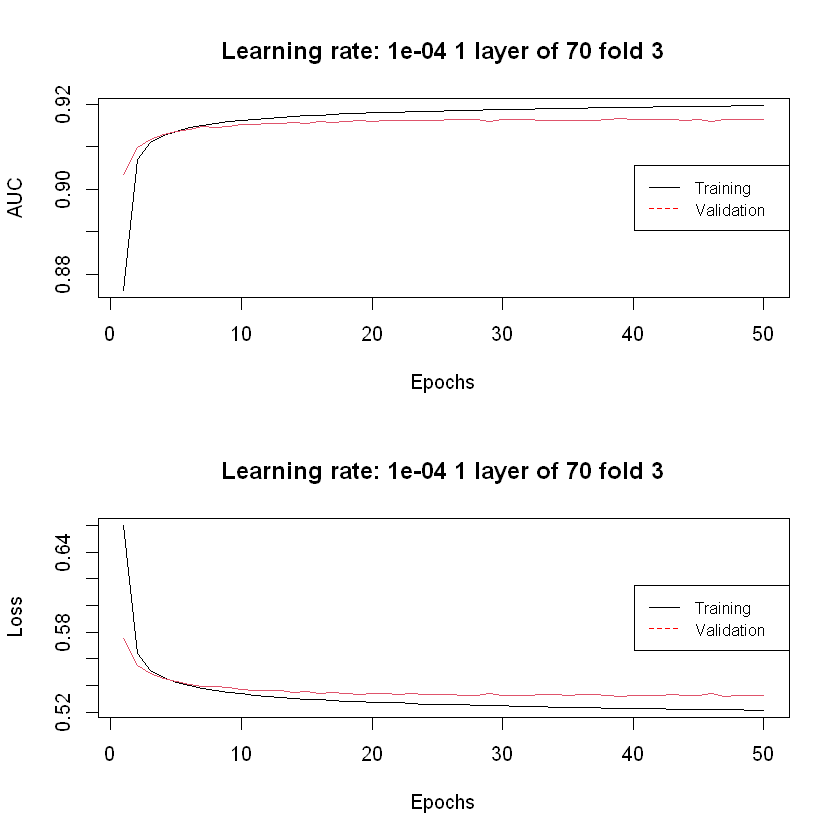

[1] "F1-Score Micro - 3 fold - Learning rate 0.001 :  0.753799861121827"


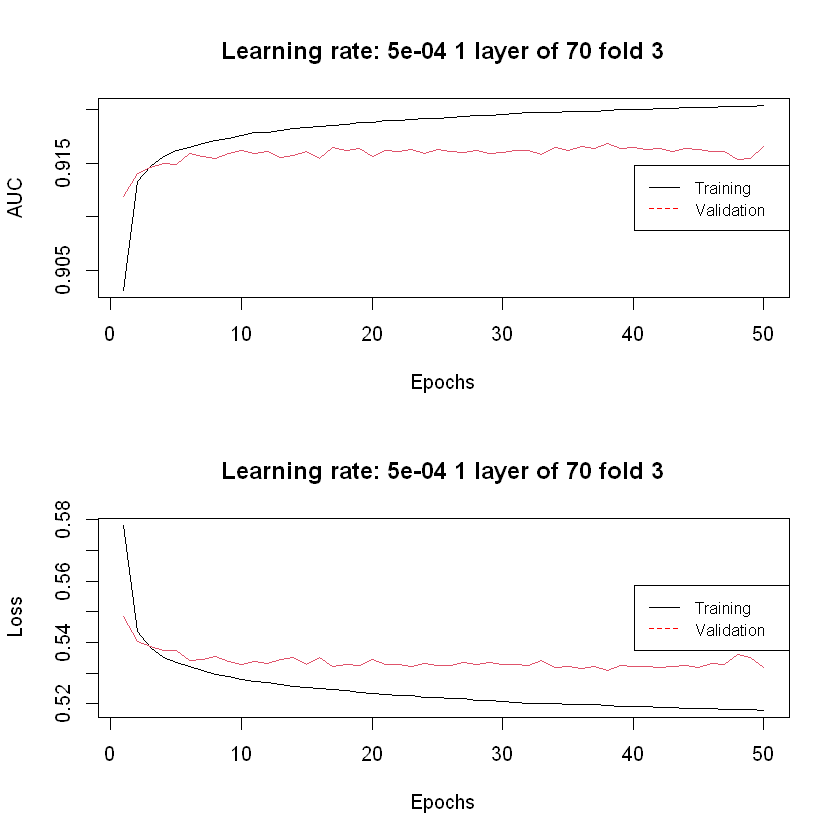

[1] "F1-Score Micro - 3 fold - Learning rate 0.005 :  0.75156237944603"
  |============================                                          |  40%

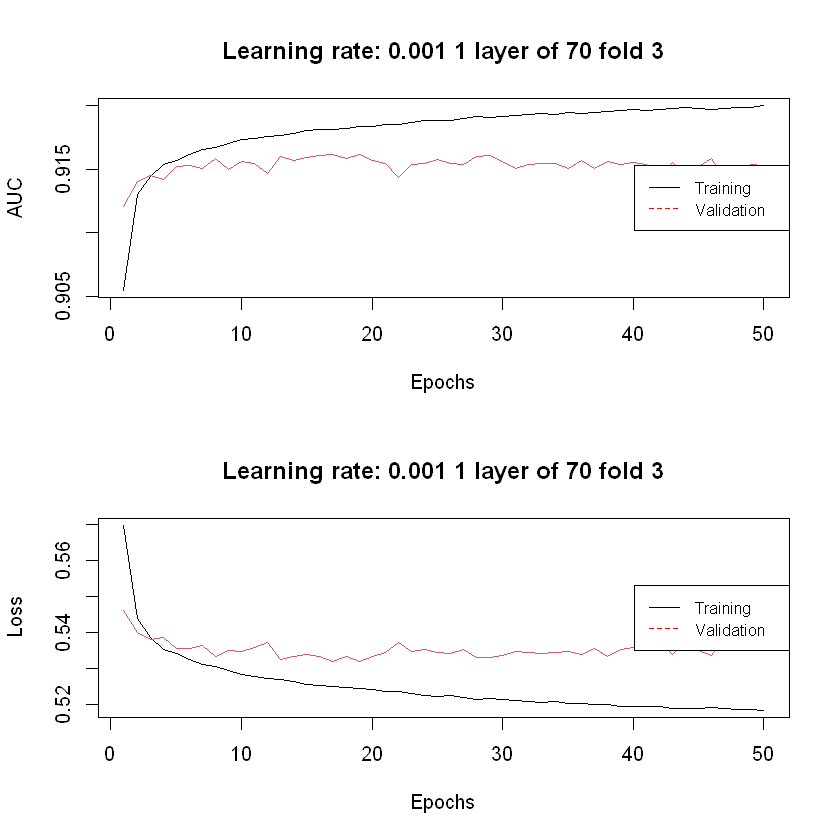

[1] "F1-Score Micro - 4 fold - Learning rate 1e-04 :  0.754764292878636"


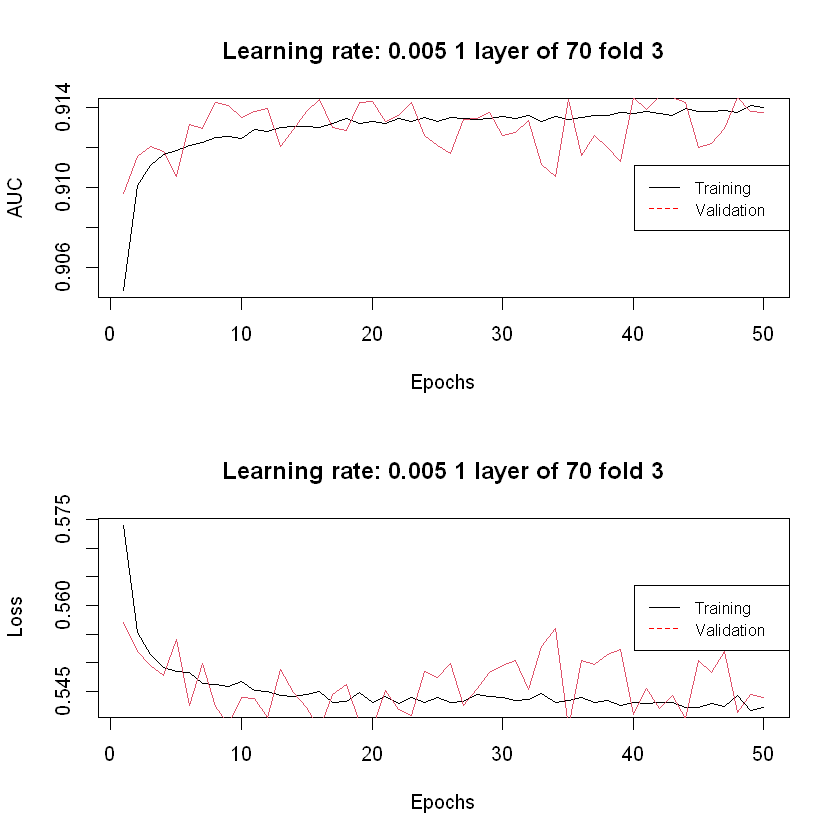

[1] "F1-Score Micro - 4 fold - Learning rate 5e-04 :  0.754687138338091"


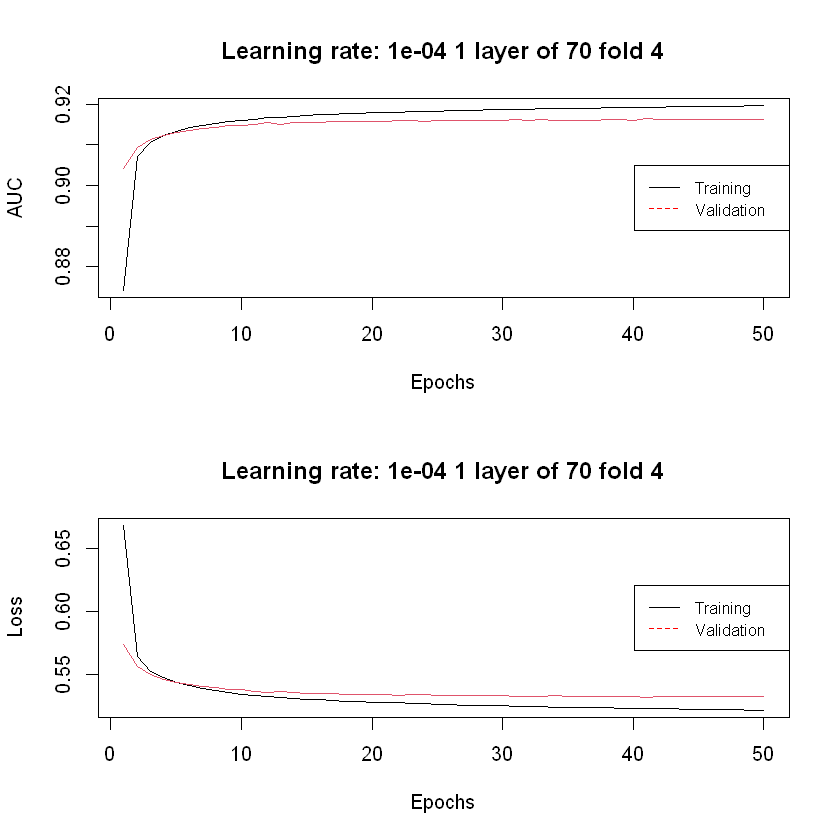

[1] "F1-Score Micro - 4 fold - Learning rate 0.001 :  0.754301365635368"


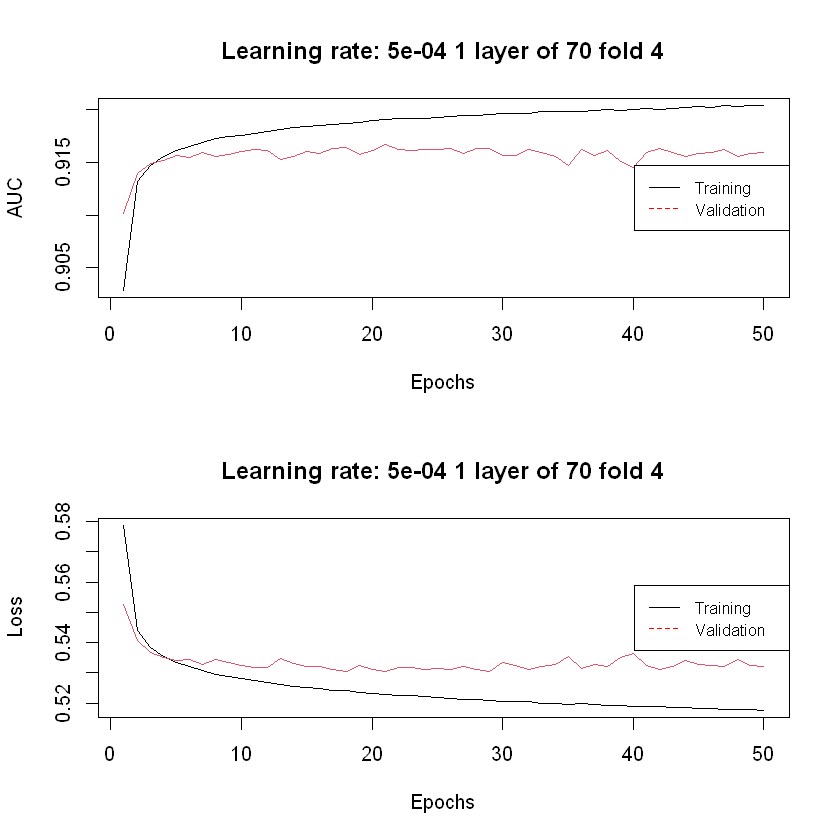

[1] "F1-Score Micro - 4 fold - Learning rate 0.005 :  0.751446647635213"
  |===================================                                   |  50%

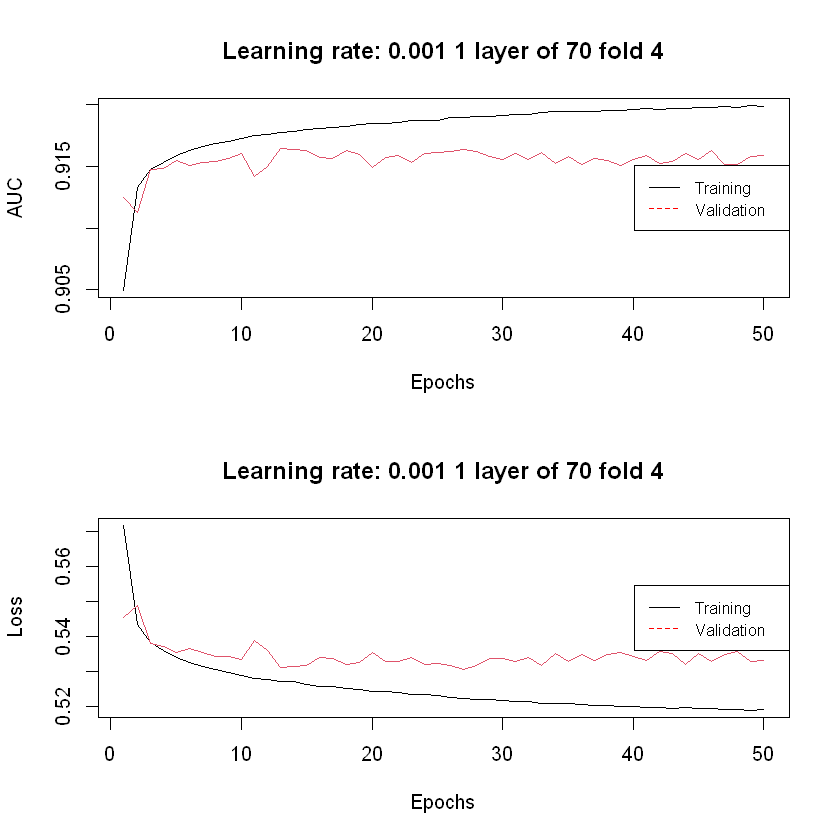

[1] "F1-Score Micro - 5 fold - Learning rate 1e-04 :  0.753375511148831"


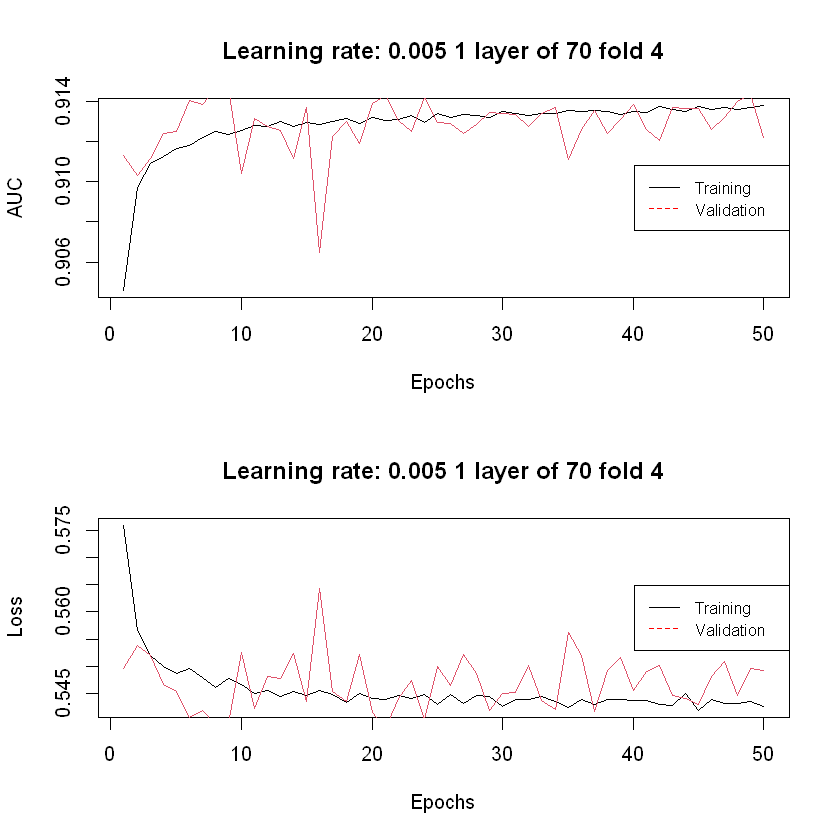

[1] "F1-Score Micro - 5 fold - Learning rate 5e-04 :  0.753144047527197"


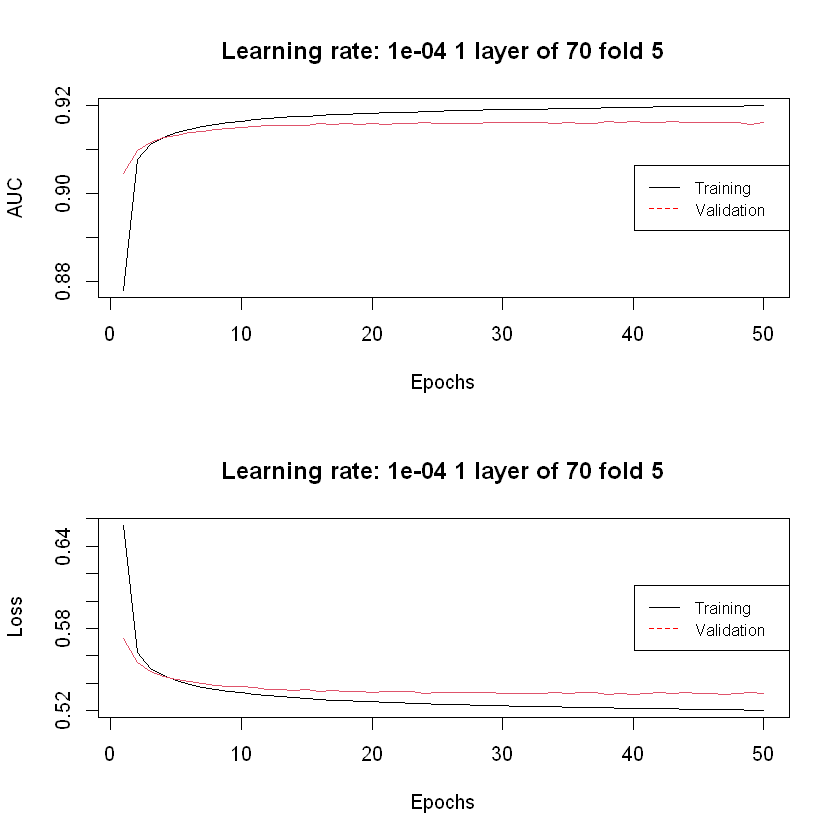

[1] "F1-Score Micro - 5 fold - Learning rate 0.001 :  0.751600956716303"


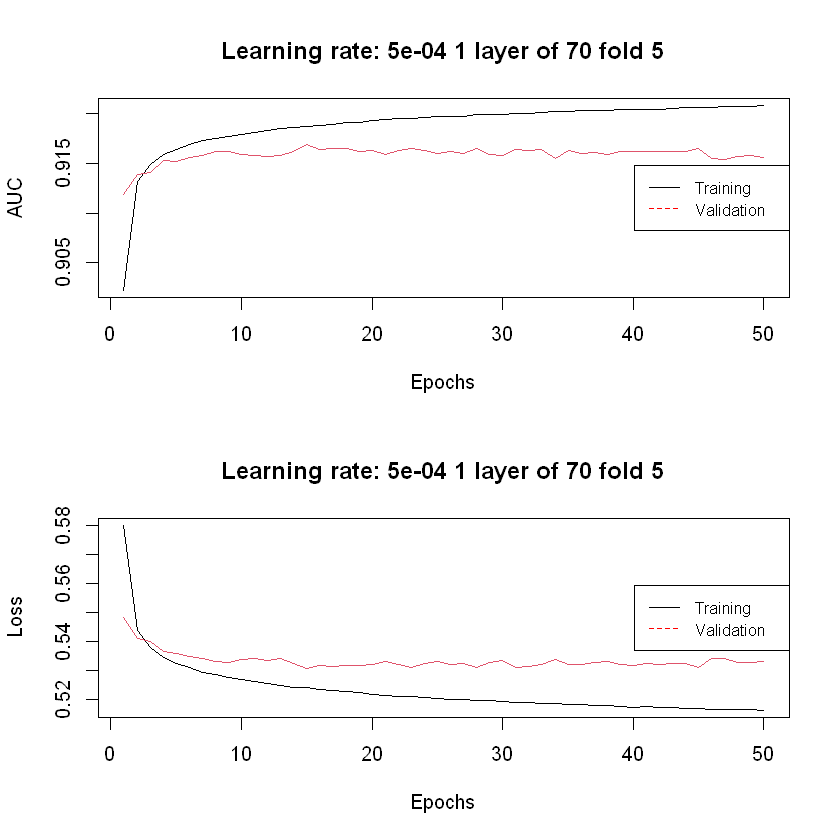

[1] "F1-Score Micro - 5 fold - Learning rate 0.005 :  0.747473188797161"
  |==========================================                            |  60%

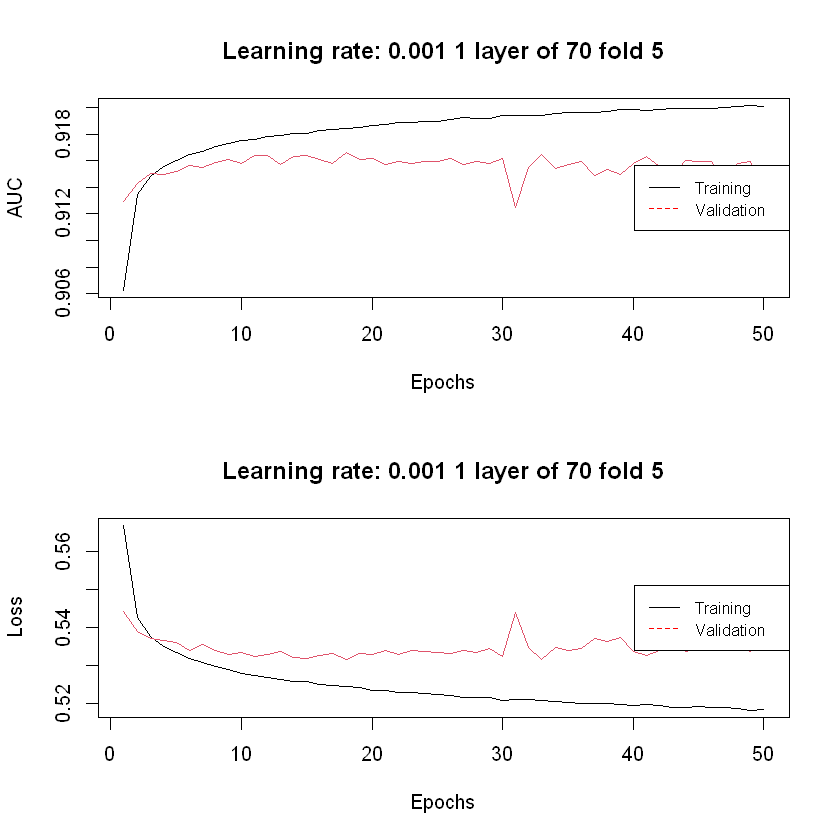

[1] "F1-Score Micro - 6 fold - Learning rate 1e-04 :  0.751523802175758"


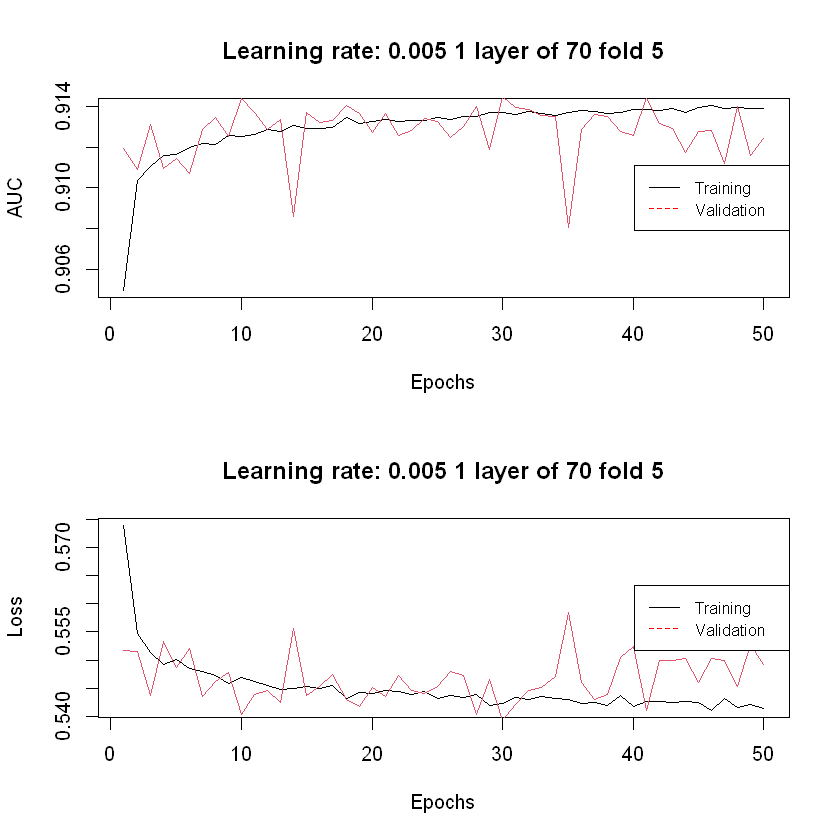

[1] "F1-Score Micro - 6 fold - Learning rate 5e-04 :  0.752256770310933"


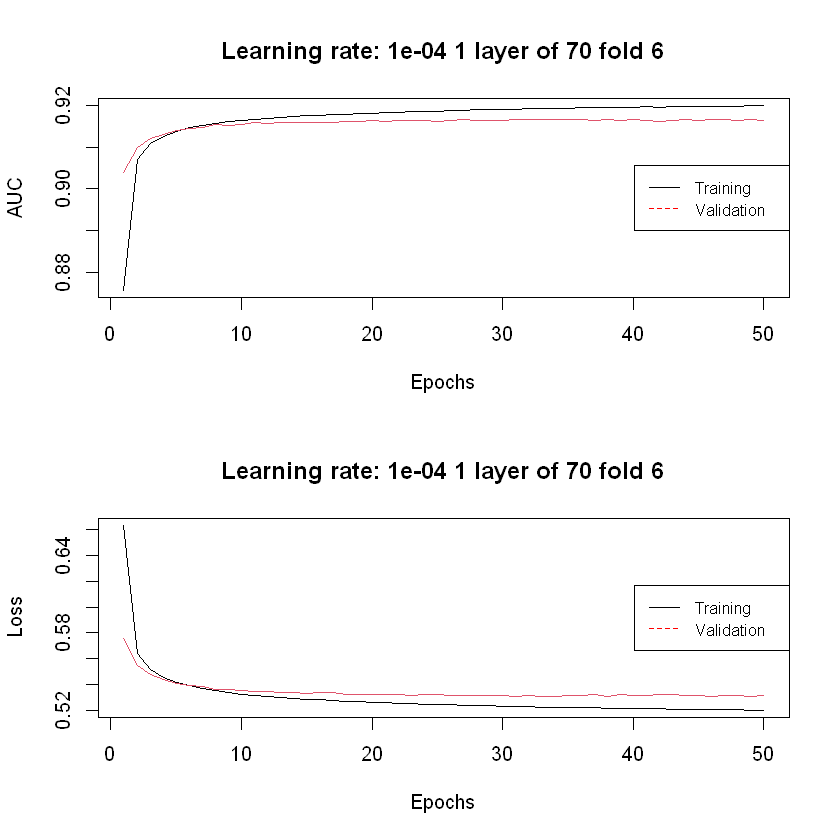

[1] "F1-Score Micro - 6 fold - Learning rate 0.001 :  0.749903556824319"


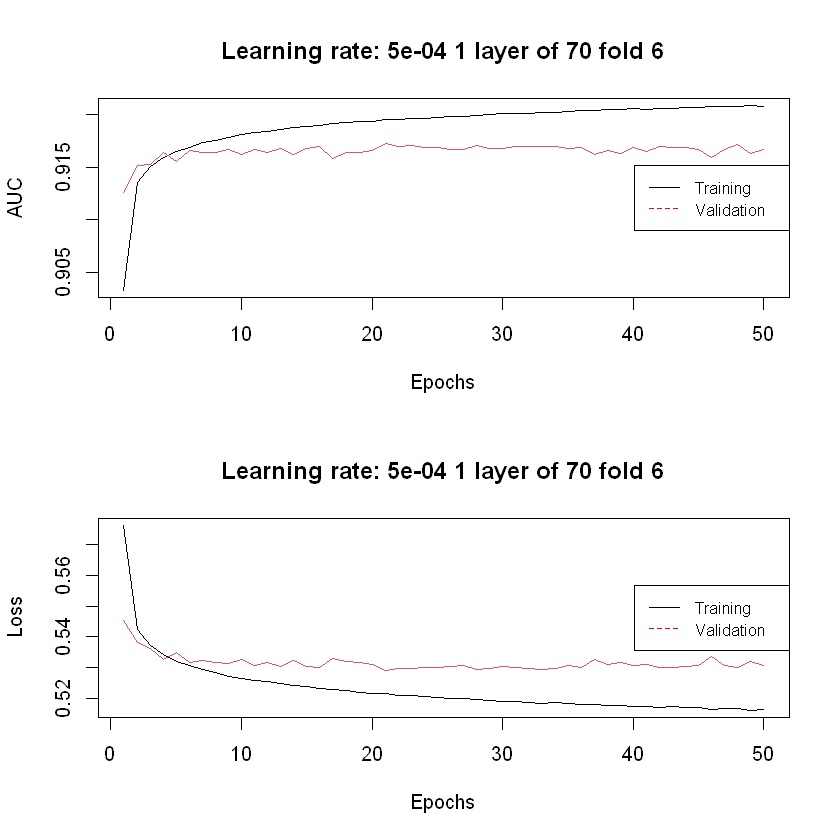

[1] "F1-Score Micro - 6 fold - Learning rate 0.005 :  0.74828331147288"
  |=================================================                     |  70%

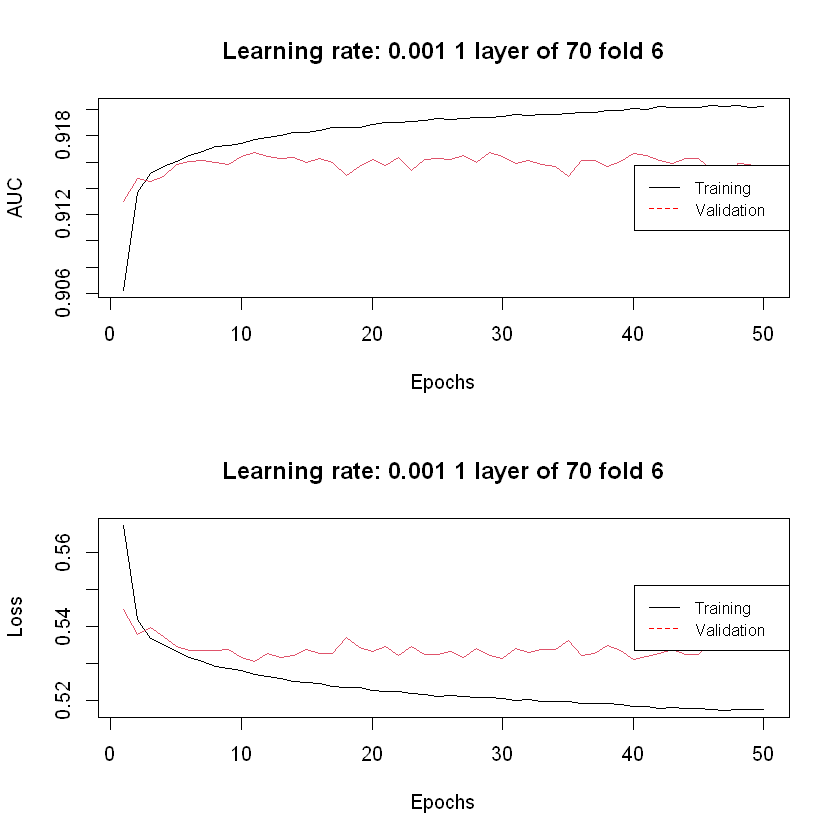

[1] "F1-Score Micro - 7 fold - Learning rate 1e-04 :  0.754147056554278"


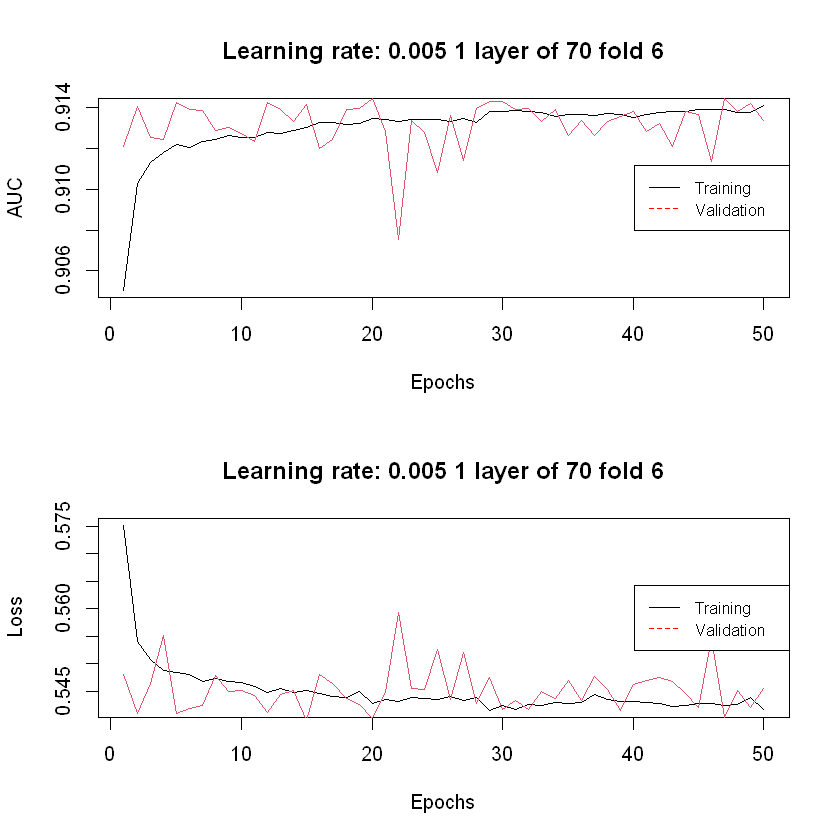

[1] "F1-Score Micro - 7 fold - Learning rate 5e-04 :  0.755034333770542"


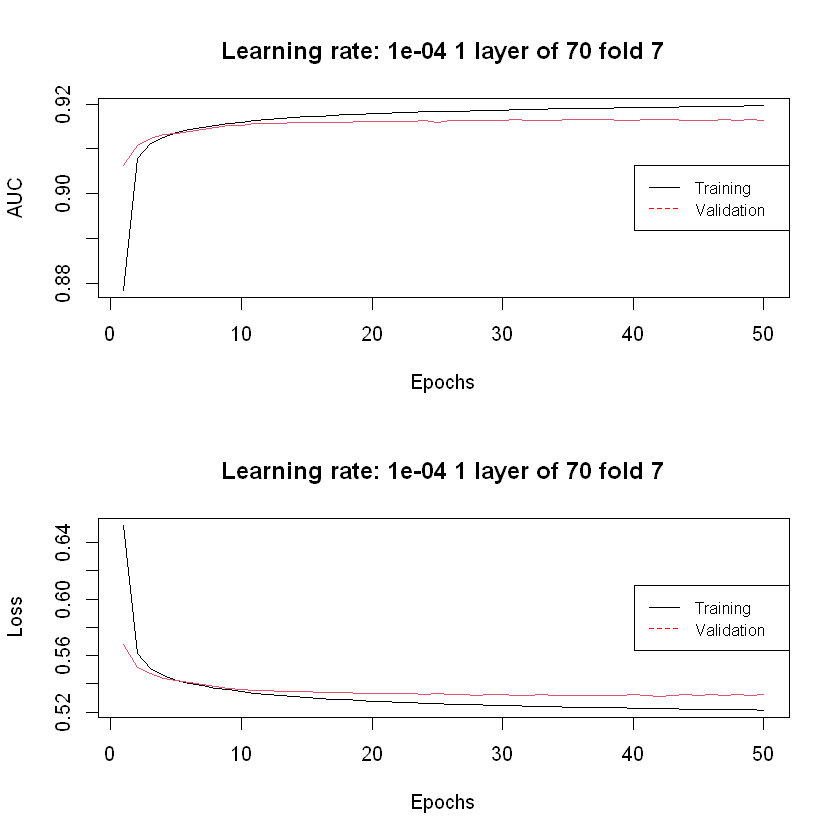

[1] "F1-Score Micro - 7 fold - Learning rate 0.001 :  0.753645552040738"


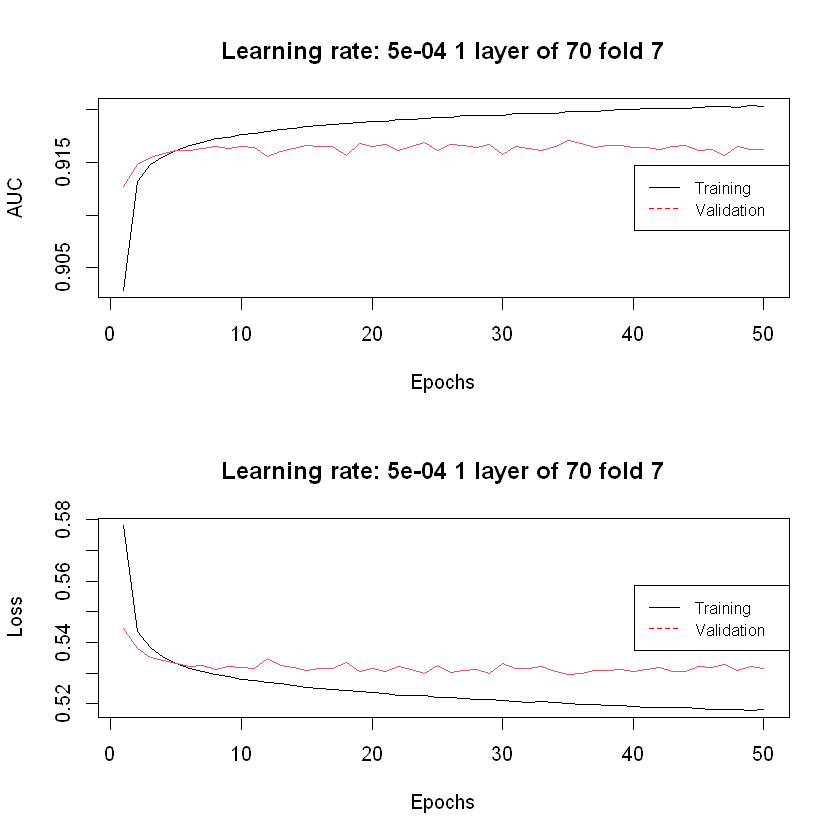

[1] "F1-Score Micro - 7 fold - Learning rate 0.005 :  0.751678111256847"
  |========================================================              |  80%

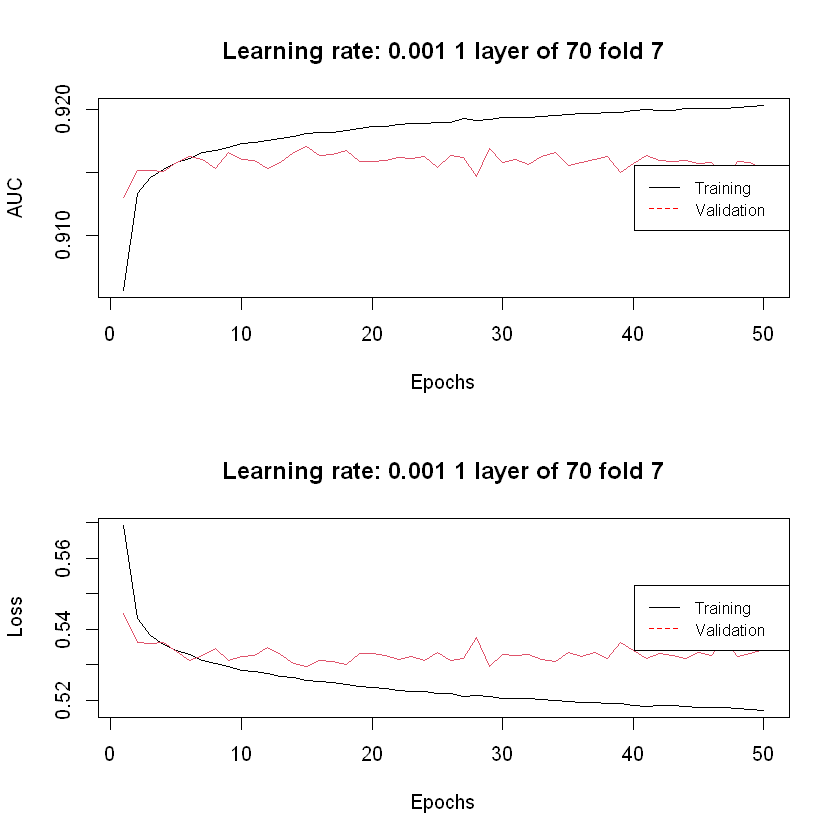

[1] "F1-Score Micro - 8 fold - Learning rate 1e-04 :  0.757657588149063"


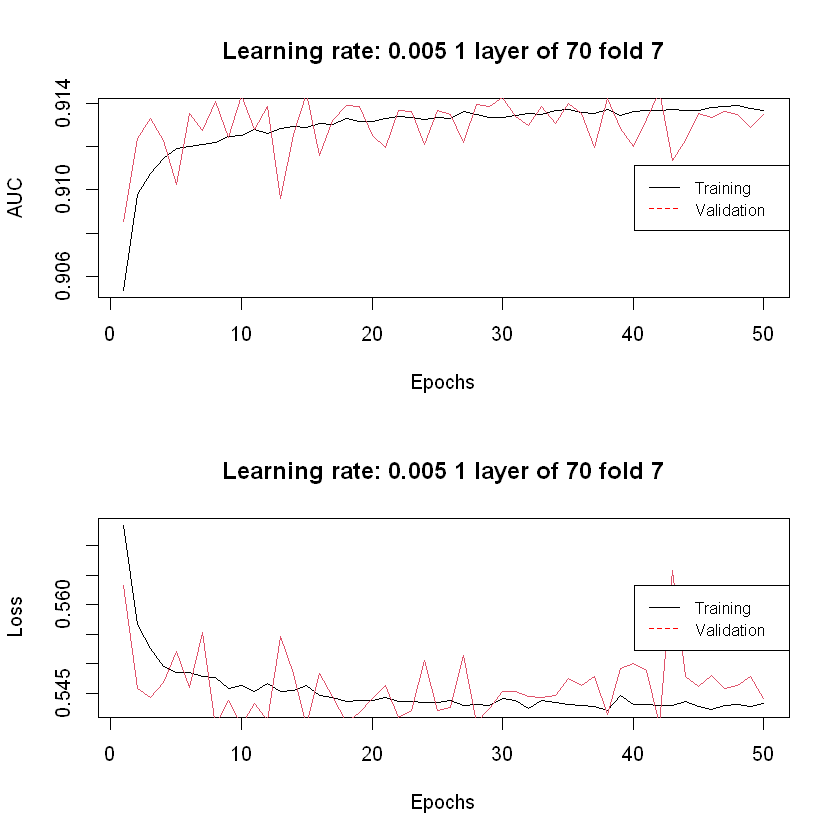

[1] "F1-Score Micro - 8 fold - Learning rate 5e-04 :  0.757078929094977"


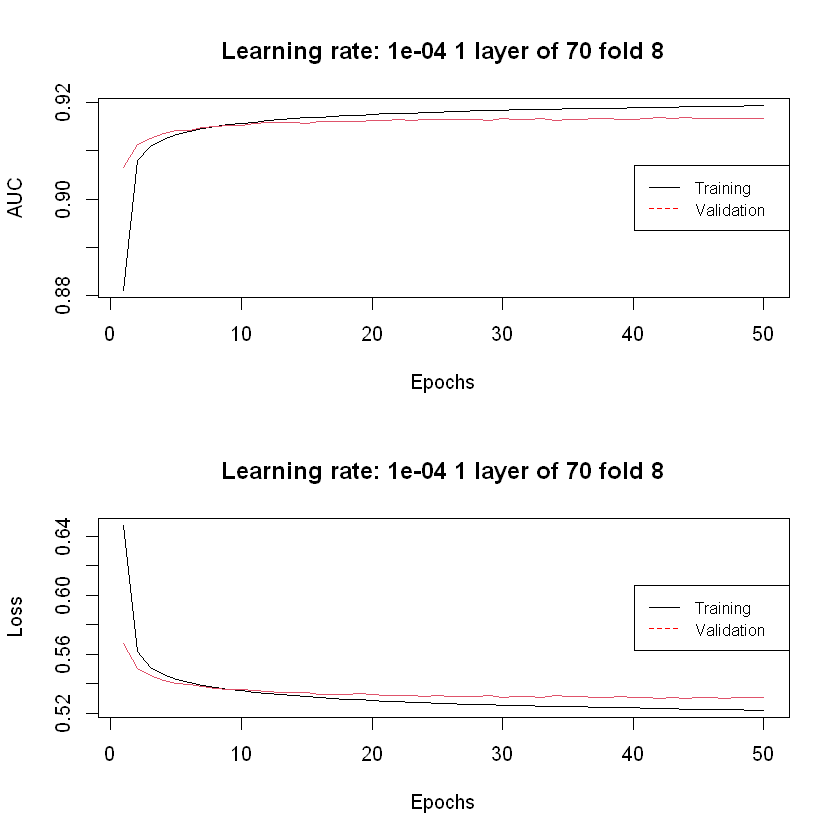

[1] "F1-Score Micro - 8 fold - Learning rate 0.001 :  0.754494251986729"


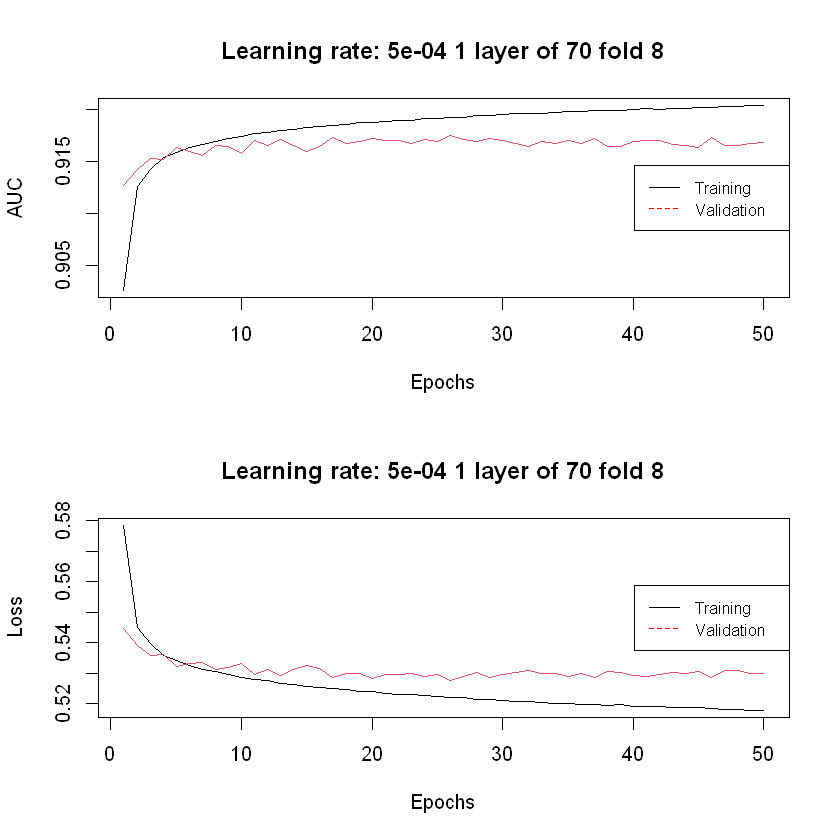

[1] "F1-Score Micro - 8 fold - Learning rate 0.005 :  0.755921610986807"
  |===============================================================       |  90%

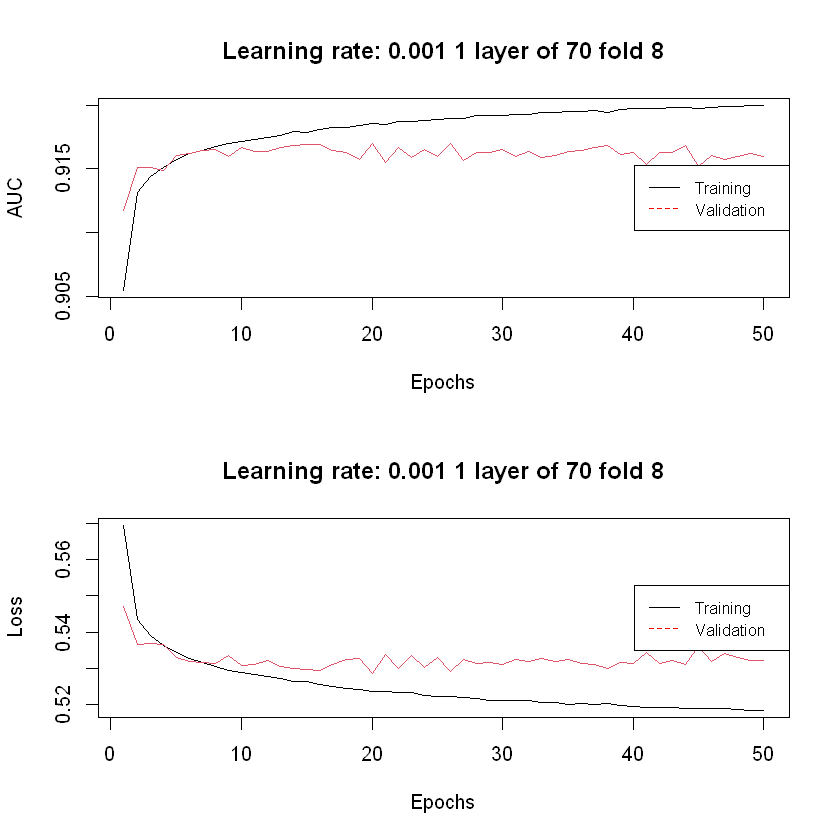

[1] "F1-Score Micro - 9 fold - Learning rate 1e-04 :  0.756616001851709"


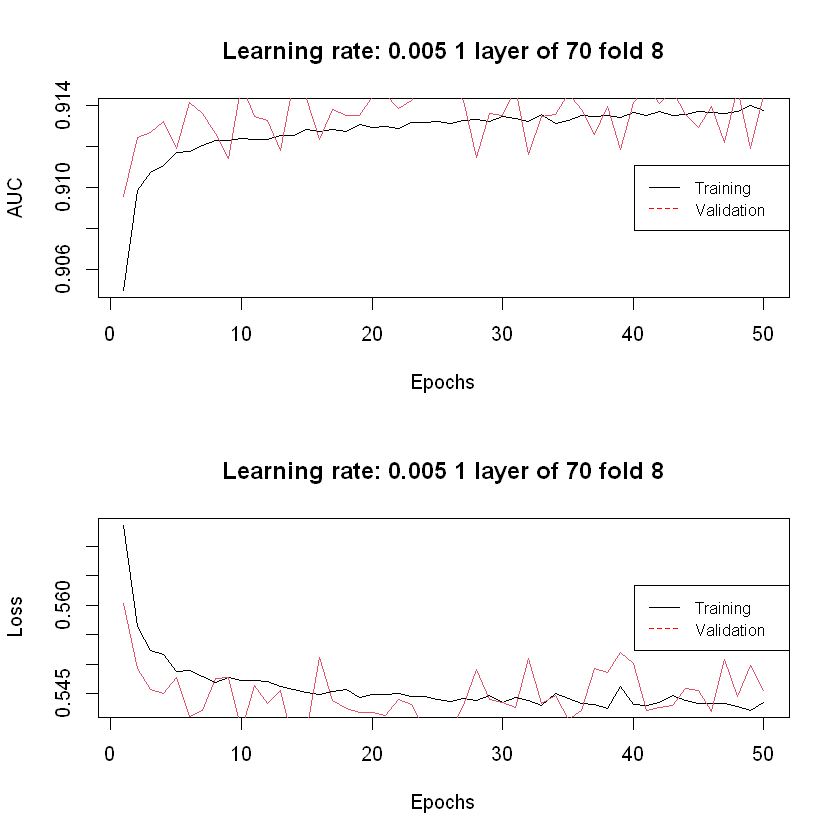

[1] "F1-Score Micro - 9 fold - Learning rate 5e-04 :  0.757040351824705"


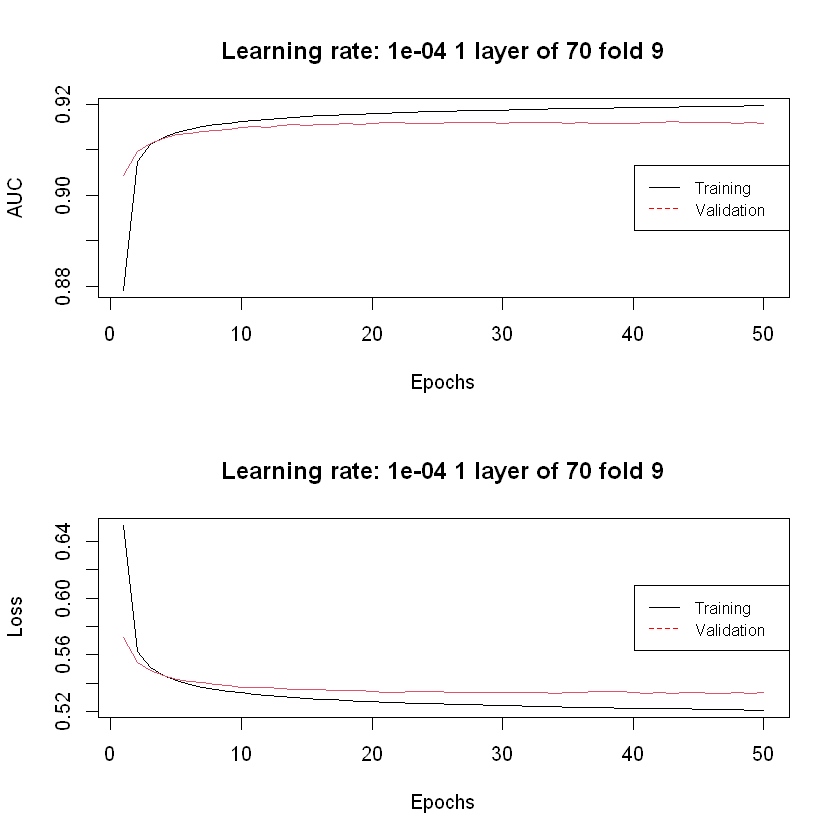

[1] "F1-Score Micro - 9 fold - Learning rate 0.001 :  0.754609983797546"


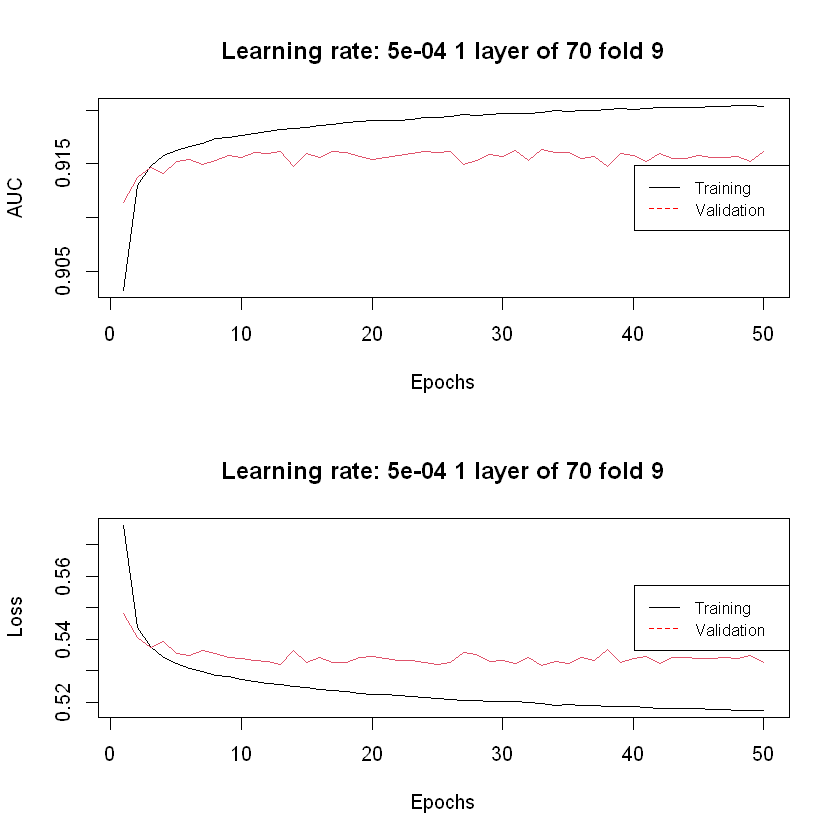

[1] "F1-Score Micro - 9 fold - Learning rate 0.005 :  0.750752256770311"
  |======================================================================| 100%

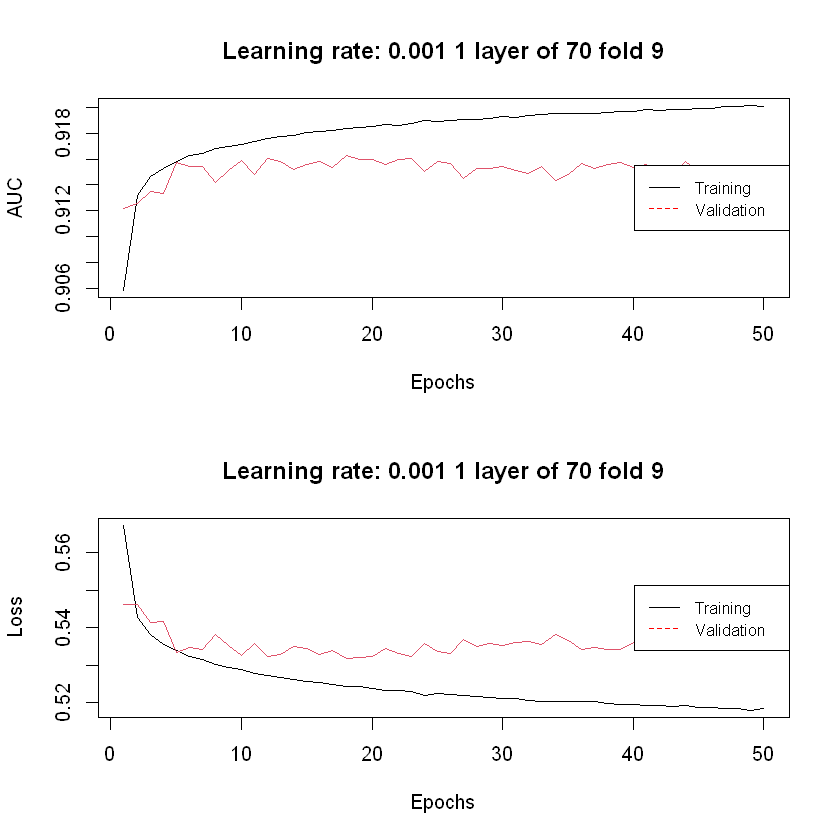

[1] "F1-Score Micro - 10 fold - Learning rate 1e-04 :  0.757766372091228"


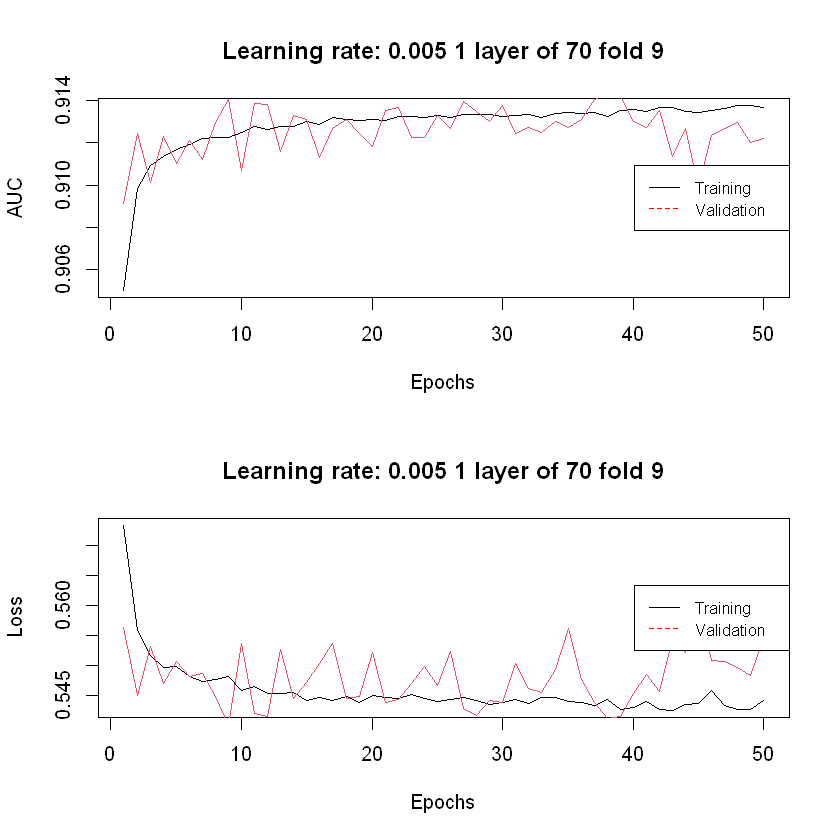

[1] "F1-Score Micro - 10 fold - Learning rate 5e-04 :  0.753907305213599"


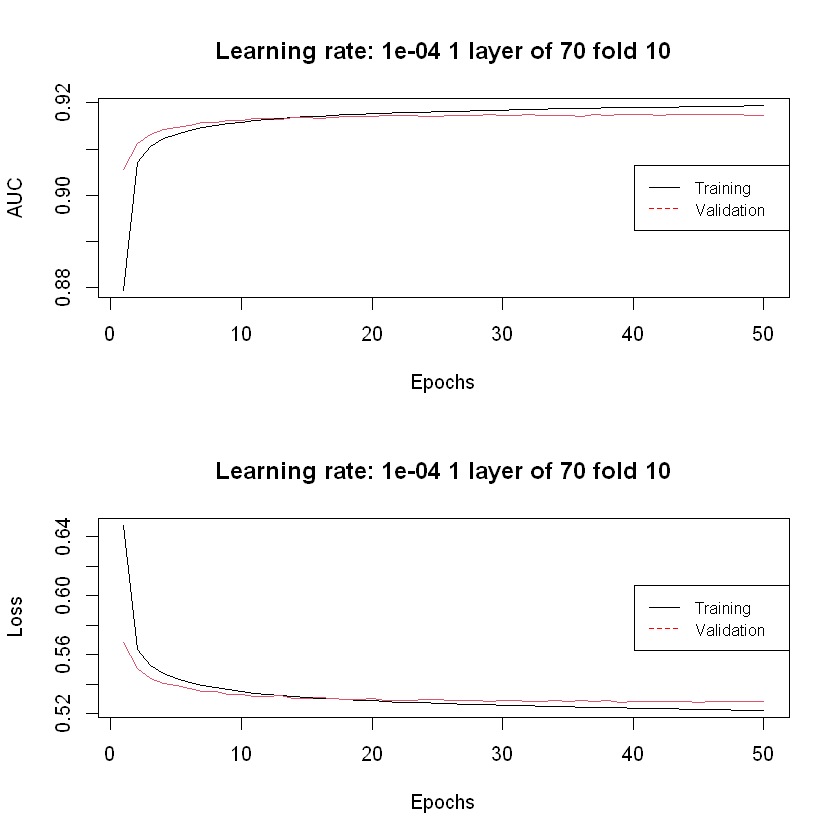

[1] "F1-Score Micro - 10 fold - Learning rate 0.001 :  0.754370393238915"


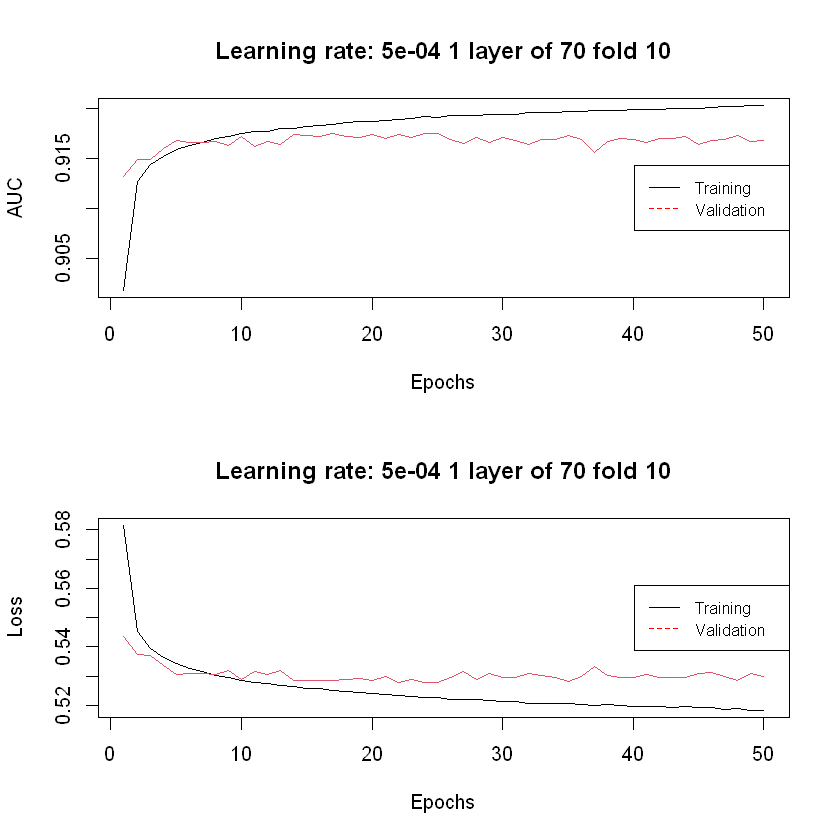

[1] "F1-Score Micro - 10 fold - Learning rate 0.005 :  0.751939181106009"


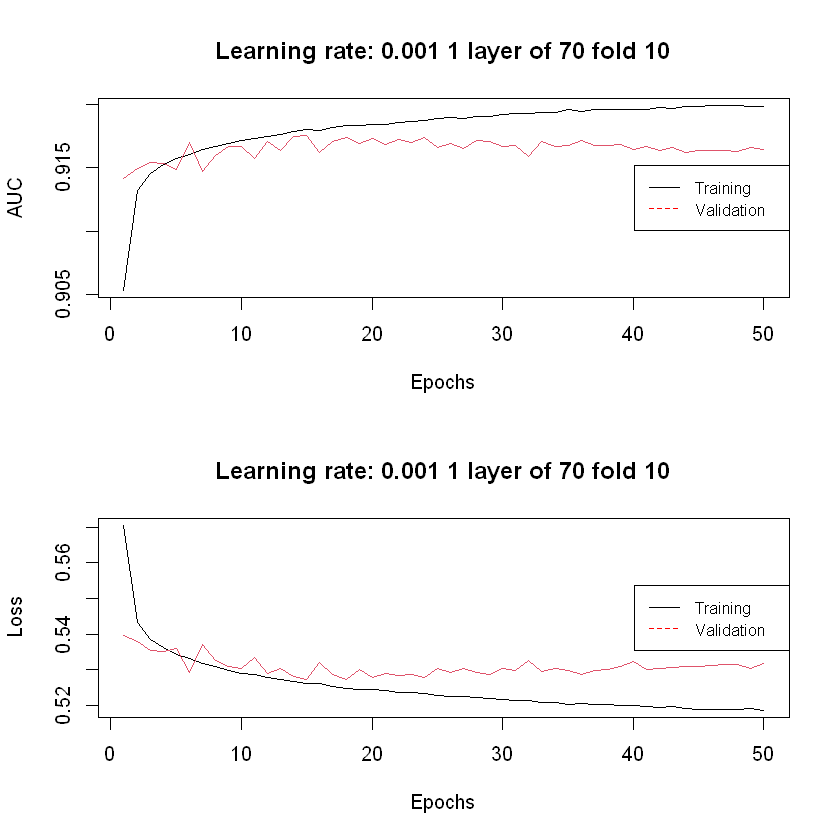

,fold,learning_rate,F1
,<dbl>,<dbl>,<dbl>
1,1,1e-04,0.7569246
2,1,5e-04,0.7576962
3,1,1e-03,0.7561531
4,1,5e-03,0.7516395
5,2,1e-04,0.7584291
6,2,5e-04,0.7594321
7,2,1e-03,0.7566160
8,2,5e-03,0.7541856
9,3,1e-04,0.7541471


,learning_rate,mean F1
,<dbl>,<dbl>
1,1e-04,0.7555351
2,5e-04,0.7555119
3,1e-03,0.7539495
4,5e-03,0.7514882


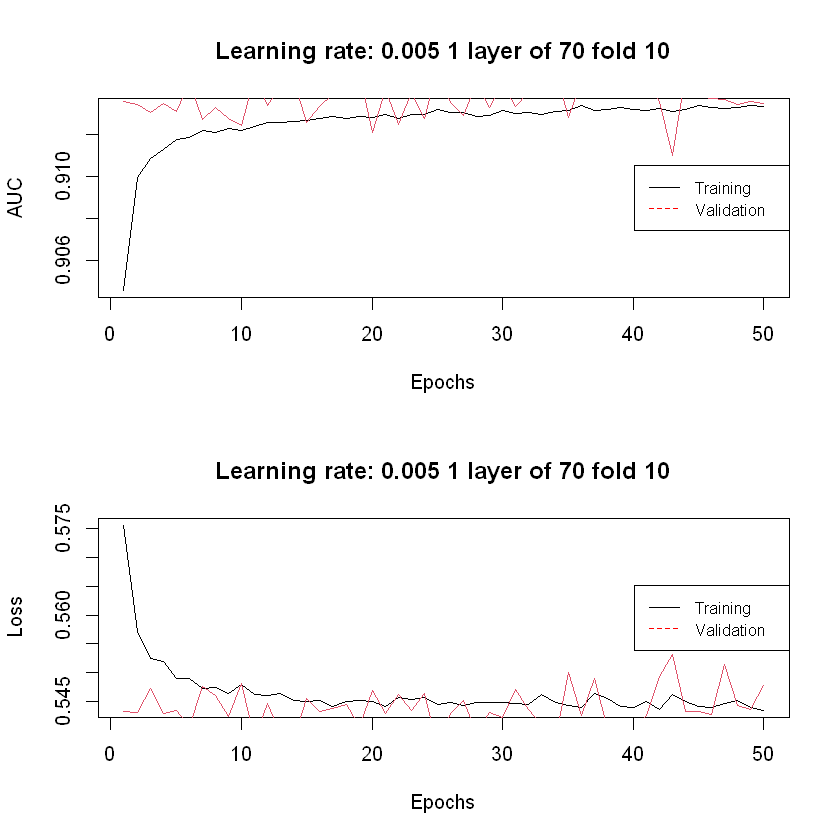

In [13]:
set.seed(2)
k = 10

accuracy_vec2 <- data.frame(matrix(ncol = 3, nrow = 0))
colnames(accuracy_vec2)<-c('fold','learning_rate','F1')

# 1. Shuffle the dataset randomly.
dataNN_idx <- sample(1:nrows)

# 2. Split the dataset into k groups
max <- ceiling(nrows/k)
splits <- split(dataNN_idx, ceiling(seq_along(dataNN_idx)/max))

pb <- txtProgressBar(min = 0, max = k, style = 3)
# 3. For each unique group:
for (i in 1:k){
    for (j in c(0.0001,0.0005,0.001,0.005)){
        
        neuralmodel <- keras_model_sequential() %>% 
        normalizer  %>% 
        layer_dense(70, activation = 'relu') %>%
        layer_dense(3,activation='softmax')

        neuralmodel %>% compile(
            loss = 'categorical_crossentropy',
            optimizer = optimizer_adam(j),
            metrics=c('AUC')
        )
        #3.1 Take the group as a hold out or test data set
        test_data <- dataNN[splits[[i]],]

        #3.2 Take the remaining groups as a training data set
        train_data <- dataNN[-splits[[i]],]   

        model_history <- neuralmodel %>% fit(
        as.matrix(train_data[,-target_variables]),
        as.matrix(train_data[,target_variables]),
        validation_split = 0.2,
        verbose = 0,
        epochs = 50
        )

        yhat <- predict(neuralmodel, as.matrix(test_data[-target_variables]))

        yhaty <- classConverter(yhat,test_data)
        accuracy_vec2[nrow(accuracy_vec2)+1,]<-c(i,j,F1_Score_micro(yhaty[[2]][,],yhaty[[1]][,]))
        setTxtProgressBar(pb, i)
        print(paste("F1-Score Micro -",i,"fold -",'Learning rate',j,': ',accuracy_vec2[nrow(accuracy_vec2),3]))
        par(mfrow=c(2,1)) 
        plot(1:model_history$params$epochs,model_history$metrics$auc, type='l',xlab="Epochs",ylab='AUC',main=paste('Learning rate:',j, '1 layer of 70','fold',i),col=1)
        lines(1:model_history$params$epochs,model_history$metrics$val_auc, type='l',ylab='AUC',col=2)
        legend(x='right', legend=c("Training", "Validation"),col=c("black", "red"), lty=1:2, cex=0.8)
        plot(1:model_history$params$epochs,model_history$metrics$loss, type='l',xlab="Epochs",ylab='Loss',main=paste('Learning rate:',j, '1 layer of 70','fold',i),col=1)
        lines(1:model_history$params$epochs,model_history$metrics$val_loss, type='l',ylab='Loss',col=2)
        legend(x='right', legend=c("Training", "Validation"),col=c("black", "red"), lty=1:2, cex=0.8)
        rm('neuralmodel','model_history')
    }
}

#4. Summarize the accuracy of the model using the sample of model evaluation scores
meanF1_2 <- data.frame(matrix(ncol = 2, nrow = 0))
colnames(meanF1_2)<-c('learning_rate','mean F1')
for (i in c(0.0001,0.0005,0.001,0.005)){
    meanF1_2[nrow(meanF1_2)+1,]<-c(i,mean(filter(accuracy_vec2,(learning_rate==i))$F1))
}

accuracy_vec2
meanF1_2

#425 min

  |=======                                                               |  10%[1] "F1-Score Micro - 1 fold - Learning rate 1e-04 :  0.757194660905794"
[1] "F1-Score Micro - 1 fold - Learning rate 5e-04 :  0.753066892986652"
  |==============                                                        |  20%

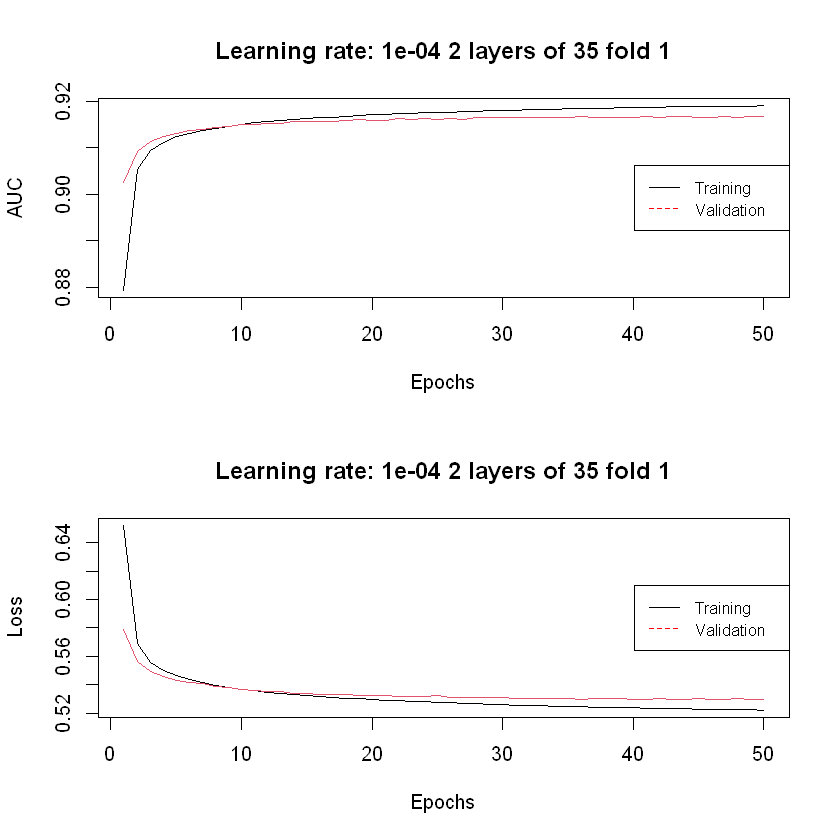

[1] "F1-Score Micro - 2 fold - Learning rate 1e-04 :  0.760589460689762"


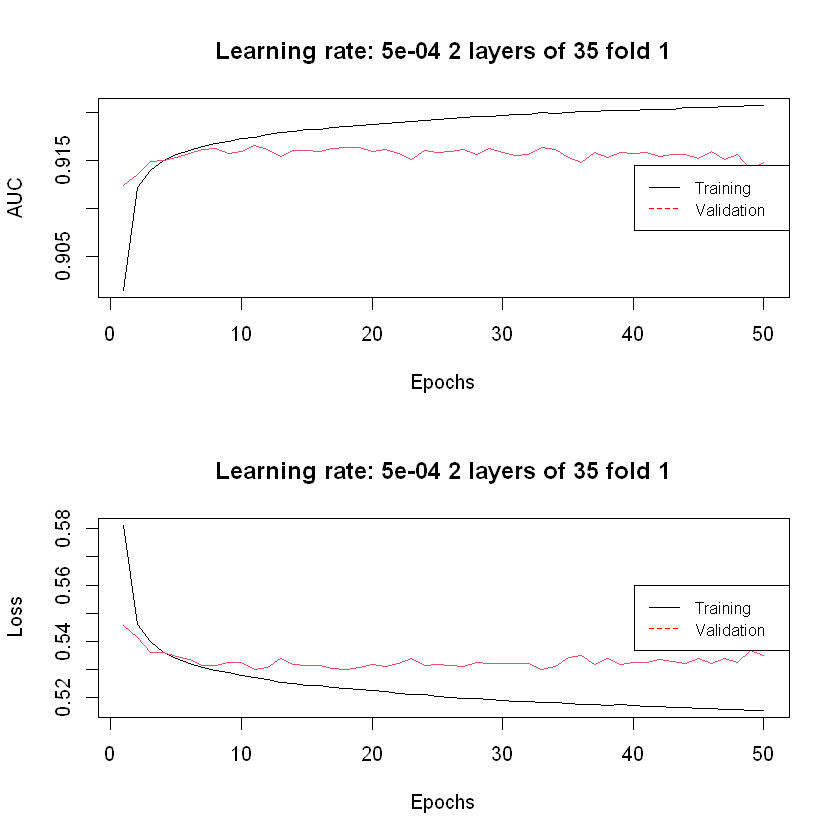

[1] "F1-Score Micro - 2 fold - Learning rate 5e-04 :  0.756847465473343"
  |=====================                                                 |  30%

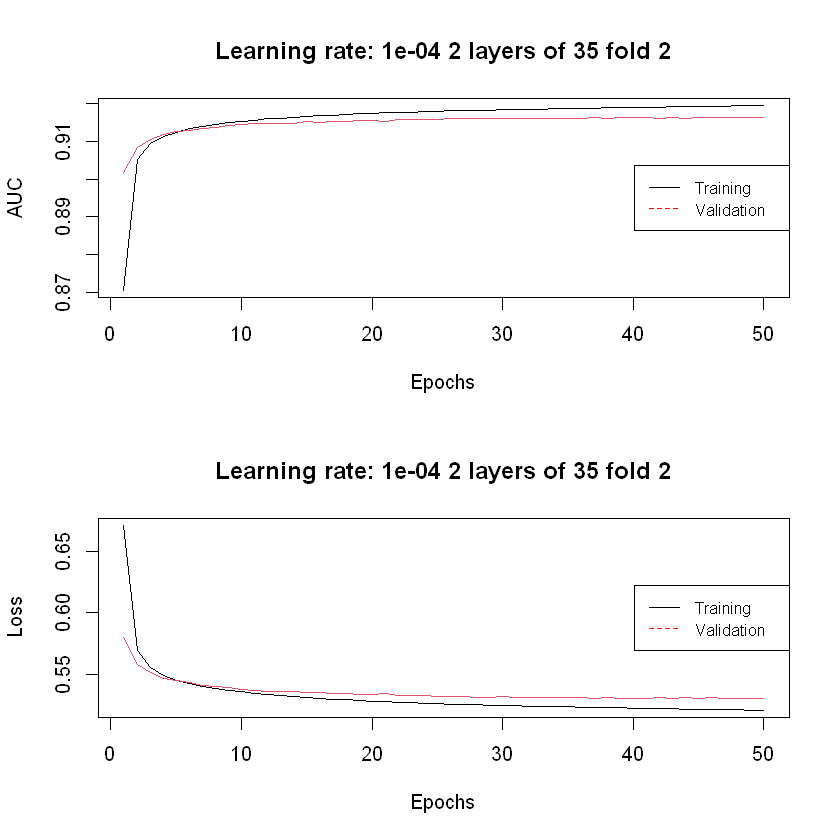

[1] "F1-Score Micro - 3 fold - Learning rate 1e-04 :  0.754378520175912"


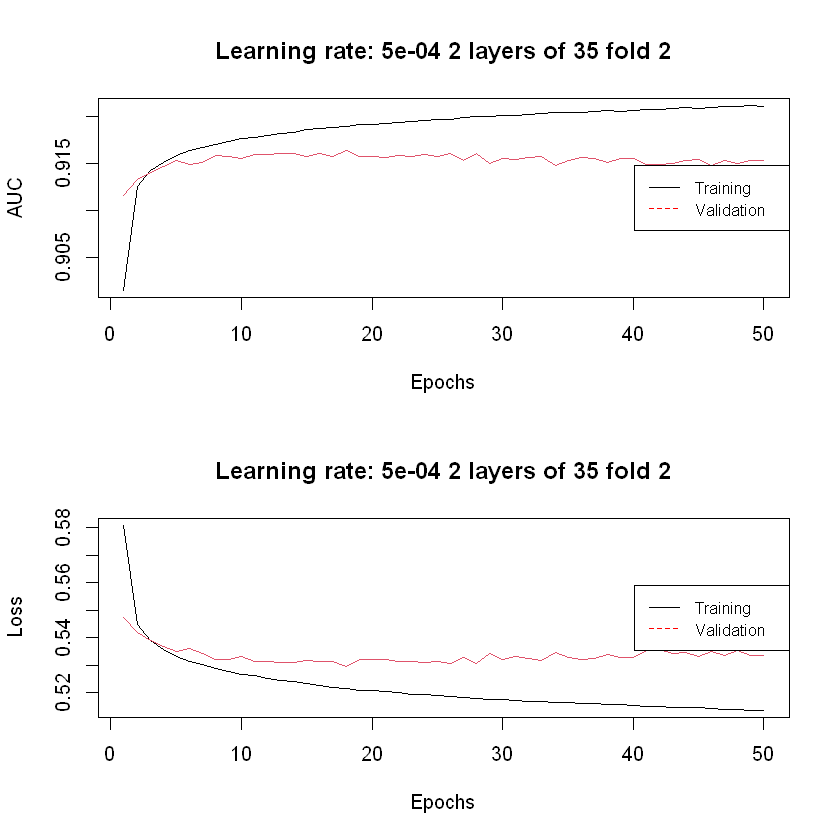

[1] "F1-Score Micro - 3 fold - Learning rate 5e-04 :  0.753877015662372"
  |============================                                          |  40%

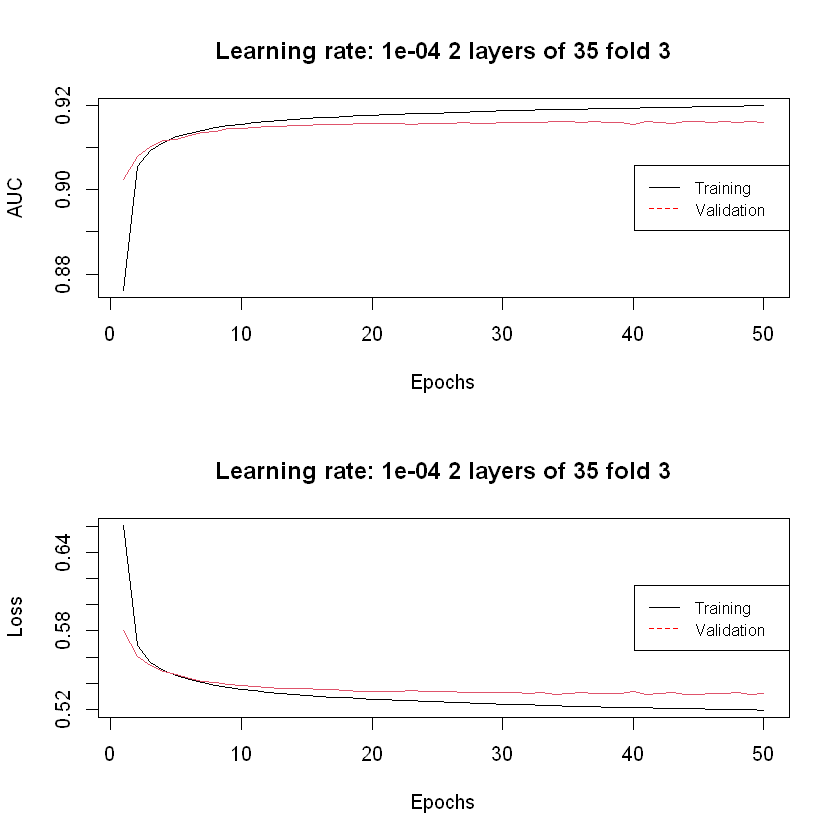

[1] "F1-Score Micro - 4 fold - Learning rate 1e-04 :  0.756538847311164"


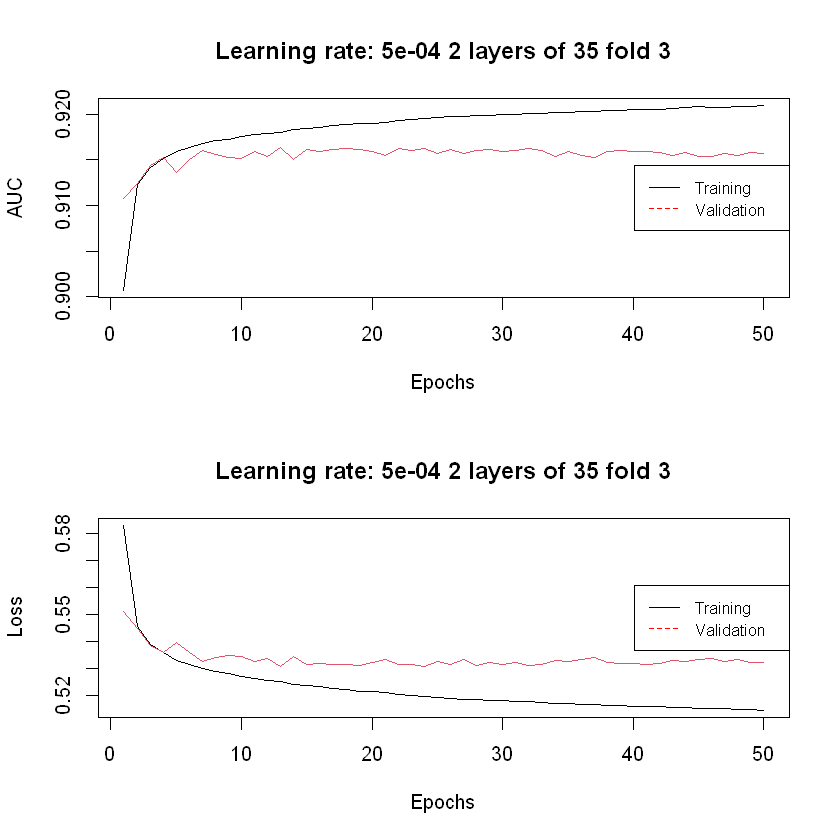

[1] "F1-Score Micro - 4 fold - Learning rate 5e-04 :  0.753568397500193"
  |===================================                                   |  50%

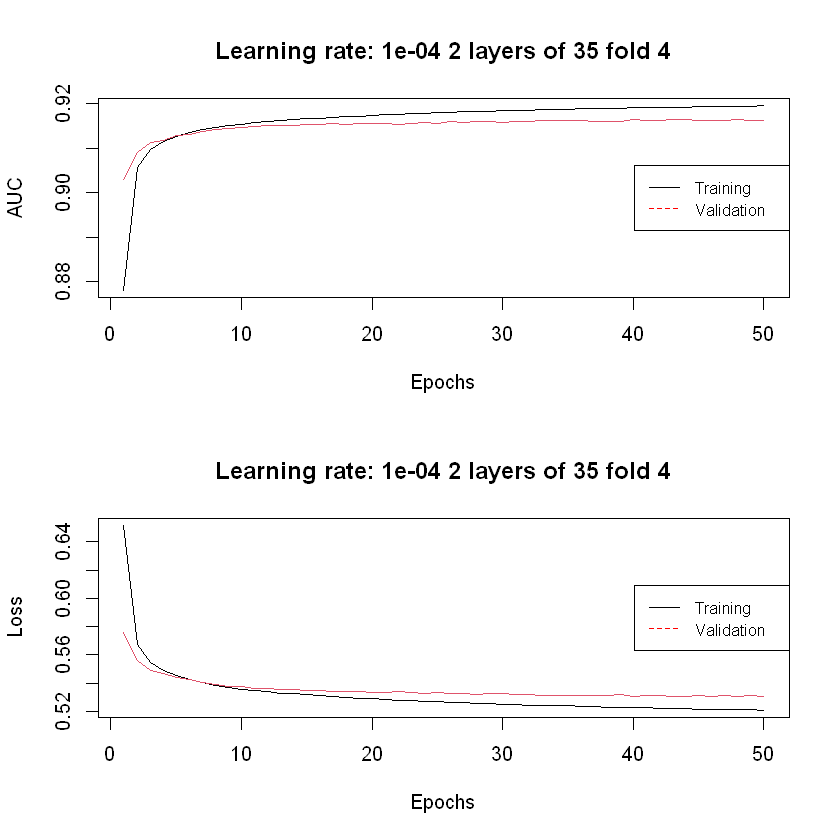

[1] "F1-Score Micro - 5 fold - Learning rate 1e-04 :  0.752951161175835"


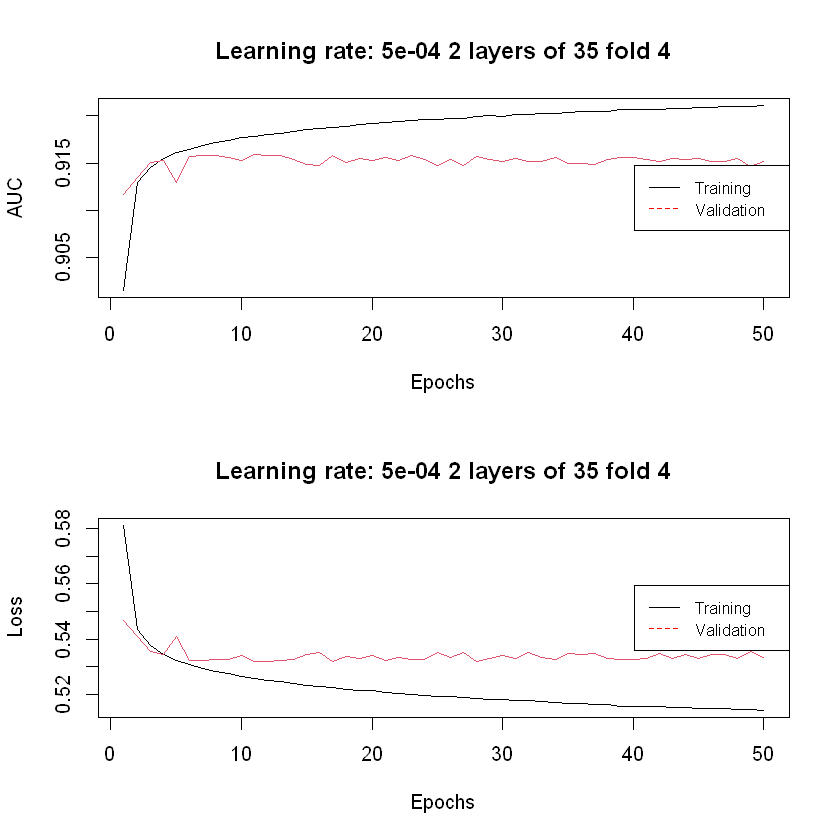

[1] "F1-Score Micro - 5 fold - Learning rate 5e-04 :  0.757464701797701"
  |==========================================                            |  60%

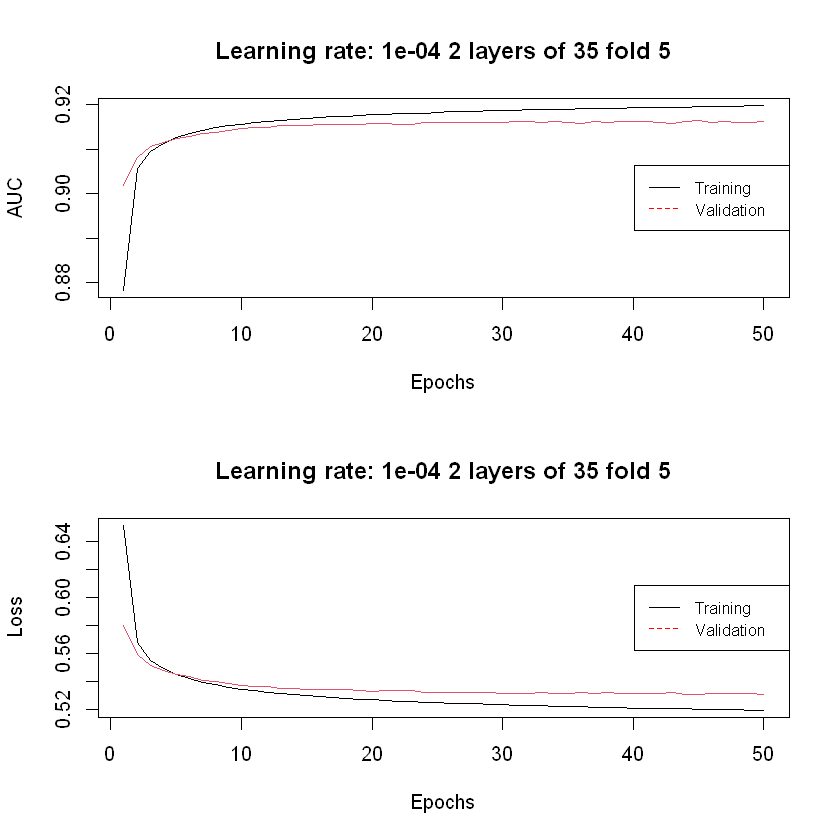

[1] "F1-Score Micro - 6 fold - Learning rate 1e-04 :  0.751330915824396"


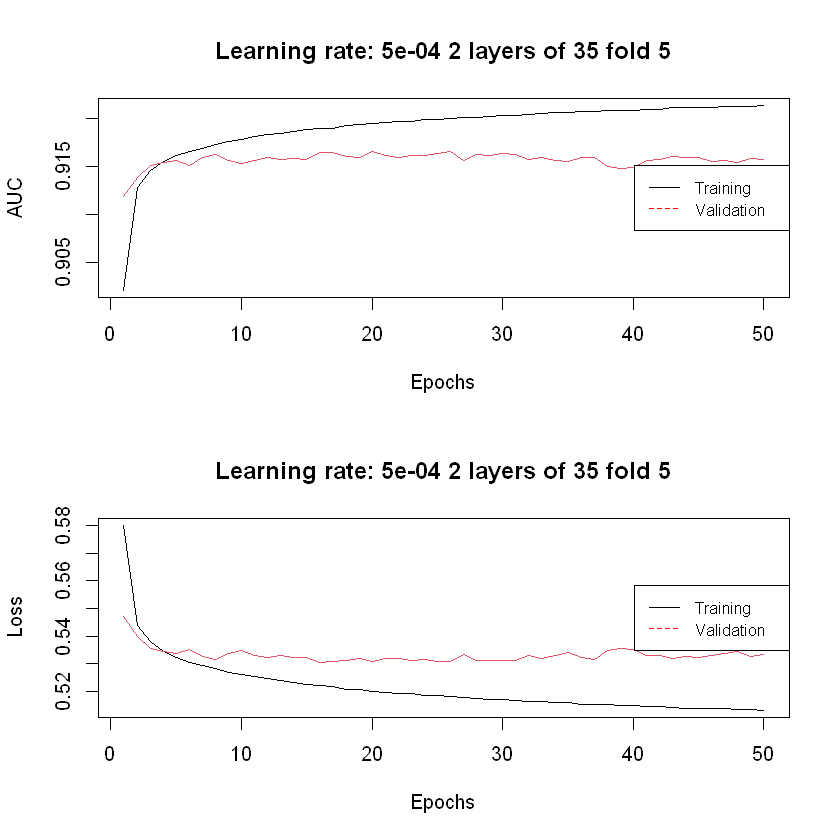

[1] "F1-Score Micro - 6 fold - Learning rate 5e-04 :  0.749903556824319"
  |=================================================                     |  70%

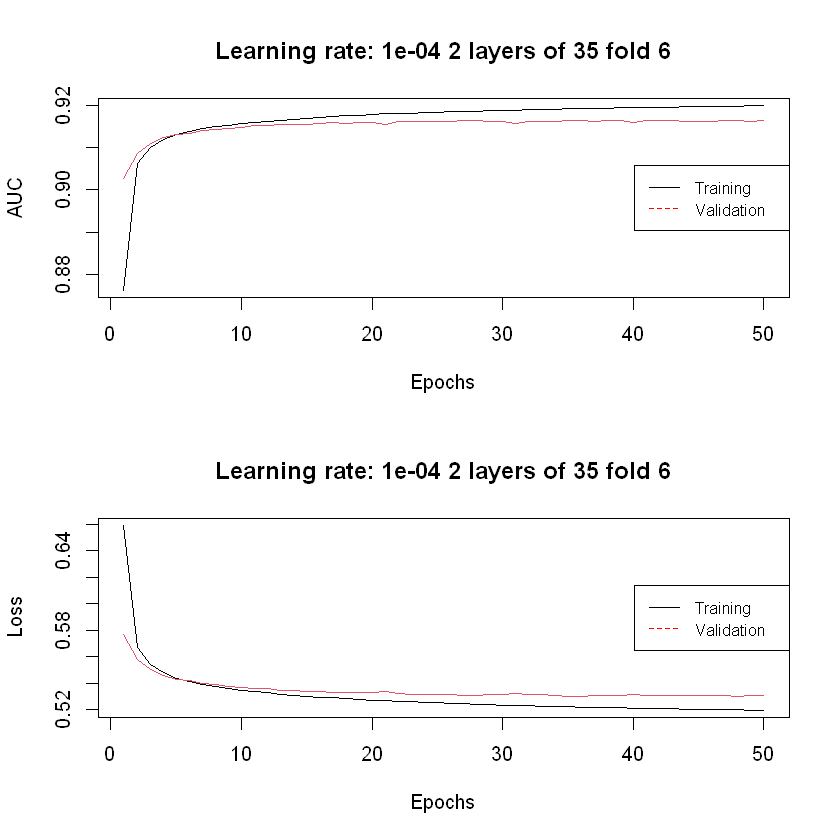

[1] "F1-Score Micro - 7 fold - Learning rate 1e-04 :  0.753221202067742"


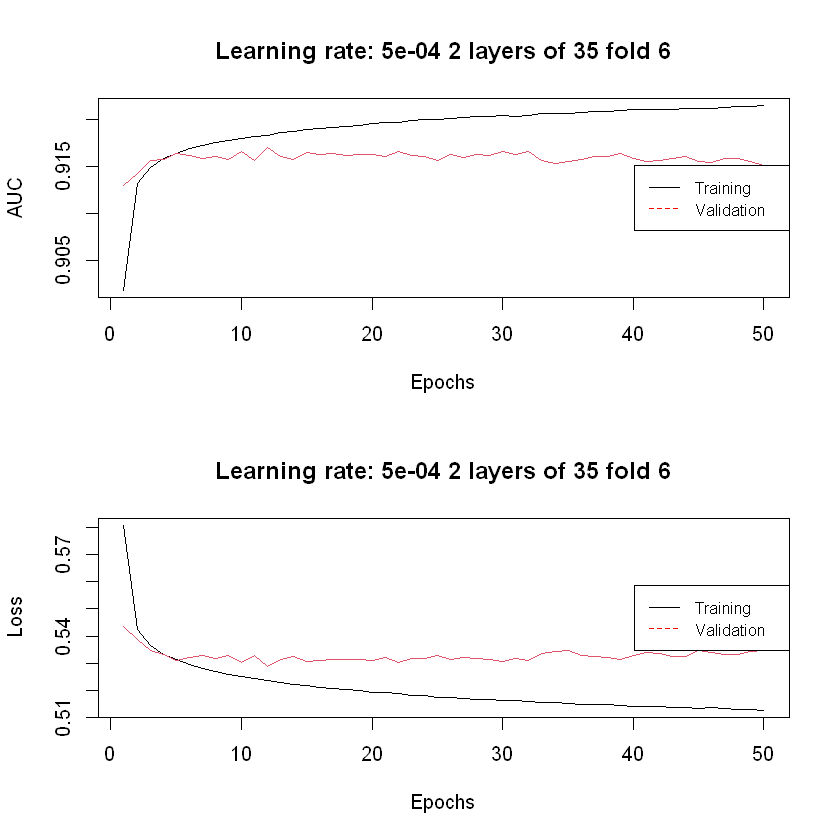

[1] "F1-Score Micro - 7 fold - Learning rate 5e-04 :  0.754802870148908"
  |========================================================              |  80%

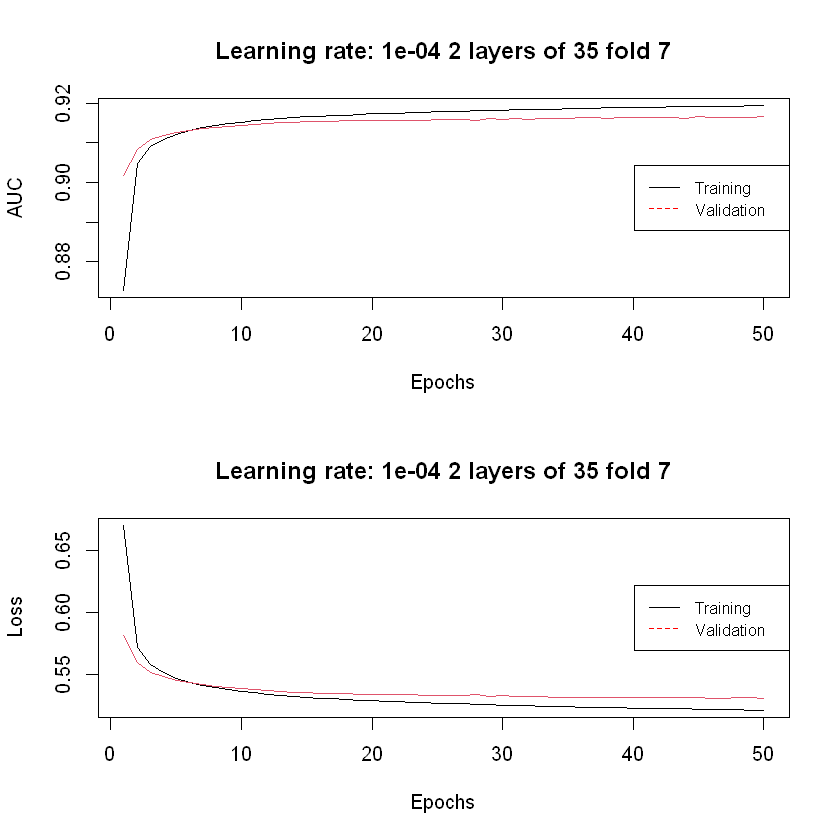

[1] "F1-Score Micro - 8 fold - Learning rate 1e-04 :  0.757233238176067"


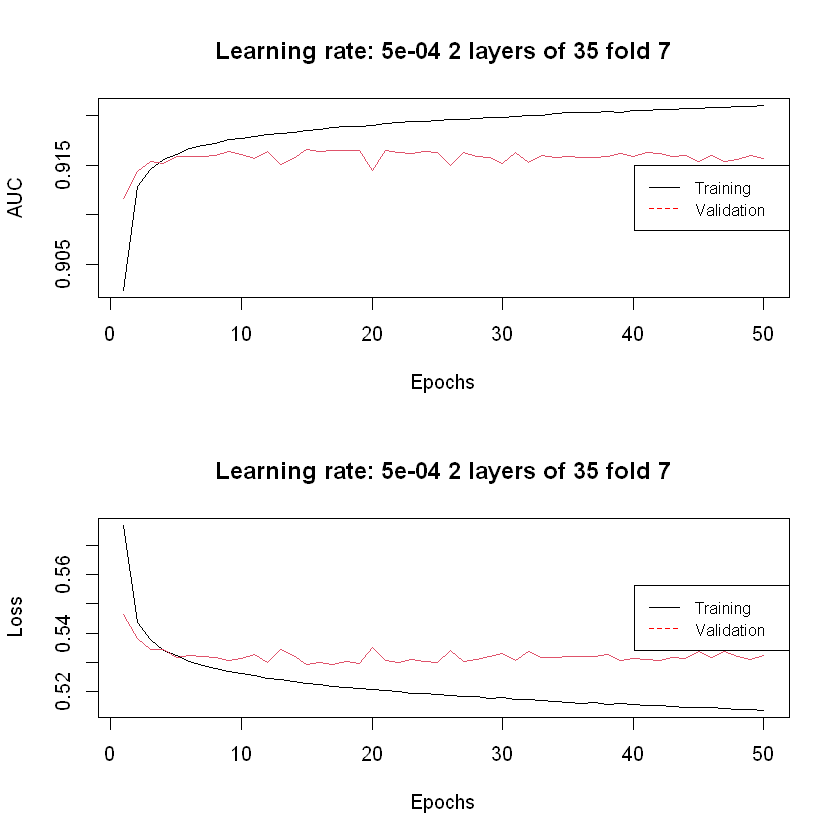

[1] "F1-Score Micro - 8 fold - Learning rate 5e-04 :  0.75630738368953"
  |===============================================================       |  90%

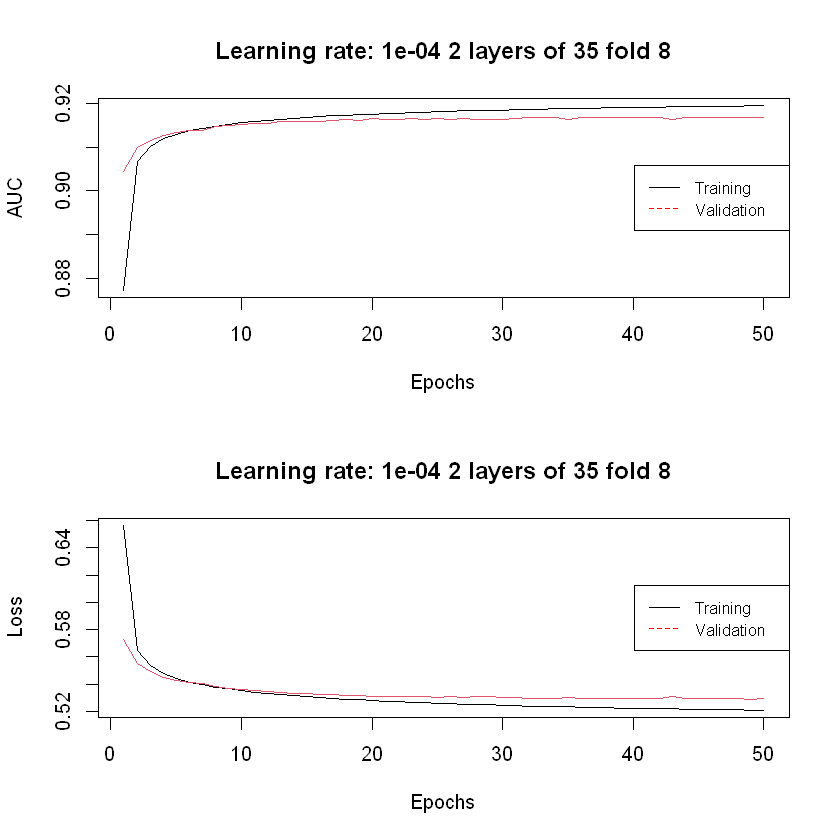

[1] "F1-Score Micro - 9 fold - Learning rate 1e-04 :  0.756538847311164"


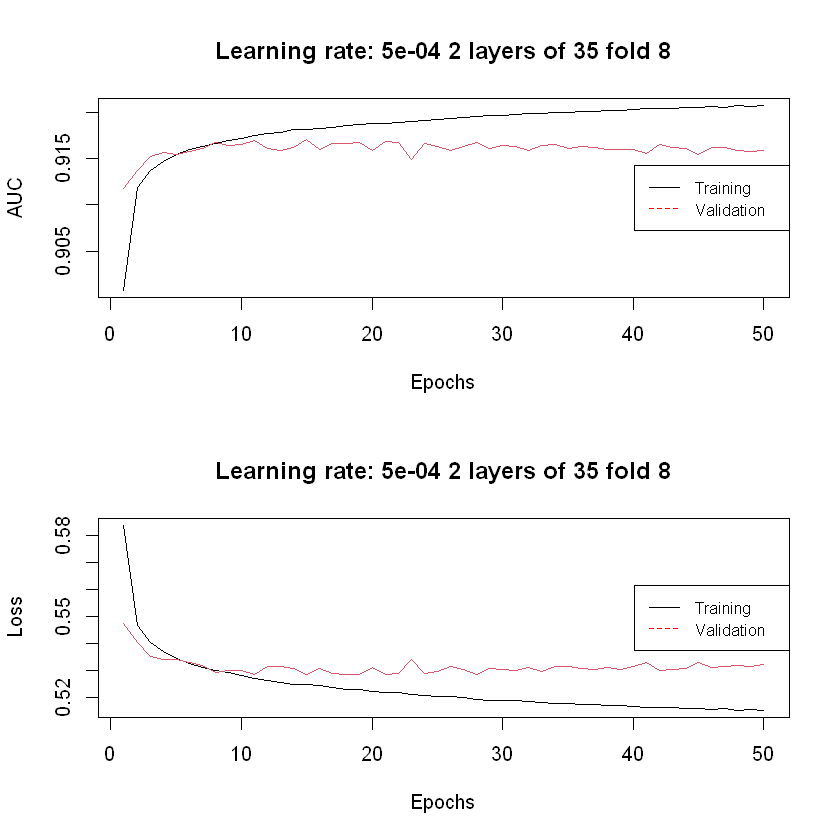

[1] "F1-Score Micro - 9 fold - Learning rate 5e-04 :  0.754802870148908"
  |======================================================================| 100%

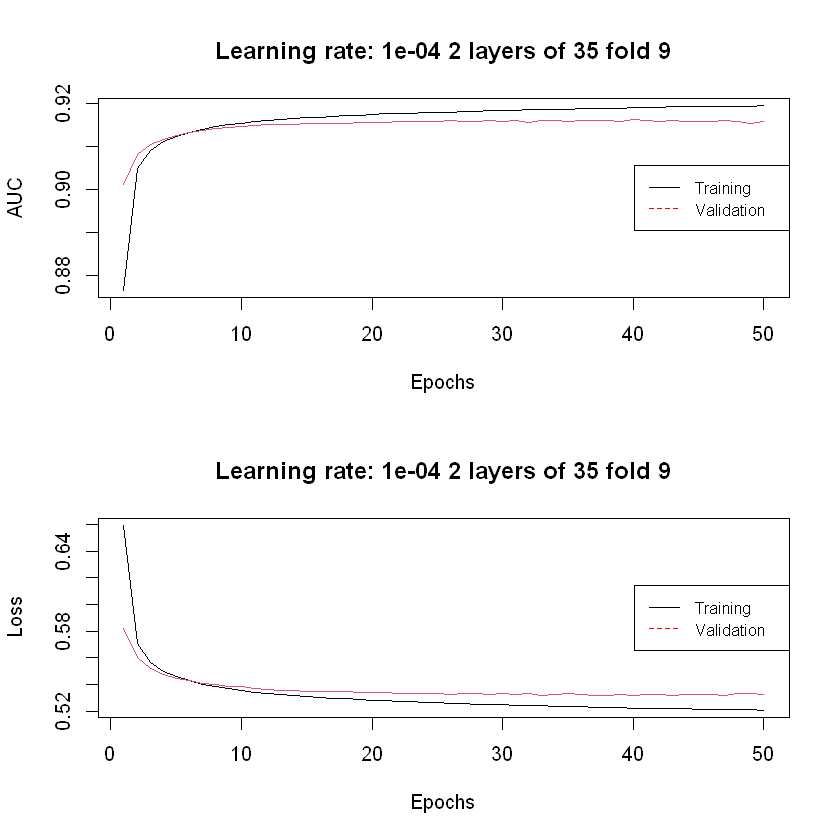

[1] "F1-Score Micro - 10 fold - Learning rate 1e-04 :  0.755373750627098"


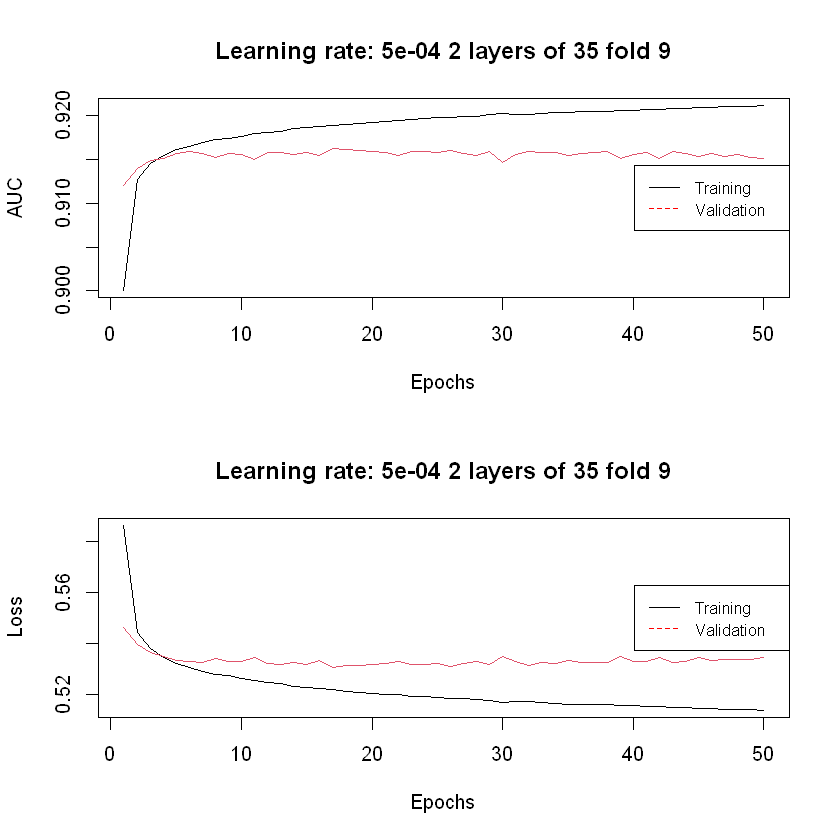

[1] "F1-Score Micro - 10 fold - Learning rate 5e-04 :  0.755180797283217"


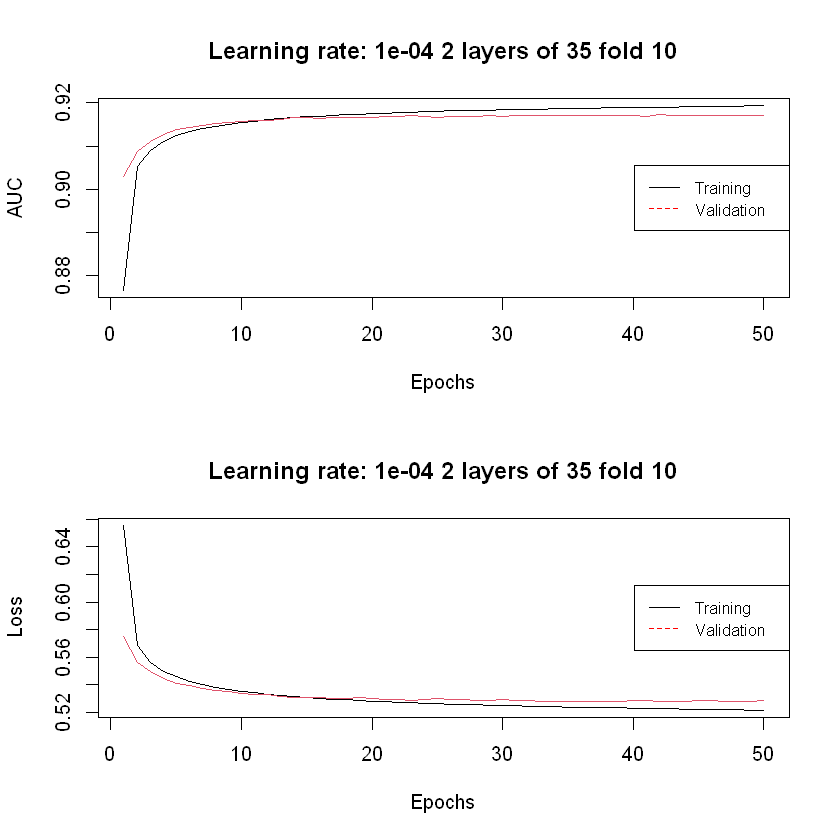

,fold,learning_rate,F1
,<dbl>,<dbl>,<dbl>
1,1,1e-04,0.7571947
2,1,5e-04,0.7530669
3,2,1e-04,0.7605895
4,2,5e-04,0.7568475
5,3,1e-04,0.7543785
6,3,5e-04,0.7538770
7,4,1e-04,0.7565388
8,4,5e-04,0.7535684
9,5,1e-04,0.7529512


,learning_rate,mean F1
,<dbl>,<dbl>
1,1e-04,0.7555351
2,5e-04,0.7545822


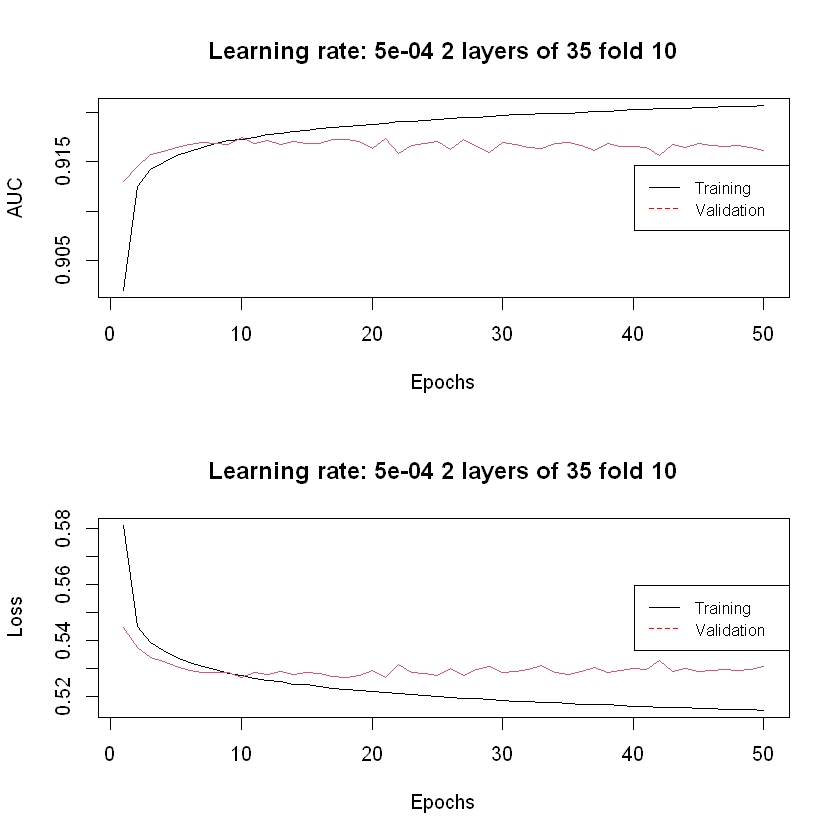

In [14]:
set.seed(2)
k = 10

accuracy_vec3 <- data.frame(matrix(ncol = 3, nrow = 0))
colnames(accuracy_vec3)<-c('fold','learning_rate','F1')

# 1. Shuffle the dataset randomly.
dataNN_idx <- sample(1:nrows)

# 2. Split the dataset into k groups
max <- ceiling(nrows/k)
splits <- split(dataNN_idx, ceiling(seq_along(dataNN_idx)/max))

pb <- txtProgressBar(min = 0, max = k, style = 3)
# 3. For each unique group:
for (i in 1:k){
    for (j in c(0.0001,0.0005)){
        
        neuralmodel <- keras_model_sequential() %>% 
        normalizer  %>% 
        layer_dense(37, activation = 'relu') %>%
        layer_dense(37, activation = 'relu') %>%
        layer_dense(3,activation='softmax')

        neuralmodel %>% compile(
            loss = 'categorical_crossentropy',
            optimizer = optimizer_adam(j),
            metrics=c('AUC')
        )
        #3.1 Take the group as a hold out or test data set
        test_data <- dataNN[splits[[i]],]

        #3.2 Take the remaining groups as a training data set
        train_data <- dataNN[-splits[[i]],]   

        model_history <- neuralmodel %>% fit(
        as.matrix(train_data[,-target_variables]),
        as.matrix(train_data[,target_variables]),
        validation_split = 0.2,
        verbose = 0,
        epochs = 50
        )

        yhat <- predict(neuralmodel, as.matrix(test_data[-target_variables]))

        yhaty <- classConverter(yhat,test_data)
        accuracy_vec3[nrow(accuracy_vec3)+1,]<-c(i,j,F1_Score_micro(yhaty[[2]][,],yhaty[[1]][,]))
        setTxtProgressBar(pb, i)
        print(paste("F1-Score Micro -",i,"fold -",'Learning rate',j,': ',accuracy_vec3[nrow(accuracy_vec3),3]))
        par(mfrow=c(2,1)) 
        plot(1:model_history$params$epochs,model_history$metrics$auc, type='l',xlab="Epochs",ylab='AUC',main=paste('Learning rate:',j, '2 layers of 35','fold',i),col=1)
        lines(1:model_history$params$epochs,model_history$metrics$val_auc, type='l',ylab='AUC',col=2)
        legend(x='right', legend=c("Training", "Validation"),col=c("black", "red"), lty=1:2, cex=0.8)
        plot(1:model_history$params$epochs,model_history$metrics$loss, type='l',xlab="Epochs",ylab='Loss',main=paste('Learning rate:',j, '2 layers of 35','fold',i),col=1)
        lines(1:model_history$params$epochs,model_history$metrics$val_loss, type='l',ylab='Loss',col=2)
        legend(x='right', legend=c("Training", "Validation"),col=c("black", "red"), lty=1:2, cex=0.8)
        rm('neuralmodel','model_history')
    }
}
meanF1_3 <- data.frame(matrix(ncol = 2, nrow = 0))
colnames(meanF1_3)<-c('learning_rate','mean F1')
for (i in c(0.0001,0.0005)){
    meanF1_3[nrow(meanF1_3)+1,]<-c(i,mean(filter(accuracy_vec3,(learning_rate==i))$F1))
}
accuracy_vec3
meanF1_3
#219 min

In [15]:
meanF1_3
meanF1_2
meanF1

,learning_rate,mean F1
,<dbl>,<dbl>
1,1e-04,0.7555351
2,5e-04,0.7545822


,learning_rate,mean F1
,<dbl>,<dbl>
1,1e-04,0.7555351
2,5e-04,0.7555119
3,1e-03,0.7539495
4,5e-03,0.7514882


,learning_rate,mean F1
,<dbl>,<dbl>
1,1e-04,0.7560520
2,5e-04,0.7546902
3,1e-03,0.7549178
4,5e-03,0.7513531
